In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
performance_features = [
    "return_measurement_comparison_percent",
    "return_lag_1q",
    "return_lag_2q",
    "return_lag_3q",
    "return_lag_4q",
    "return_change_1q",
    "return_trailing_4q",
    "return_mean_4q",
    "return_std_4q",
    "return_min_4q",
    "positive_quarter_share_4q",
    "current_return_minus_peer_median",
    "current_return_peer_percentile",
]

volatility_features = [
    "return_investment_five_year_volatility_comparison_percent",
    "return_investment_ten_year_volatility_comparison_percent_clean",
    "volatility_5y_minus_10y",
    "volatility_5y_missing",
    "volatility_10y_missing",
]

saa_features = [
    "strategic_growth_allocation",
    "allocation_equity",
    "allocation_property",
    "allocation_infrastructure",
    "allocation_cash",
    "allocation_alternatives",
    "allocation_credit",
    "allocation_fixed_income_excluding_credit",
    "saa_missing",
]

hedging_features = [
    "weighted_currency_hedging_ratio",
    "currency_hedging_applicable_allocation",
    "currency_hedging_distinct_ratios",
]

strategy_change_features = [
    "strategic_growth_change_1q",
    "equity_allocation_change_1q",
    "cash_allocation_change_1q",
]

baseline_features = (
    performance_features
    + volatility_features
    + saa_features
    + hedging_features
    + strategy_change_features
)

In [3]:
# imprt the data
DATA_PATH = Path(
    "../data/processed/hist_model_mysuper_features.parquet"
)

hist_model_mysuper_features = pd.read_parquet(
    DATA_PATH
)

hist_model_mysuper_features.shape

(13719, 136)

In [4]:
# ensure that the dat is in datetime format
hist_model_mysuper_features[
    "period_end_date"
] = pd.to_datetime(
    hist_model_mysuper_features[
        "period_end_date"
    ]
)

hist_model_mysuper_features[
    "target_end_date"
] = pd.to_datetime(
    hist_model_mysuper_features[
        "target_end_date"
    ]
)

In [5]:
# check coluns
missing_features = [
    col
    for col in baseline_features
    if col not in hist_model_mysuper_features.columns
]

missing_features

[]

### Create the modelling population

In [6]:
target_col = "future_4q_bottom_quartile"

model_data = (
    hist_model_mysuper_features[
        hist_model_mysuper_features[
            "future_4q_target_available_option"
        ].eq(True)
        &
        hist_model_mysuper_features[
            target_col
        ].notna()
    ]
    .copy()
)

# convert target from boolean to 1/0 system
model_data[target_col] = (
    model_data[target_col]
    .astype("int8")
)

# sort the table
entity_keys = [
    "rse_abn",
    "abn_product_identifier",
    "abn_investment_menu_identifier",
    "abn_investment_option_identifier",
]

model_data = (
    model_data
    .sort_values(
        ["period_end_date"]
        + entity_keys
    )
    .reset_index(drop=True)
)

In [7]:
model_data.shape

(11720, 136)

In [8]:
model_data[target_col].value_counts(
    normalize=True
)

future_4q_bottom_quartile
0    0.741553
1    0.258447
Name: proportion, dtype: float64

### Inspect the temporal distribution

In [9]:
# define peer fields
peer_keys = [
    "rse_abn",
    "abn_investment_option_identifier",
    "period_end_date",
]

option_target_nunique = (
    model_data
    .groupby(peer_keys)[target_col]
    .nunique()
)

option_target_nunique.value_counts()

future_4q_bottom_quartile
1    9896
Name: count, dtype: int64

In [10]:
option_target_nunique.max()

np.int64(1)

In [11]:
option_quarter_target = (
    model_data
    .groupby(
        peer_keys,
        as_index=False
    )
    .agg(
        future_4q_bottom_quartile=(
            target_col,
            "first",
        )
    )
)

# quarterly summary
row_summary = (
    model_data
    .groupby("period_end_date")
    .agg(
        modelling_rows=(
            target_col,
            "size",
        ),
        row_positive_rate=(
            target_col,
            "mean",
        ),
        target_end_min=(
            "target_end_date",
            "min",
        ),
        target_end_max=(
            "target_end_date",
            "max",
        ),
    )
)

option_summary = (
    option_quarter_target
    .groupby("period_end_date")
    .agg(
        unique_options=(
            "abn_investment_option_identifier",
            "size",
        ),
        option_positive_rate=(
            target_col,
            "mean",
        ),
    )
)

quarter_summary = (
    row_summary
    .join(option_summary)
)

quarter_summary

,modelling_rows,row_positive_rate,target_end_min,target_end_max,unique_options,option_positive_rate
period_end_date,,,,,,
2014-12-31,185,0.254054,2015-12-31,2015-12-31,153,0.254902
2015-03-31,185,0.318919,2016-03-31,2016-03-31,153,0.254902
2015-06-30,185,0.329730,2016-06-30,2016-06-30,153,0.254902
2015-09-30,185,0.308108,2016-09-30,2016-09-30,153,0.254902
2015-12-31,185,0.302703,2016-12-31,2016-12-31,153,0.254902
2016-03-31,185,0.259459,2017-03-31,2017-03-31,153,0.254902
2016-06-30,186,0.258065,2017-06-30,2017-06-30,154,0.253247
2016-09-30,187,0.262032,2017-09-30,2017-09-30,155,0.258065
2016-12-31,200,0.260000,2017-12-31,2017-12-31,168,0.250000


The temporal inspection looks good enough to proceed, and it supports the split strategy we chose. A few things are especially important.

First, the target timing is internally consistent. For every quarter, target_end_min == target_end_max, and it is exactly four quarters after period_end_date. For example, 2023-03-31 → 2024-03-31 and 2024-06-30 → 2025-06-30.

Because of that, safely continue to the next part.

### Prepare the final test period

For the first baseline, the last 4 available quarters will be considered as the final untouched test set.

In [12]:
# define the available quarters
available_quarters = (
    model_data[
        "period_end_date"
    ]
    .drop_duplicates()
    .sort_values()
    .to_list()
)

len(available_quarters)

42

In [13]:
TEST_QUARTERS = 4

test_quarters = (
    available_quarters[
        -TEST_QUARTERS:
    ]
)

test_start = test_quarters[0]
test_end = test_quarters[-1]

test_start, test_end

(Timestamp('2024-06-30 00:00:00'), Timestamp('2025-03-31 00:00:00'))

### Define data used for development

In [14]:
# define data used for development based on final test start date cutoff
development_mask = (
    model_data[
        "target_end_date"
    ]
    <
    test_start
)

development_data = (
    model_data[
        development_mask
    ]
    .copy()
)

# define the final test data
final_test_data = (
    model_data[
        model_data[
            "period_end_date"
        ].isin(test_quarters)
    ]
    .copy()
)

In [15]:
development_data.shape, final_test_data.shape

((9003, 136), (1369, 136))

### Identify the label-maturation gap

identify rows whose quarters are between the last development prediction quarter and the first test quarter, which simply haven't matured by the simulated test date.

In [16]:
maturation_gap = (
    model_data[
        (model_data["period_end_date"] < test_start)
        &
        (model_data["target_end_date"] >= test_start)
    ]
    .copy()
)

# inspect result
maturation_gap[
    [
        "period_end_date",
        "target_end_date",
    ]
].drop_duplicates().sort_values(
    "period_end_date"
)

,period_end_date,target_end_date
9003,2023-06-30,2024-06-30
9348,2023-09-30,2024-09-30
9682,2023-12-31,2024-12-31
10017,2024-03-31,2025-03-31


### Build the expanding validation folds

In [17]:
# define number of folds and number of quarters inside each validation
N_VALIDATION_FOLDS = 4
VALIDATION_QUARTERS = 4

development_quarters = (
    development_data[
        "period_end_date"
    ]
    .drop_duplicates()
    .sort_values()
    .to_list()
)

len(development_quarters)

34

In [18]:
required_validation_quarters = (
    N_VALIDATION_FOLDS
    * VALIDATION_QUARTERS
)

# Check that there is enough history
assert (
    len(development_quarters)
    >
    required_validation_quarters
)

In [19]:
# Take the latest 16 development quarters as the validation windows
validation_quarters_all = (
    development_quarters[-required_validation_quarters:]
)

# Create 4 blocks
validation_blocks = []

for i in range(N_VALIDATION_FOLDS):
    start = (i * VALIDATION_QUARTERS)
    end = (start + VALIDATION_QUARTERS)

    validation_blocks.append(
        validation_quarters_all[start:end]
    )

In [20]:
# inspect result
for i, block in enumerate(
    validation_blocks,
    start=1,
):
    print(
        f"Fold {i}:",
        block[0],
        "to",
        block[-1],
    )

Fold 1: 2019-06-30 00:00:00 to 2020-03-31 00:00:00
Fold 2: 2020-06-30 00:00:00 to 2021-03-31 00:00:00
Fold 3: 2021-06-30 00:00:00 to 2022-03-31 00:00:00
Fold 4: 2022-06-30 00:00:00 to 2023-03-31 00:00:00


### apply fold-specific purging

In [21]:
folds = []

for fold_number, val_quarters in enumerate(
    validation_blocks,
    start=1,
):

    validation_start = (val_quarters[0])

    validation_end = (val_quarters[-1])

    train_mask = (
        (development_data["period_end_date"] < validation_start)
        &
        (development_data["target_end_date"] < validation_start)
    )

    validation_mask = (
        development_data["period_end_date"].isin(
            val_quarters
        )
    )

    train_data = (
        development_data[train_mask].copy()
    )

    validation_data = (
        development_data[validation_mask].copy()
    )

    folds.append(
        {
            "fold": fold_number,
            "validation_start": validation_start,
            "validation_end": validation_end,
            "train_index": train_data.index,
            "validation_index": validation_data.index,
        }
    )

In [22]:
# audit result
fold_summary = []

for fold in folds:

    train_data = (
        development_data.loc[
            fold["train_index"]
        ]
    )

    validation_data = (
        development_data.loc[
            fold["validation_index"]
        ]
    )

    fold_summary.append(
        {
            "fold":
                fold["fold"],

            "train_start":
                train_data[
                    "period_end_date"
                ].min(),

            "train_end":
                train_data[
                    "period_end_date"
                ].max(),

            "train_target_end_max":
                train_data[
                    "target_end_date"
                ].max(),

            "train_rows":
                len(train_data),

            "train_positive_rate":
                train_data[
                    target_col
                ].mean(),

            "validation_start":
                validation_data[
                    "period_end_date"
                ].min(),

            "validation_end":
                validation_data[
                    "period_end_date"
                ].max(),

            "validation_rows":
                len(validation_data),

            "validation_positive_rate":
                validation_data[
                    target_col
                ].mean(),
        }
    )

fold_summary = pd.DataFrame(
    fold_summary
)

fold_summary

,fold,train_start,train_end,train_target_end_max,train_rows,train_positive_rate,validation_start,validation_end,validation_rows,validation_positive_rate
0,1,2014-12-31,2018-03-31,2019-03-31,2722,0.272594,2019-06-30,2020-03-31,1259,0.249404
1,2,2014-12-31,2019-03-31,2020-03-31,3783,0.265662,2020-06-30,2021-03-31,1387,0.268205
2,3,2014-12-31,2020-03-31,2021-03-31,5042,0.261603,2021-06-30,2022-03-31,1254,0.270335
3,4,2014-12-31,2021-03-31,2022-03-31,6429,0.263027,2022-06-30,2023-03-31,1320,0.250000


In [23]:
(
    fold_summary[
        "train_target_end_max"
    ]
    <
    fold_summary[
        "validation_start"
    ]
).all()

np.True_

In [24]:
# inspect dataypes and missingness
feature_audit = pd.DataFrame(
    {
        "dtype": model_data[
            baseline_features
        ].dtypes.astype(str),

        "missing_count": model_data[
            baseline_features
        ].isna().sum(),

        "missing_rate": model_data[
            baseline_features
        ].isna().mean(),
    }
).sort_values(
    "missing_rate",
    ascending=False,
)

feature_audit

,dtype,missing_count,missing_rate
volatility_5y_minus_10y,float64,8725,0.744454
return_investment_ten_year_volatility_comparison_percent_clean,float64,8719,0.743942
return_investment_five_year_volatility_comparison_percent,float64,6016,0.513311
strategic_growth_change_1q,float64,3577,0.305205
cash_allocation_change_1q,float64,3577,0.305205
equity_allocation_change_1q,float64,3577,0.305205
currency_hedging_applicable_allocation,float64,3217,0.274488
allocation_fixed_income_excluding_credit,float64,3217,0.274488
currency_hedging_distinct_ratios,Int64,3217,0.274488
allocation_infrastructure,float64,3217,0.274488


In [25]:
non_numeric_features = [
    col
    for col in baseline_features
    if not pd.api.types.is_numeric_dtype(
        model_data[col]
    )
    and not pd.api.types.is_bool_dtype(
        model_data[col]
    )
]

non_numeric_features

[]

In [26]:
numeric_features = (
    model_data[
        baseline_features
    ]
    .select_dtypes(
        include=["number"]
    )
    .columns
)

infinite_counts = (
    np.isinf(
        model_data[
            numeric_features
        ]
    )
    .sum()
)

infinite_counts[
    infinite_counts > 0
]

Series([], dtype: Int64)

### Setting up Pipeline

In [27]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

In [28]:
# create dummy model to predict from the training-set class prevalence without learning useful relationships.
dummy_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="prior"
            ),
        ),
    ]
)

# create logistics regression model
logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

In [29]:
# create a metric helper function
def calculate_classification_metrics(
    y_true,
    y_pred,
    y_prob,
):
    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "f1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob,
            ),

        "average_precision":
            average_precision_score(
                y_true,
                y_prob,
            ),

        "brier_score":
            brier_score_loss(
                y_true,
                y_prob,
            ),
    }

In [30]:
# put 2 models into a dictionary
baseline_models = {
    "dummy_prior":
        dummy_pipeline,

    "logistic_regression":
        logistic_pipeline,
}

### Baseline model training

In [31]:
fold_results = []

for fold in folds:

    train_data = (
        development_data.loc[
            fold["train_index"]
        ]
    )

    validation_data = (
        development_data.loc[
            fold["validation_index"]
        ]
    )

    X_train = train_data[
        baseline_features
    ]

    y_train = train_data[
        target_col
    ]

    X_validation = validation_data[
        baseline_features
    ]

    y_validation = validation_data[
        target_col
    ]

    for model_name, model_pipeline in (
        baseline_models.items()
    ):

        model = clone(
            model_pipeline
        )

        model.fit(
            X_train,
            y_train,
        )

        validation_probability = (
            model.predict_proba(
                X_validation
            )[:, 1]
        )

        validation_prediction = (
            model.predict(
                X_validation
            )
        )

        metrics = (
            calculate_classification_metrics(
                y_true=y_validation,
                y_pred=validation_prediction,
                y_prob=validation_probability,
            )
        )

        fold_results.append(
            {
                "fold":
                    fold["fold"],

                "model":
                    model_name,

                "train_start":
                    train_data[
                        "period_end_date"
                    ].min(),

                "train_end":
                    train_data[
                        "period_end_date"
                    ].max(),

                "validation_start":
                    validation_data[
                        "period_end_date"
                    ].min(),

                "validation_end":
                    validation_data[
                        "period_end_date"
                    ].max(),

                "train_rows":
                    len(train_data),

                "validation_rows":
                    len(validation_data),

                "validation_positive_rate":
                    y_validation.mean(),

                **metrics,
            }
        )

In [32]:
fold_results = pd.DataFrame(
    fold_results
)

fold_results

,fold,model,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,validation_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,dummy_prior,2014-12-31,2018-03-31,2019-06-30,2020-03-31,2722,1259,0.249404,0.750596,0.500000,0.000000,0.000000,0.000000,0.500000,0.249404,0.187740
1,1,logistic_regression,2014-12-31,2018-03-31,2019-06-30,2020-03-31,2722,1259,0.249404,0.702145,0.572987,0.382239,0.315287,0.345550,0.493813,0.310312,0.254806
2,2,dummy_prior,2014-12-31,2019-03-31,2020-06-30,2021-03-31,3783,1387,0.268205,0.731795,0.500000,0.000000,0.000000,0.000000,0.500000,0.268205,0.196277
3,2,logistic_regression,2014-12-31,2019-03-31,2020-06-30,2021-03-31,3783,1387,0.268205,0.671233,0.518224,0.312500,0.188172,0.234899,0.646782,0.323816,0.249468
4,3,dummy_prior,2014-12-31,2020-03-31,2021-06-30,2022-03-31,5042,1254,0.270335,0.729665,0.500000,0.000000,0.000000,0.000000,0.500000,0.270335,0.197330
5,3,logistic_regression,2014-12-31,2020-03-31,2021-06-30,2022-03-31,5042,1254,0.270335,0.670654,0.480918,0.191667,0.067847,0.100218,0.493567,0.260131,0.251112
6,4,dummy_prior,2014-12-31,2021-03-31,2022-06-30,2023-03-31,6429,1320,0.250000,0.750000,0.500000,0.000000,0.000000,0.000000,0.500000,0.250000,0.187670
7,4,logistic_regression,2014-12-31,2021-03-31,2022-06-30,2023-03-31,6429,1320,0.250000,0.824242,0.683838,0.791667,0.403030,0.534137,0.737438,0.635967,0.145512


### Compare the models

In [33]:
metric_columns = [
    "roc_auc",
    "average_precision",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "brier_score",
]

model_summary = (
    fold_results
    .groupby("model")[
        metric_columns
    ]
    .agg(
        ["mean", "std"]
    )
)

model_summary

roc_auc           average_precision            \
                       mean       std              mean       std   
model                                                               
dummy_prior          0.5000  0.000000          0.259486  0.011333   
logistic_regression  0.5929  0.120388          0.382556  0.171148   

                    balanced_accuracy           precision             recall  \
                                 mean       std      mean      std      mean   
model                                                                          
dummy_prior                  0.500000  0.000000  0.000000  0.00000  0.000000   
logistic_regression          0.563992  0.088393  0.419518  0.26029  0.243584   

                                    f1            accuracy            \
                         std      mean       std      mean       std   
model                                                                  
dummy_prior          0.00000  0.000000  0.000000  0.740514  0.011333   
logistic_regression  0.14665  0.303701  0.183477  0.717068  0.072948   

                    brier_score            
                           mean       std  
model                                      
dummy_prior            0.192254  0.005271  
logistic_regression    0.225225  0.053188

In [34]:
fold_results[
    [
        "fold",
        "model",
        "validation_start",
        "validation_end",
        "roc_auc",
        "average_precision",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
    ]
]

,fold,model,validation_start,validation_end,roc_auc,average_precision,balanced_accuracy,precision,recall,f1
0,1,dummy_prior,2019-06-30,2020-03-31,0.500000,0.249404,0.500000,0.000000,0.000000,0.000000
1,1,logistic_regression,2019-06-30,2020-03-31,0.493813,0.310312,0.572987,0.382239,0.315287,0.345550
2,2,dummy_prior,2020-06-30,2021-03-31,0.500000,0.268205,0.500000,0.000000,0.000000,0.000000
3,2,logistic_regression,2020-06-30,2021-03-31,0.646782,0.323816,0.518224,0.312500,0.188172,0.234899
4,3,dummy_prior,2021-06-30,2022-03-31,0.500000,0.270335,0.500000,0.000000,0.000000,0.000000
5,3,logistic_regression,2021-06-30,2022-03-31,0.493567,0.260131,0.480918,0.191667,0.067847,0.100218
6,4,dummy_prior,2022-06-30,2023-03-31,0.500000,0.250000,0.500000,0.000000,0.000000,0.000000
7,4,logistic_regression,2022-06-30,2023-03-31,0.737438,0.635967,0.683838,0.791667,0.403030,0.534137


From the result, logistic regression model shows a little bit better result than dummy model, but in terms of accuracy, dummy model is better than logistic regression model. But this might be misleading because 75% of the data is negative (False) and its accuracy is around 74%, which means that it might predicts that all of them are negative.

When looking at each fold, it shows that logistic regression is unstable across all of the evaluation metrics.

##### Fold 1

the ROC-AUC = 0.49, which means that it is essentially random ranking (below 50%) but the balanced accuracy = 0.57, which means that it is above the default threshold. That's possible, because ROC-AUC evaluates ranking across all possible thresholds, whereas balanced accuracy only evaluates the particular classifications produced at the default threshold. But the probability distribution should still need to be investigated because the disagreement between 2 metrics are significant.

##### Fold 2
The ROC-AUC is improving to 0.647 but the recall is bad (recall = 0.188). This might mean that the default threshold catches fewer than 1 in 5 positives? need to check on threshold?

##### Fold 3
ROC-AUC, balanced accuracy and recall are all very low. This means that at this fold, the model essentially fails. This fold covers :
- 2021-06-30
- 2021-09-30
- 2021-12-31
- 2022-03-31

This might be because of some unusual pattern/distribution in certain period that are causing problems?

##### Fold 4
This fold is significantly better than previous folds. The model might identify a relatively small subset of observations as risky, but when it does flag one, it is often correct. But the result is significantly different than previous folds. Why?

The initial logistic-regression baseline demonstrated modest overall discrimination across purged expanding-window validation (mean ROC-AUC ≈ 0.59), but performance varied substantially across time (≈0.49–0.74). The strongest performance occurred in the most recent validation block, while two earlier blocks were close to random ranking. This indicates that predictive relationships may be regime-dependent and motivates further investigation of feature availability, feature-family contribution, temporal stability, and nonlinear modelling before evaluating the untouched final test set.

Try checking out of loop prediction to know the overall validation prediction result.

In [35]:
oof_predictions = []

for fold in folds:

    train_data = (
        development_data.loc[
            fold["train_index"]
        ]
    )

    validation_data = (
        development_data.loc[
            fold["validation_index"]
        ]
    )

    X_train = train_data[
        baseline_features
    ]

    y_train = train_data[
        target_col
    ]

    X_validation = validation_data[
        baseline_features
    ]

    y_validation = validation_data[
        target_col
    ]

    for model_name, model_pipeline in (
        baseline_models.items()
    ):

        model = clone(
            model_pipeline
        )

        model.fit(
            X_train,
            y_train,
        )

        validation_probability = (
            model.predict_proba(
                X_validation
            )[:, 1]
        )

        validation_prediction = (
            model.predict(
                X_validation
            )
        )

        for (
            row_index,
            actual,
            probability,
            prediction,
        ) in zip(
            validation_data.index,
            y_validation,
            validation_probability,
            validation_prediction,
        ):

            oof_predictions.append(
                {
                    "row_index":
                        row_index,

                    "fold":
                        fold["fold"],

                    "model":
                        model_name,

                    "period_end_date":
                        validation_data.loc[
                            row_index,
                            "period_end_date",
                        ],

                    "actual":
                        actual,

                    "probability":
                        probability,

                    "prediction":
                        prediction,
                }
            )

oof_predictions = pd.DataFrame(
    oof_predictions
)

In [36]:
oof_predictions

,row_index,fold,model,period_end_date,actual,probability,prediction
0,3783,1,dummy_prior,2019-06-30,0,0.272594,0
1,3784,1,dummy_prior,2019-06-30,0,0.272594,0
2,3785,1,dummy_prior,2019-06-30,0,0.272594,0
3,3786,1,dummy_prior,2019-06-30,0,0.272594,0
4,3787,1,dummy_prior,2019-06-30,0,0.272594,0
...,...,...,...,...,...,...,...
10435,8998,4,logistic_regression,2023-03-31,0,0.249877,0
10436,8999,4,logistic_regression,2023-03-31,0,0.249877,0
10437,9000,4,logistic_regression,2023-03-31,0,0.249877,0
10438,9001,4,logistic_regression,2023-03-31,0,0.433690,0


In [37]:
# check OOF probabilities of logistic regression
# extract the OOF probabilities of logistic regression
logistic_oof = (
    oof_predictions[
        oof_predictions[
            "model"
        ].eq(
            "logistic_regression"
        )
    ]
    .copy()
)

(
    logistic_oof
    .groupby("fold")
    .agg(
        actual_positive_rate=(
            "actual",
            "mean",
        ),
        predicted_positive_rate=(
            "prediction",
            "mean",
        ),
        mean_probability=(
            "probability",
            "mean",
        ),
        probability_std=(
            "probability",
            "std",
        ),
        probability_min=(
            "probability",
            "min",
        ),
        probability_max=(
            "probability",
            "max",
        ),
    )
)

,actual_positive_rate,predicted_positive_rate,mean_probability,probability_std,probability_min,probability_max
fold,,,,,,
1,0.249404,0.205719,0.227615,0.331958,7.729433e-09,0.999871
2,0.268205,0.161500,0.188626,0.260704,2.170748e-05,0.939256
3,0.270335,0.095694,0.180591,0.197420,1.162865e-03,0.968220
4,0.250000,0.127273,0.274254,0.204252,4.128581e-03,0.935384


The main pattern is that the logistic regression is systematically under-flagging positives in Folds 2–4 at the 0.5 threshold, especially Fold 3.

in Fold 3, Actual positives are about 27%, but only 9.6% of rows are classified positive. This is why Fold 3's evaluation metrics are so bad. The model is assigning most observations probabilities below 0.5, so the default threshold is producing very few alerts. But predicted_positive_rate depends on the threshold whereas mean_probability does not. Since mean_probability = 18%, Fold 3 might have 2 separate problems:
The model is both:
- assigning probabilities that are too low overall, and
- producing relatively few scores above 0.5.

That suggests calibration / temporal shift, not just a bad classification threshold.

in Fold 4, the predicted positive rate is significantly lower than actual positive rate, the difference is larger than fold 1 and 2 even though the evaluation metrics are better. It means many observations are probably receiving probabilities somewhere in the middle while a smaller group receives very high probabilities. The average can therefore be around 0.274 even though only 12.7% exceed 0.50. This means that in Fold 4, the model acts conservative, it flags relatively few observations, but the ones it flags are often genuinely positive.

In summary, The logistic model is not merely suffering from a suboptimal 0.5 classification threshold. Its probability calibration and score distribution vary materially across time. Fold 3 substantially underestimates positive risk, while Fold 1 produces unusually extreme probabilities despite near-random discrimination. Fold 4 shows much stronger ranking ability but remains conservative at the default threshold.

Check performance in quarterly manner:

In [38]:
quarterly_oof_metrics = []

for (
    period,
    period_data,
) in (
    logistic_oof
    .groupby(
        "period_end_date"
    )
):

    metrics = (
        calculate_classification_metrics(
            y_true=period_data[
                "actual"
            ],
            y_pred=period_data[
                "prediction"
            ],
            y_prob=period_data[
                "probability"
            ],
        )
    )

    quarterly_oof_metrics.append(
        {
            "period_end_date":
                period,

            "rows":
                len(period_data),

            "positive_rate":
                period_data[
                    "actual"
                ].mean(),

            **metrics,
        }
    )

quarterly_oof_metrics = (
    pd.DataFrame(
        quarterly_oof_metrics
    )
)

quarterly_oof_metrics[
    [
        "period_end_date",
        "rows",
        "positive_rate",
        "roc_auc",
        "average_precision",
        "balanced_accuracy",
        "precision",
        "recall",
    ]
]

,period_end_date,rows,positive_rate,roc_auc,average_precision,balanced_accuracy,precision,recall
0,2019-06-30,304,0.240132,0.356995,0.195341,0.499615,0.238095,0.068493
1,2019-09-30,304,0.246711,0.304221,0.176724,0.456332,0.000000,0.000000
2,2019-12-31,305,0.242623,0.490055,0.347272,0.571048,0.517241,0.202703
3,2020-03-31,346,0.265896,0.758002,0.445031,0.712812,0.417989,0.858696
4,2020-06-30,346,0.265896,0.436195,0.225390,0.440389,0.223958,0.467391
5,2020-09-30,346,0.263006,0.817410,0.649820,0.633053,0.838710,0.285714
6,2020-12-31,346,0.265896,0.935253,0.837275,0.500000,0.000000,0.000000
7,2021-03-31,349,0.277937,0.830142,0.629477,0.505155,1.000000,0.010309
8,2021-06-30,360,0.252778,0.522284,0.245810,0.446097,0.000000,0.000000
9,2021-09-30,318,0.330189,0.272971,0.245606,0.495506,0.272727,0.028571


The quarterly out-of-fold results show that the logistic-regression baseline has two distinct issues: ranking instability and threshold/calibration instability. Some quarters have strong ROC-AUC but almost no positive predictions at the default 0.5 threshold. For example, 2020-12-31 achieved ROC-AUC 0.935 and Average Precision 0.837, yet recall was 0.000; 2021-03-31 also had strong ROC-AUC 0.830 but recall only 0.010. This means the model can sometimes rank future underperformers well, but its predicted probabilities are shifted too low for the default threshold to identify them. Therefore, the low recall in these quarters is not necessarily evidence of poor ranking.


Other quarters show a genuine ranking failure that cannot be fixed simply by lowering the classification threshold. The weakest examples are 2019-06-30 with ROC-AUC 0.357, 2019-09-30 with 0.304, and especially 2021-09-30 with 0.273. Fold 3 therefore was not uniformly poor: 2021-06-30 was approximately neutral (0.522), 2021-09-30 was a severe failure, while 2021-12-31 and 2022-03-31 recovered to 0.619 and 0.679. Conversely, Fold 4's strong pooled performance is supported by all four of its quarters: ROC-AUC ranged from about 0.631 to 0.880, suggesting the improvement was not caused by a single lucky quarter.


Because the target is defined as whether an investment option falls into the bottom quartile relative to peers in the same quarter, within-quarter ranking is particularly important. The current fold-level ROC-AUC pools four quarters together and can therefore compare observations that were never competing within the same peer group. The quarterly results suggest that this can obscure useful signal. For example, Fold 2 had pooled ROC-AUC around 0.647, while the mean of its four quarterly ROC-AUC values was roughly 0.755. Going forward, model evaluation should therefore report both pooled validation-block metrics and quarter-level metrics with macro-averaged performance, with the latter being especially relevant to this peer-relative target.

Audit missingness across the folds!

because it affects the model performance in a way that:<br>
Fold 4 strong because later periods contain substantially richer SAA/hedging information than earlier periods <br>
OR <BR>
Is saa_missing itself acting partly as a proxy for historical period?

Neither automatically constitutes leakage, but it could make the relationship learned in one historical regime unstable in another.

In [39]:
fold_missingness = []

for fold in folds:

    train_data = (
        development_data.loc[
            fold["train_index"]
        ]
    )

    validation_data = (
        development_data.loc[
            fold["validation_index"]
        ]
    )

    fold_missingness.append(
        {
            "fold":
                fold["fold"],

            "train_saa_missing_rate":
                train_data[
                    "saa_missing"
                ].mean(),

            "validation_saa_missing_rate":
                validation_data[
                    "saa_missing"
                ].mean(),

            "train_volatility_5y_missing_rate":
                train_data[
                    "volatility_5y_missing"
                ].mean(),

            "validation_volatility_5y_missing_rate":
                validation_data[
                    "volatility_5y_missing"
                ].mean(),

            "train_volatility_10y_missing_rate":
                train_data[
                    "volatility_10y_missing"
                ].mean(),

            "validation_volatility_10y_missing_rate":
                validation_data[
                    "volatility_10y_missing"
                ].mean(),
        }
    )

fold_missingness = pd.DataFrame(
    fold_missingness
)

fold_missingness

,fold,train_saa_missing_rate,validation_saa_missing_rate,train_volatility_5y_missing_rate,validation_volatility_5y_missing_rate,train_volatility_10y_missing_rate,validation_volatility_10y_missing_rate
0,1,0.420647,0.427323,0.699853,0.451152,0.788758,0.772041
1,2,0.439863,0.391492,0.667988,0.509012,0.773725,0.810382
2,3,0.436731,0.283892,0.613844,0.434609,0.773304,0.780702
3,4,0.426972,0.073485,0.591227,0.427273,0.781303,0.824242


The baseline's recent performance improvement coincides with a substantial change in SAA data availability. SAA missingness in validation falls from approximately 43% in Fold 1 to only 7% in Fold 4, while accumulated training missingness remains around 43%. Five-year volatility coverage improves more moderately, while ten-year volatility remains highly sparse throughout. This suggests that changing SAA coverage may contribute to temporal model instability and to the stronger recent validation results, although causality cannot yet be established.

### Feature inspection

Before adding a sophisticated model, determine where the signal comes from, which features.

In [40]:
feature_sets = {
    "performance_only":
        performance_features,

    "performance_volatility":
        (
            performance_features
            + volatility_features
        ),

    "performance_saa":
        (
            performance_features
            + saa_features
        ),

    "performance_saa_hedging":
        (
            performance_features
            + saa_features
            + hedging_features
        ),

    "all_baseline":
        baseline_features,

    "all_without_missing_flags": [
    feature
    for feature in baseline_features
    if feature not in [
        "saa_missing",
        "volatility_5y_missing",
        "volatility_10y_missing",
    ]
]
}

In [41]:
feature_sets

{'performance_only': ['return_measurement_comparison_percent',
  'return_lag_1q',
  'return_lag_2q',
  'return_lag_3q',
  'return_lag_4q',
  'return_change_1q',
  'return_trailing_4q',
  'return_mean_4q',
  'return_std_4q',
  'return_min_4q',
  'positive_quarter_share_4q',
  'current_return_minus_peer_median',
  'current_return_peer_percentile'],
 'performance_volatility': ['return_measurement_comparison_percent',
  'return_lag_1q',
  'return_lag_2q',
  'return_lag_3q',
  'return_lag_4q',
  'return_change_1q',
  'return_trailing_4q',
  'return_mean_4q',
  'return_std_4q',
  'return_min_4q',
  'positive_quarter_share_4q',
  'current_return_minus_peer_median',
  'current_return_peer_percentile',
  'return_investment_five_year_volatility_comparison_percent',
  'return_investment_ten_year_volatility_comparison_percent_clean',
  'volatility_5y_minus_10y',
  'volatility_5y_missing',
  'volatility_10y_missing'],
 'performance_saa': ['return_measurement_comparison_percent',
  'return_lag_1q',


From these sets, the same logistic-regression model will run across the same four temporal folds for each feature set.

In [42]:
ablation_results = []

for feature_set_name, features in feature_sets.items():

    for fold in folds:

        train_data = (
            development_data.loc[
                fold["train_index"]
            ]
        )

        validation_data = (
            development_data.loc[
                fold["validation_index"]
            ]
        )

        X_train = train_data[
            features
        ]

        y_train = train_data[
            target_col
        ]

        X_validation = validation_data[
            features
        ]

        y_validation = validation_data[
            target_col
        ]

        model = clone(
            logistic_pipeline
        )

        model.fit(
            X_train,
            y_train,
        )

        validation_probability = (
            model.predict_proba(
                X_validation
            )[:, 1]
        )

        validation_prediction = (
            validation_probability
            >= 0.5
        ).astype(int)

        metrics = (
            calculate_classification_metrics(
                y_true=y_validation,
                y_pred=validation_prediction,
                y_prob=validation_probability,
            )
        )

        ablation_results.append(
            {
                "feature_set":
                    feature_set_name,

                "fold":
                    fold["fold"],

                "validation_start":
                    validation_data[
                        "period_end_date"
                    ].min(),

                "validation_end":
                    validation_data[
                        "period_end_date"
                    ].max(),

                "n_features":
                    len(features),

                "validation_rows":
                    len(validation_data),

                "validation_positive_rate":
                    y_validation.mean(),

                **metrics,
            }
        )

ablation_results = pd.DataFrame(
    ablation_results
)

ablation_results

,feature_set,fold,validation_start,validation_end,n_features,validation_rows,validation_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,performance_only,1,2019-06-30,2020-03-31,13,1259,0.249404,0.653693,0.534333,0.301948,0.296178,0.299035,0.497590,0.317560,0.270947
1,performance_only,2,2020-06-30,2021-03-31,13,1387,0.268205,0.606345,0.435573,0.111607,0.067204,0.083893,0.608464,0.292049,0.273020
2,performance_only,3,2021-06-30,2022-03-31,13,1254,0.270335,0.728868,0.499454,0.000000,0.000000,0.000000,0.380392,0.216503,0.245719
3,performance_only,4,2022-06-30,2023-03-31,13,1320,0.250000,0.717424,0.650000,0.443864,0.515152,0.476858,0.658606,0.491789,0.204890
4,performance_volatility,1,2019-06-30,2020-03-31,18,1259,0.249404,0.728356,0.575562,0.429293,0.270701,0.332031,0.490955,0.320277,0.229436
5,performance_volatility,2,2020-06-30,2021-03-31,18,1387,0.268205,0.628695,0.467873,0.193133,0.120968,0.148760,0.629165,0.304293,0.270088
6,performance_volatility,3,2021-06-30,2022-03-31,18,1254,0.270335,0.726475,0.499671,0.250000,0.005900,0.011527,0.386998,0.223011,0.244060
7,performance_volatility,4,2022-06-30,2023-03-31,18,1320,0.250000,0.824242,0.731313,0.687023,0.545455,0.608108,0.731713,0.680563,0.167754
8,performance_saa,1,2019-06-30,2020-03-31,22,1259,0.249404,0.683082,0.556036,0.345455,0.302548,0.322581,0.494871,0.401291,0.270043
9,performance_saa,2,2020-06-30,2021-03-31,22,1387,0.268205,0.636626,0.474995,0.207965,0.126344,0.157191,0.638093,0.316299,0.253380


In [43]:
# compare ROC-AUC by fold
ablation_auc_by_fold = (
    ablation_results
    .pivot(
        index="feature_set",
        columns="fold",
        values="roc_auc",
    )
)

ablation_auc_by_fold

fold,1,2,3,4
feature_set,,,,
all_baseline,0.493813,0.646782,0.493567,0.737438
all_without_missing_flags,0.487608,0.624731,0.501356,0.749725
performance_only,0.497590,0.608464,0.380392,0.658606
performance_saa,0.494871,0.638093,0.451166,0.772473
performance_saa_hedging,0.501476,0.632933,0.450206,0.788482
performance_volatility,0.490955,0.629165,0.386998,0.731713


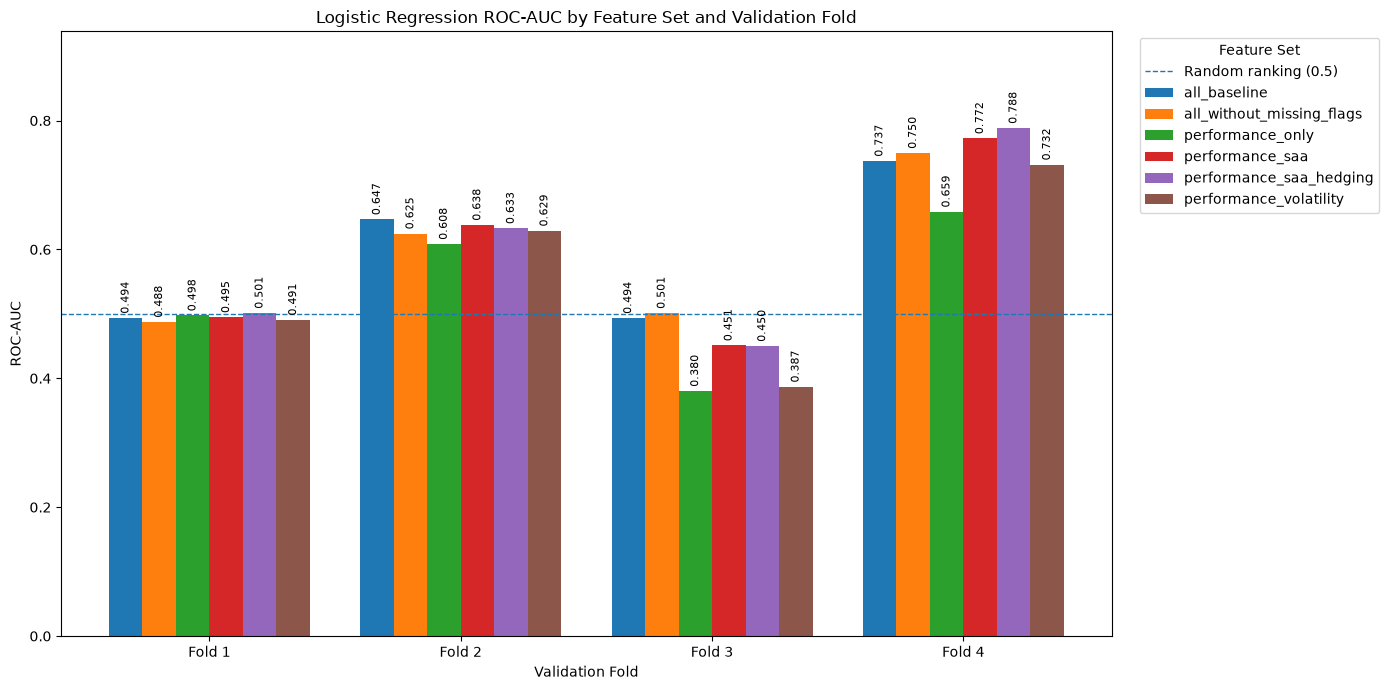

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Transpose so:
# rows = folds
# columns = feature sets
plot_data = ablation_auc_by_fold.T

# Plot settings
n_folds = len(plot_data.index)
n_feature_sets = len(plot_data.columns)

x = np.arange(n_folds)

group_width = 0.8
bar_width = group_width / n_feature_sets

fig, ax = plt.subplots(figsize=(14, 7))

# Create one bar series for each feature set
for i, feature_set in enumerate(
    plot_data.columns
):
    offset = (
        i - (n_feature_sets - 1) / 2
    ) * bar_width

    bars = ax.bar(
        x + offset,
        plot_data[feature_set],
        width=bar_width,
        label=feature_set,
    )

    # Add ROC-AUC value above each bar
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
        fontsize=8,
        rotation=90,
    )

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"Fold {fold}"
        for fold in plot_data.index
    ]
)

ax.set_xlabel("Validation Fold")
ax.set_ylabel("ROC-AUC")
ax.set_title(
    "Logistic Regression ROC-AUC by Feature Set and Validation Fold"
)

# ROC-AUC reference for random ranking
ax.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1,
    label="Random ranking (0.5)",
)

# Give labels enough room above bars
max_auc = plot_data.max().max()

ax.set_ylim(
    0,
    min(1.0, max_auc + 0.15)
)

ax.legend(
    title="Feature Set",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [45]:
# check the evaluation mean and variability
ablation_summary = (
    ablation_results
    .groupby(
        "feature_set"
    )
    .agg(
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        std_roc_auc=(
            "roc_auc",
            "std",
        ),
        min_roc_auc=(
            "roc_auc",
            "min",
        ),
        mean_average_precision=(
            "average_precision",
            "mean",
        ),
        std_average_precision=(
            "average_precision",
            "std",
        ),
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        mean_recall=(
            "recall",
            "mean",
        ),
        mean_brier_score=(
            "brier_score",
            "mean",
        ),
    )
    .sort_values(
        "mean_roc_auc",
        ascending=False,
    )
)

ablation_summary

,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,std_average_precision,mean_balanced_accuracy,mean_recall,mean_brier_score
feature_set,,,,,,,,
performance_saa_hedging,0.593274,0.151189,0.450206,0.387611,0.177106,0.551300,0.220927,0.230660
all_baseline,0.592900,0.120388,0.493567,0.382556,0.171148,0.563992,0.243584,0.225225
all_without_missing_flags,0.590855,0.122552,0.487608,0.379402,0.173451,0.547751,0.225971,0.234631
performance_saa,0.589151,0.145980,0.451166,0.402870,0.170196,0.549547,0.206284,0.227965
performance_volatility,0.559708,0.151620,0.386998,0.382036,0.203523,0.568605,0.235756,0.227835
performance_only,0.536263,0.123790,0.380392,0.329475,0.116406,0.529840,0.219634,0.248644


The first major finding is that performance features alone are not sufficient. performance_only has the weakest mean ROC-AUC (0.536) and the worst minimum fold performance (0.380 in Fold 3). Adding volatility improves the mean to 0.560 and substantially improves Fold 4 (0.659 → 0.732), but Fold 3 remains very weak (0.387). This suggests that volatility contains additional signal, but it does not solve the model's temporal instability by itself.

The second major finding is that SAA and hedging are especially valuable in recent periods, but their contribution is temporally unstable. Compared with performance_only, adding SAA raises Fold 4 ROC-AUC from 0.659 to 0.772, and adding hedging increases it further to 0.788. However, those same feature additions reduce Fold 3 performance from 0.380 to roughly 0.45. This shows that SAA information becomes much more useful in later periods, where SAA coverage is far better. But it also shows that richer SAA/hedging features do not automatically produce more robust historical performance.

The missingness indicators themselves doesn't looked like to be the main cause of the temporal instability. Removing saa_missing, volatility_5y_missing, and volatility_10y_missing changes mean ROC-AUC only slightly. Fold 4 improves slightly without them (0.737 → 0.750), but Fold 1 deteriorates and overall Brier score worsens from 0.225 to 0.235. The full baseline also has better mean balanced accuracy and recall. So for now, missingness flag will be kept because there is no evidence that they are driving the apparent recent-period advantage.

Not only that, for now, retain all_baseline as the main logistic-regression baseline, even though performance_saa_hedging has a marginally higher mean ROC-AUC because The difference is negligible, while all_baseline is materially more stable and also has the best Brier score (0.225) and higher mean recall (0.244). That suggests the additional volatility, strategy-change, and missingness information helps stabilise the model across regimes, even though it does not maximise the strongest recent fold.

In [46]:
# check the result if using a reduced subset of the existing feature sets
selected_feature_sets = {
    "performance_only":
        performance_features,

    "performance_saa_hedging":
        (
            performance_features
            + saa_features
            + hedging_features
        ),

    "all_baseline":
        baseline_features,

    "all_without_missing_flags":
        feature_sets[
            "all_without_missing_flags"
        ],
}

# re-run the model using selected features in quarter-level
selected_quarterly_ablation_results = []

for feature_set_name, features in selected_feature_sets.items():

    for fold in folds:

        train_data = (
            development_data.loc[
                fold["train_index"]
            ]
        )

        validation_data = (
            development_data.loc[
                fold["validation_index"]
            ]
            .copy()
        )

        X_train = train_data[
            features
        ]

        y_train = train_data[
            target_col
        ]

        X_validation = validation_data[
            features
        ]

        y_validation = validation_data[
            target_col
        ]

        model = clone(
            logistic_pipeline
        )

        model.fit(
            X_train,
            y_train,
        )

        validation_probability = (
            model.predict_proba(
                X_validation
            )[:, 1]
        )

        validation_prediction = (
            validation_probability
            >= 0.5
        ).astype(int)

        # Store predictions temporarily
        validation_data[
            "actual"
        ] = y_validation.to_numpy()

        validation_data[
            "probability"
        ] = validation_probability

        validation_data[
            "prediction"
        ] = validation_prediction

        # Calculate metrics separately for each quarter
        for (
            period,
            quarter_data,
        ) in validation_data.groupby(
            "period_end_date"
        ):

            metrics = (
                calculate_classification_metrics(
                    y_true=quarter_data[
                        "actual"
                    ],
                    y_pred=quarter_data[
                        "prediction"
                    ],
                    y_prob=quarter_data[
                        "probability"
                    ],
                )
            )

            selected_quarterly_ablation_results.append(
                {
                    "feature_set":
                        feature_set_name,

                    "fold":
                        fold["fold"],

                    "period_end_date":
                        period,

                    "n_features":
                        len(features),

                    "rows":
                        len(quarter_data),

                    "positive_rate":
                        quarter_data[
                            "actual"
                        ].mean(),

                    "predicted_positive_rate":
                        quarter_data[
                            "prediction"
                        ].mean(),

                    "mean_probability":
                        quarter_data[
                            "probability"
                        ].mean(),

                    **metrics,
                }
            )

# convert to dataframe
selected_quarterly_ablation_results = (
    pd.DataFrame(
        selected_quarterly_ablation_results
    )
    .sort_values(
        [
            "period_end_date",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)

selected_quarterly_ablation_results

,feature_set,fold,period_end_date,n_features,rows,positive_rate,predicted_positive_rate,mean_probability,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,all_baseline,1,2019-06-30,33,304,0.240132,0.069079,0.103294,0.723684,0.499615,0.238095,0.068493,0.106383,0.356995,0.195341,0.246989
1,all_without_missing_flags,1,2019-06-30,30,304,0.240132,0.042763,0.074397,0.750000,0.516931,0.384615,0.068493,0.116279,0.373362,0.216576,0.230274
2,performance_only,1,2019-06-30,13,304,0.240132,0.000000,0.051919,0.759868,0.500000,0.000000,0.000000,0.000000,0.357113,0.249673,0.220085
3,performance_saa_hedging,1,2019-06-30,25,304,0.240132,0.042763,0.080000,0.750000,0.516931,0.384615,0.068493,0.116279,0.384629,0.215495,0.230297
4,all_baseline,1,2019-09-30,33,304,0.246711,0.065789,0.083685,0.687500,0.456332,0.000000,0.000000,0.000000,0.304221,0.176724,0.269620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,performance_saa_hedging,4,2022-12-31,25,367,0.247956,0.122616,0.275147,0.798365,0.644967,0.688889,0.340659,0.455882,0.758520,0.590187,0.152983
60,all_baseline,4,2023-03-31,33,363,0.250689,0.046832,0.226991,0.779614,0.571408,0.823529,0.153846,0.259259,0.631060,0.430170,0.177969
61,all_without_missing_flags,4,2023-03-31,30,363,0.250689,0.057851,0.256889,0.774105,0.571388,0.714286,0.164835,0.267857,0.613809,0.437548,0.179453
62,performance_only,4,2023-03-31,13,363,0.250689,0.179063,0.402680,0.790634,0.673824,0.615385,0.439560,0.512821,0.635343,0.523382,0.195807


In [47]:
selected_quarterly_auc = (
    selected_quarterly_ablation_results
    .pivot(
        index="period_end_date",
        columns="feature_set",
        values="roc_auc",
    )
)

selected_quarterly_auc

feature_set,all_baseline,all_without_missing_flags,performance_only,performance_saa_hedging
period_end_date,,,,
2019-06-30,0.356995,0.373362,0.357113,0.384629
2019-09-30,0.304221,0.269694,0.251645,0.280873
2019-12-31,0.490055,0.555283,0.588920,0.591494
2020-03-31,0.758002,0.761298,0.831051,0.816715
2020-06-30,0.436195,0.325231,0.123031,0.355272
2020-09-30,0.817410,0.819005,0.835122,0.842318
2020-12-31,0.935253,0.939789,0.965166,0.948477
2021-03-31,0.830142,0.841638,0.858738,0.855343
2021-06-30,0.522284,0.524082,0.462601,0.514196


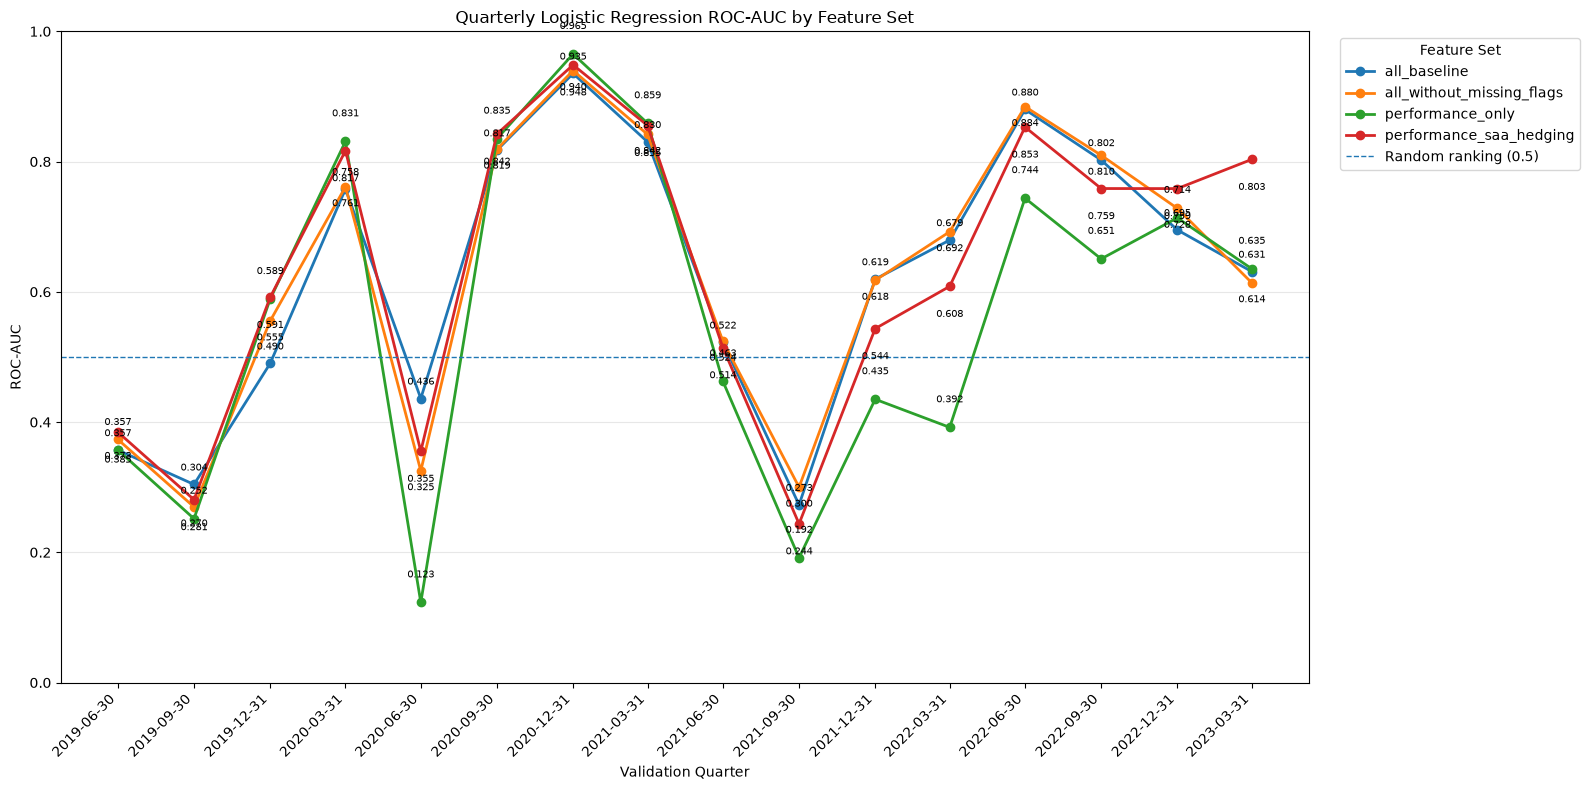

In [48]:
plot_data = (
    selected_quarterly_auc
    .copy()
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(16, 8)
)

label_offsets = [
    10,
    -14,
    18,
    -22,
]

# Draw each feature set as a separate line
for i, feature_set in enumerate(
    plot_data.columns
):

    ax.plot(
        plot_data.index,
        plot_data[feature_set],
        marker="o",
        linewidth=2,
        label=feature_set,
    )

    # Add ROC-AUC value at each point
    for date, value in zip(
        plot_data.index,
        plot_data[feature_set],
    ):
        ax.annotate(
            f"{value:.3f}",
            xy=(date, value),
            xytext=(
                0,
                label_offsets[i],
            ),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )

# Random-ranking reference line
ax.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1,
    label="Random ranking (0.5)",
)

# Axis labels and title
ax.set_xlabel(
    "Validation Quarter"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_title(
    "Quarterly Logistic Regression ROC-AUC by Feature Set"
)

# Show every quarterly date
ax.set_xticks(
    plot_data.index
)

ax.set_xticklabels(
    [
        date.strftime("%Y-%m-%d")
        for date in plot_data.index
    ],
    rotation=45,
    ha="right",
)

# Fixed ROC-AUC scale
ax.set_ylim(
    0,
    1,
)

# Legend
ax.legend(
    title="Feature Set",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

# Horizontal grid only
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [49]:
selected_quarterly_summary = (
    selected_quarterly_ablation_results
    .groupby("feature_set")
    .agg(
        mean_quarterly_roc_auc=(
            "roc_auc",
            "mean",
        ),
        std_quarterly_roc_auc=(
            "roc_auc",
            "std",
        ),
        min_quarterly_roc_auc=(
            "roc_auc",
            "min",
        ),
        max_quarterly_roc_auc=(
            "roc_auc",
            "max",
        ),
        mean_quarterly_average_precision=(
            "average_precision",
            "mean",
        ),
        mean_quarterly_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        mean_quarterly_recall=(
            "recall",
            "mean",
        ),
        mean_quarterly_brier_score=(
            "brier_score",
            "mean",
        ),
    )
    .sort_values(
        "mean_quarterly_roc_auc",
        ascending=False,
    )
)

selected_quarterly_summary

,mean_quarterly_roc_auc,std_quarterly_roc_auc,min_quarterly_roc_auc,max_quarterly_roc_auc,mean_quarterly_average_precision,mean_quarterly_balanced_accuracy,mean_quarterly_recall,mean_quarterly_brier_score
feature_set,,,,,,,,
performance_saa_hedging,0.634910,0.227185,0.243774,0.948477,0.463607,0.550337,0.215591,0.228828
all_without_missing_flags,0.628462,0.218921,0.269694,0.939789,0.453433,0.547790,0.221780,0.232033
all_baseline,0.626936,0.209840,0.272971,0.935253,0.452894,0.564406,0.242853,0.223561
performance_only,0.564707,0.256975,0.123031,0.965166,0.425751,0.525016,0.205947,0.247178


The main finding is that all_baseline is the best overall compromise, even though performance_saa_hedging has the highest mean quarterly ROC-AUC (0.635 vs 0.627). all_baseline has the lowest quarterly ROC-AUC variability among the three richer specifications (std = 0.210), the highest worst-quarter ROC-AUC (0.273), the best mean balanced accuracy (0.564), the best mean recall (0.243), and the lowest Brier score (0.224). In contrast, performance_saa_hedging improves average ranking slightly but is less stable and falls as low as 0.244. For an early-warning model, I would prefer the more robust specification rather than optimising a tiny difference in average AUC.

The missingness flags also appear worth retaining. Removing them raises mean quarterly ROC-AUC only slightly (0.627 → 0.628), but worsens Brier score (0.224 → 0.232), recall (0.243 → 0.222), balanced accuracy, and slightly worsens the worst-quarter performance. So the earlier hypothesis that missingness indicators might be driving harmful temporal behaviour is not supported. They seem to provide some useful information and modestly improve robustness/calibration.

Another important finding is that the difficult quarters are shared across feature sets. For example, all specifications perform poorly around 2019-06, 2019-09, 2020-06, and especially 2021-09. Conversely, most perform strongly in 2020-09, 2020-12, 2021-03, and much of 2022. That tells us the instability is probably not simply “SAA features are bad” or “missingness flags are bad.” There appears to be a broader temporal/regime dependence in the relationship between current features and future peer-relative performance. The performance_only model makes this even clearer: it occasionally performs extremely well (max AUC = 0.965) but is by far the least stable (min = 0.123, std = 0.257). Adding volatility, SAA, hedging, change features, and missingness information therefore seems to stabilise the model even if it does not eliminate regime effects.

### Investment-Option Robustness Check

The target column is in rse_abn + investment-option + quarter level. This is also used in defining peers to compare whether the certain asset at certain period will reach the bottom-quartile of its peers or not. Although the target is already defined consistently at the investment-option level, the model is trained and currently evaluated on product-menu-option representation rows. That means an investment option with multiple representations might contribute multiple times to AUC, precision, recall, and other metrics, while an option with only one representation contributes once. 

To check whether the model's apparent performance is materially affected by the unequal representation weighting, aggregating predictions to one score per investment option per quarter can be done so I can confirm that the conclusions still hold when each underlying investment option receives one equal vote.

In [50]:
# Store fold-level option-quarter evaluation results
option_level_results = []

# Define the investment-option-quarter grain.
option_keys = [
    "rse_abn",
    "abn_investment_option_identifier",
    "period_end_date",
]

# Loop through the same temporal validation folds used for the representation-level baseline model.
for fold in folds:

    # Select the leakage-safe training observations
    # for the current fold.
    train_data = (
        development_data.loc[
            fold["train_index"]
        ]
    )

    # Select the validation observations.
    # Copy is used because prediction columns will be temporarily added below.
    validation_data = (
        development_data.loc[
            fold["validation_index"]
        ]
        .copy()
    )

    # Use the full baseline feature set for training.
    X_train = train_data[
        baseline_features
    ]

    # Training target.
    y_train = train_data[
        target_col
    ]

    # Validation predictors.
    X_validation = validation_data[
        baseline_features
    ]

    # Create a fresh copy of the same logistic-regression pipeline used in the original baseline evaluation.
    model = clone(
        logistic_pipeline
    )

    # Fit preprocessing and logistic regression using training data only.
    model.fit(
        X_train,
        y_train,
    )

    # Generate the probability that each modelling row will become a future bottom-quartile performer.
    validation_data[
        "predicted_probability"
    ] = model.predict_proba(
        X_validation
    )[:, 1]


    # Check that repeated product/menu representations of the same investment option-quarter all have exactly the same target.
    # It should return a maximum of 1 because the target was constructed at investment-option-quarter level and mapped back to the modelling rows.
    target_consistency = (
        validation_data
        .groupby(
            option_keys
        )[target_col]
        .nunique()
    )

    # Stop immediately if conflicting targets exist within an investment option-quarter.
    assert (
        target_consistency.max() == 1
    )

    # Collapse repeated product/menu representations into one observation per investment option per quarter.
    # actual: The target is identical across representations, so taking the first value is safe.
    # predicted_probability: Take the mean prediction across the different product/menu representations of the same option.
    # representation_count: Records how many modelling rows contributed to each option-quarter prediction.
    option_validation = (
        validation_data
        .groupby(
            option_keys,
            as_index=False,
        )
        .agg(
            actual=(
                target_col,
                "first",
            ),
            predicted_probability=(
                "predicted_probability",
                "mean",
            ),
            representation_count=(
                target_col,
                "size",
            ),
        )
    )

    # Convert the aggregated option-level probability into a binary prediction using the same 0.5 threshold as the original baseline model.
    option_validation[
        "prediction"
    ] = (
        option_validation[
            "predicted_probability"
        ]
        >= 0.5
    ).astype(int)

    # Calculate the same classification metrics, but now each investment option-quarter receives exactly one vote in the evaluation.
    metrics = (
        calculate_classification_metrics(
            y_true=option_validation[
                "actual"
            ],
            y_pred=option_validation[
                "prediction"
            ],
            y_prob=option_validation[
                "predicted_probability"
            ],
        )
    )

    # Save fold-level diagnostics and performance metrics.
    option_level_results.append(
        {
            "fold":
                fold["fold"],

            "validation_start":
                option_validation[
                    "period_end_date"
                ].min(),

            "validation_end":
                option_validation[
                    "period_end_date"
                ].max(),

            # Number of unique investment option-quarter observations after aggregation.
            "option_quarter_rows":
                len(option_validation),

            # Average number of product/menu representations associated with each option-quarter.
            "mean_representations_per_option":
                option_validation[
                    "representation_count"
                ].mean(),

            # Largest number of repeated representations for option-quarter in this fold.
            "max_representations_per_option":
                option_validation[
                    "representation_count"
                ].max(),

            # Option-level target prevalence.
            "positive_rate":
                option_validation[
                    "actual"
                ].mean(),

            # Add evaluation metrics (ROC-AUC, Average Precision, recall, precision, Brier score, etc.)
            **metrics,
        }
    )

# Convert the accumulated fold results into a table
option_level_results = pd.DataFrame(
    option_level_results
)

option_level_results

,fold,validation_start,validation_end,option_quarter_rows,mean_representations_per_option,max_representations_per_option,positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,2019-06-30,2020-03-31,1063,1.184384,4,0.251176,0.684854,0.555603,0.349558,0.295880,0.320487,0.488392,0.294634,0.265669
1,2,2020-06-30,2021-03-31,1191,1.164568,4,0.253568,0.681780,0.511353,0.282486,0.165563,0.208768,0.641025,0.304232,0.241671
2,3,2021-06-30,2022-03-31,1058,1.185255,4,0.271267,0.690926,0.499214,0.267442,0.080139,0.123324,0.501661,0.277916,0.241541
3,4,2022-06-30,2023-03-31,1091,1.209899,4,0.252062,0.818515,0.664109,0.829060,0.352727,0.494898,0.729086,0.615879,0.149008


In [51]:
# Extract only the logistic-regression results from the original representation-level baseline evaluation.
representation_level_results = (
    fold_results[
        fold_results[
            "model"
        ].eq(
            "logistic_regression"
        )
    ]
    [
        [
            "fold",
            "roc_auc",
            "average_precision",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "accuracy",
            "brier_score",
        ]
    ]
    .copy()
)

# Rename representation-level metrics to have a clear difference from option-level metrics after the two tables are merged.
representation_level_results = (
    representation_level_results
    .rename(
        columns={
            col:
                f"representation_{col}"
            for col in [
                "roc_auc",
                "average_precision",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1",
                "accuracy",
                "brier_score",
            ]
        }
    )
)

# Keep the equivalent metrics from the option-quarter robustness evaluation.
option_metric_results = (
    option_level_results[
        [
            "fold",
            "roc_auc",
            "average_precision",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "accuracy",
            "brier_score",
        ]
    ]

    # Rename them with an "option_" prefix
    .rename(
        columns={
            col:
                f"option_{col}"
            for col in [
                "roc_auc",
                "average_precision",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1",
                "accuracy",
                "brier_score",
            ]
        }
    )
)

# Join representation-level and option-quarter metrics
robustness_comparison = (
    representation_level_results
    .merge(
        option_metric_results,
        on="fold",
        how="inner",
    )
)

robustness_comparison[
    [
        "fold",
        "representation_roc_auc",
        "option_roc_auc",
        "representation_average_precision",
        "option_average_precision",
        "representation_recall",
        "option_recall",
        "representation_brier_score",
        "option_brier_score",
    ]
]

,fold,representation_roc_auc,option_roc_auc,representation_average_precision,option_average_precision,representation_recall,option_recall,representation_brier_score,option_brier_score
0,1,0.493813,0.488392,0.310312,0.294634,0.315287,0.295880,0.254806,0.265669
1,2,0.646782,0.641025,0.323816,0.304232,0.188172,0.165563,0.249468,0.241671
2,3,0.493567,0.501661,0.260131,0.277916,0.067847,0.080139,0.251112,0.241541
3,4,0.737438,0.729086,0.635967,0.615879,0.403030,0.352727,0.145512,0.149008


In [52]:
# Positive ROC-AUC difference:  option-level evaluation performs better.
# Negative difference:  representation-level evaluation performs better.
robustness_comparison["roc_auc_difference"] = (
    robustness_comparison["option_roc_auc"] - robustness_comparison["representation_roc_auc"]
)

# Calculate the same difference for Average Precision.
robustness_comparison["average_precision_difference"] = (
    robustness_comparison["option_average_precision"] -
    robustness_comparison["representation_average_precision"]
)

robustness_comparison[
    [
        "fold",
        "roc_auc_difference",
        "average_precision_difference",
    ]
]

,fold,roc_auc_difference,average_precision_difference
0,1,-0.005420,-0.015678
1,2,-0.005758,-0.019584
2,3,0.008094,0.017785
3,4,-0.008352,-0.020088


Aggregating validation predictions from the product-menu-option representation level to one prediction per investment option per quarter produced only minor changes in model performance. Fold-level ROC-AUC differences ranged from approximately -0.008 to +0.008, while Average Precision differences remained within approximately ±0.02. The temporal performance pattern was unchanged, indicating that repeated product/menu representations do not materially bias the baseline evaluation. Representation-level metrics can therefore remain the primary modelling evaluation, with option-quarter results retained as a robustness check.

### Non-linear baseline modelling

#### Random Forest

Since using logistic-regression yield poor result, the next step is to try train a model that is good with non-linear relationships.

Random Forest is used to test whether the relationship between current investment characteristics and future bottom-quartile performance is meaningfully nonlinear. Logistic Regression assumes largely additive, linear effects, whereas Random Forest can automatically capture nonlinear thresholds and interactions between variables such as recent returns, volatility, strategic asset allocation, hedging, and strategy changes without requiring those interactions to be specified manually. To ensure a fair comparison, the Random Forest will use the same all_baseline feature set, target definition, purged expanding-window validation folds, and evaluation metrics, so any improvement can be attributed primarily to the change in model structure rather than to differences in data preparation or validation.

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
# create random forest model pipeline with default parameters
# pipeline without imputing null values
random_forest_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# pipeline with imputing null values
# random_forest_pipeline = Pipeline(
#     steps=[
#         (
#             "imputer",
#             SimpleImputer(strategy="median"),
#         ),
#         (
#             "classifier",
#             RandomForestClassifier(
#                 n_estimators=500,
#                 random_state=42,
#                 n_jobs=-1,
#             ),
#         ),
#     ]
# )

In [55]:
# use the same validation windows as the previous validation scheme
rf_fold_windows = [
    {
        "fold": 1,
        "validation_start": pd.Timestamp("2019-06-30"),
        "validation_end": pd.Timestamp("2020-03-31"),
    },
    {
        "fold": 2,
        "validation_start": pd.Timestamp("2020-06-30"),
        "validation_end": pd.Timestamp("2021-03-31"),
    },
    {
        "fold": 3,
        "validation_start": pd.Timestamp("2021-06-30"),
        "validation_end": pd.Timestamp("2022-03-31"),
    },
    {
        "fold": 4,
        "validation_start": pd.Timestamp("2022-06-30"),
        "validation_end": pd.Timestamp("2023-03-31"),
    },
]


# for now, keep the threshold the same as logistic-regression model for comparison
BASELINE_THRESHOLD = 0.5

rf_fold_results = []
rf_oof_predictions = []

# initiate model training for each "fold"
for fold_info in rf_fold_windows:

    fold_number = fold_info["fold"]
    validation_start = fold_info["validation_start"]
    validation_end = fold_info["validation_end"]

    # -------------------------
    # Training population
    # -------------------------
    # defining the train dataset range based on:
    # period_end_date < validation_start
    # target_end_date < validation_start
    train_mask = (
        model_data["period_end_date"].lt(validation_start)
        &
        model_data["target_end_date"].lt(validation_start)
    )

    # -------------------------
    # Validation population
    # -------------------------
    validation_mask = (
        model_data["period_end_date"].between(validation_start,validation_end,)
    )

    train_data = (
        model_data[train_mask].copy()
    )

    validation_data = (
        model_data[validation_mask].copy()
    )

    X_train = train_data[baseline_features]

    y_train = train_data[target_col]

    X_validation = validation_data[baseline_features]

    y_validation = validation_data[target_col]

    # -------------------------
    # Fit a fresh model
    # -------------------------
    model = clone(random_forest_pipeline)

    model.fit(X_train,y_train,)

    # -------------------------
    # Probabilities
    # -------------------------
    validation_probability = (
        model.predict_proba(X_validation)[:, 1]
    )

    validation_prediction = (
        validation_probability >= BASELINE_THRESHOLD
    ).astype(int)

    # -------------------------
    # Fold metrics
    # -------------------------
    rf_fold_results.append(
        {
            "fold": fold_number,
            "validation_start":
                validation_start,
            "validation_end":
                validation_end,
            "train_rows":
                len(train_data),
            "validation_rows":
                len(validation_data),
            "positive_rate":
                y_validation.mean(),
            "accuracy":
                accuracy_score(
                    y_validation,
                    validation_prediction,
                ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_validation,
                    validation_prediction,
                ),
            "precision":
                precision_score(
                    y_validation,
                    validation_prediction,
                    zero_division=0,
                ),
            "recall":
                recall_score(
                    y_validation,
                    validation_prediction,
                    zero_division=0,
                ),
            "f1":
                f1_score(
                    y_validation,
                    validation_prediction,
                    zero_division=0,
                ),
            "roc_auc":
                roc_auc_score(
                    y_validation,
                    validation_probability,
                ),
            "average_precision":
                average_precision_score(
                    y_validation,
                    validation_probability,
                ),
            "brier_score":
                brier_score_loss(
                    y_validation,
                    validation_probability,
                ),
        }
    )

    # -------------------------
    # Preserve OOF predictions
    # -------------------------
    fold_oof = validation_data[
        [
            "rse_abn",
            "abn_product_identifier",
            "abn_investment_menu_identifier",
            "abn_investment_option_identifier",
            "period_end_date",
            target_col,
        ]
    ].copy()

    fold_oof["fold"] = fold_number

    fold_oof["predicted_probability"] = validation_probability

    fold_oof["prediction"] = validation_prediction

    rf_oof_predictions.append(
        fold_oof
    )

In [56]:
rf_fold_results = pd.DataFrame( rf_fold_results)

rf_oof_predictions = pd.concat(
    rf_oof_predictions,
    ignore_index=True,
)

rf_fold_results

,fold,validation_start,validation_end,train_rows,validation_rows,positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,2019-06-30,2020-03-31,2722,1259,0.249404,0.760127,0.540373,0.615385,0.101911,0.174863,0.575410,0.383897,0.186133
1,2,2020-06-30,2021-03-31,3783,1387,0.268205,0.717376,0.513138,0.364865,0.072581,0.121076,0.488440,0.283097,0.209269
2,3,2021-06-30,2022-03-31,5042,1254,0.270335,0.709729,0.502123,0.288136,0.050147,0.085427,0.594255,0.318116,0.199763
3,4,2022-06-30,2023-03-31,6429,1320,0.250000,0.805303,0.620707,0.892473,0.251515,0.392435,0.836007,0.706583,0.132552


In [57]:
rf_fold_results[
    [
        "fold",
        "train_rows",
        "validation_rows",
        "positive_rate",
    ]
]

,fold,train_rows,validation_rows,positive_rate
0,1,2722,1259,0.249404
1,2,3783,1387,0.268205
2,3,5042,1254,0.270335
3,4,6429,1320,0.250000


In [58]:
# summarise result
rf_summary = pd.Series(
    {
        "mean_roc_auc":
            rf_fold_results["roc_auc"].mean(),

        "std_roc_auc":
            rf_fold_results["roc_auc"].std(),

        "mean_average_precision":
            rf_fold_results["average_precision"].mean(),

        "std_average_precision":
            rf_fold_results["average_precision"].std(),

        "mean_balanced_accuracy":
            rf_fold_results["balanced_accuracy"].mean(),

        "mean_precision":
            rf_fold_results["precision"].mean(),

        "mean_recall":
            rf_fold_results["recall"].mean(),

        "mean_f1":
            rf_fold_results["f1"].mean(),

        "mean_accuracy":
            rf_fold_results["accuracy"].mean(),

        "mean_brier_score":
            rf_fold_results["brier_score"].mean(),
    }
)

rf_summary

mean_roc_auc              0.623528
std_roc_auc               0.148961
mean_average_precision    0.422923
std_average_precision     0.193668
mean_balanced_accuracy    0.544085
mean_precision            0.540215
mean_recall               0.119039
mean_f1                   0.193450
mean_accuracy             0.748134
mean_brier_score          0.181929
dtype: float64

The Random Forest baseline improved mean ROC-AUC from 0.593 to 0.624 and outperformed Logistic Regression in three of the four temporal validation folds, suggesting that nonlinear relationships and interactions between the baseline features contain additional predictive information. Improvements were particularly evident in Folds 1, 3, and 4, while Fold 2 deteriorated substantially from a ROC-AUC of 0.647 to 0.488. Random Forest also achieved a higher mean Average Precision and a substantially lower mean Brier score, indicating stronger overall ranking and probability quality. However, its fold-to-fold ROC-AUC variability increased, so temporal instability remains unresolved. 

In addition, Random Forest produced lower recall and F1 scores than Logistic Regression in every fold: mean recall decreased from 0.244 to 0.119 and mean F1 decreased from 0.304 to 0.193. This indicates that, at the fixed 0.5 classification threshold, Random Forest is substantially more conservative in predicting future bottom-quartile cases. Its higher mean precision reflects that the smaller number of positive predictions are more often correct, but many true underperforming options are missed. Therefore, Random Forest currently shows stronger ranking performance than Logistic Regression overall, but worse threshold-dependent detection performance at 0.5, which should be treated separately when evaluating its suitability for an early-warning system.

Need to check quarter-level result to compare it with logistic-regression.

In [59]:
# Check the stored Random Forest OOF predictions.
rf_oof_predictions.info()

rf_oof_predictions.head()

<class 'pandas.DataFrame'>
RangeIndex: 5220 entries, 0 to 5219
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   rse_abn                           5220 non-null   string        
 1   abn_product_identifier            5220 non-null   string        
 2   abn_investment_menu_identifier    5220 non-null   string        
 3   abn_investment_option_identifier  5220 non-null   str           
 4   period_end_date                   5220 non-null   datetime64[us]
 5   future_4q_bottom_quartile         5220 non-null   int8          
 6   fold                              5220 non-null   int64         
 7   predicted_probability             5220 non-null   float64       
 8   prediction                        5220 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2), int8(1), str(1), string(3)
memory usage: 728.3 KB


,rse_abn,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,period_end_date,future_4q_bottom_quartile,fold,predicted_probability,prediction
0,11789425178,11789425178-11789425178832,11789425178-IM2,11789425178-MC1H,2019-06-30,0,1,0.162,0
1,19905422981,19905422981-CSDMYSUPER1,19905422981-CSDMYSUPER1,19905422981-SP190029,2019-06-30,0,1,0.406,0
2,19905422981,19905422981-CSDMYSUPER1,19905422981-CSDMYSUPER1,19905422981-SP192933,2019-06-30,0,1,0.376,0
3,19905422981,19905422981-CSDMYSUPER1,19905422981-CSDMYSUPER1,19905422981-SP193438,2019-06-30,0,1,0.406,0
4,19905422981,19905422981-CSDMYSUPER1,19905422981-CSDMYSUPER1,19905422981-SP193943,2019-06-30,0,1,0.408,0


In [60]:
# Calculate Random Forest performance separately for each validation quarter.
rf_quarterly_results = []

for (fold_number, quarter), quarter_data in (
    rf_oof_predictions
    .groupby(["fold","period_end_date",])
):

    y_true = quarter_data[target_col]

    y_probability = quarter_data["predicted_probability"]

    y_prediction = quarter_data["prediction"]

    rf_quarterly_results.append(
        {
            "fold": fold_number,
            "period_end_date": quarter,
            "rows": len(quarter_data),
            "positive_rate":
                y_true.mean(),

            "accuracy":
                accuracy_score(y_true,y_prediction,),

            "balanced_accuracy":
                balanced_accuracy_score(y_true, y_prediction,),

            "precision":
                precision_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "recall":
                recall_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "f1":
                f1_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "roc_auc":
                roc_auc_score(y_true, y_probability,),

            "average_precision":
                average_precision_score(y_true, y_probability,),

            "brier_score":
                brier_score_loss(y_true, y_probability,),
        }
    )

# Convert quarterly results into a sorted dataframe.
rf_quarterly_results = (
    pd.DataFrame(rf_quarterly_results)
    .sort_values("period_end_date")
    .reset_index(drop=True)
)

rf_quarterly_results

,fold,period_end_date,rows,positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,2019-06-30,304,0.240132,0.746711,0.491342,0.000000,0.000000,0.000000,0.505989,0.229813,0.201827
1,1,2019-09-30,304,0.246711,0.713816,0.473799,0.000000,0.000000,0.000000,0.406783,0.209623,0.227555
2,1,2019-12-31,305,0.242623,0.783607,0.572423,0.750000,0.162162,0.266667,0.507342,0.399414,0.185122
3,1,2020-03-31,346,0.265896,0.791908,0.608696,1.000000,0.217391,0.357143,0.935510,0.905025,0.136843
4,2,2020-06-30,346,0.265896,0.638728,0.435039,0.000000,0.000000,0.000000,0.139079,0.161970,0.282941
5,2,2020-09-30,346,0.263006,0.803468,0.626374,1.000000,0.252747,0.403509,0.629563,0.597396,0.165120
6,2,2020-12-31,346,0.265896,0.736994,0.505435,1.000000,0.010870,0.021505,0.420126,0.243040,0.209294
7,2,2021-03-31,349,0.277937,0.690544,0.487686,0.176471,0.030928,0.052632,0.751861,0.499081,0.179976
8,3,2021-06-30,360,0.252778,0.713889,0.477695,0.000000,0.000000,0.000000,0.465215,0.260645,0.213796
9,3,2021-09-30,318,0.330189,0.666667,0.521797,0.476190,0.095238,0.158730,0.667337,0.448364,0.211564


In [61]:
# Display the main ranking and classification metrics by quarter.
rf_quarterly_results[
    [
        "fold",
        "period_end_date",
        "positive_rate",
        "roc_auc",
        "average_precision",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "brier_score",
    ]
]

,fold,period_end_date,positive_rate,roc_auc,average_precision,balanced_accuracy,precision,recall,f1,brier_score
0,1,2019-06-30,0.240132,0.505989,0.229813,0.491342,0.000000,0.000000,0.000000,0.201827
1,1,2019-09-30,0.246711,0.406783,0.209623,0.473799,0.000000,0.000000,0.000000,0.227555
2,1,2019-12-31,0.242623,0.507342,0.399414,0.572423,0.750000,0.162162,0.266667,0.185122
3,1,2020-03-31,0.265896,0.935510,0.905025,0.608696,1.000000,0.217391,0.357143,0.136843
4,2,2020-06-30,0.265896,0.139079,0.161970,0.435039,0.000000,0.000000,0.000000,0.282941
5,2,2020-09-30,0.263006,0.629563,0.597396,0.626374,1.000000,0.252747,0.403509,0.165120
6,2,2020-12-31,0.265896,0.420126,0.243040,0.505435,1.000000,0.010870,0.021505,0.209294
7,2,2021-03-31,0.277937,0.751861,0.499081,0.487686,0.176471,0.030928,0.052632,0.179976
8,3,2021-06-30,0.252778,0.465215,0.260645,0.477695,0.000000,0.000000,0.000000,0.213796
9,3,2021-09-30,0.330189,0.667337,0.448364,0.521797,0.476190,0.095238,0.158730,0.211564


In [62]:
# Summarise Random Forest performance across all validation quarters.
rf_quarterly_summary = pd.Series(
    {
        "mean_roc_auc":
            rf_quarterly_results["roc_auc"].mean(),

        "std_roc_auc":
            rf_quarterly_results["roc_auc"].std(),

        "min_roc_auc":
            rf_quarterly_results["roc_auc"].min(),

        "max_roc_auc":
            rf_quarterly_results["roc_auc"].max(),

        "mean_average_precision":
            rf_quarterly_results["average_precision"].mean(),

        "mean_balanced_accuracy":
            rf_quarterly_results["balanced_accuracy"].mean(),

        "mean_precision":
            rf_quarterly_results["precision"].mean(),

        "mean_recall":
            rf_quarterly_results["recall"].mean(),

        "mean_f1":
            rf_quarterly_results["f1"].mean(),

        "mean_brier_score":
            rf_quarterly_results["brier_score"].mean(),
    }
)

rf_quarterly_summary

mean_roc_auc              0.634371
std_roc_auc               0.216402
min_roc_auc               0.139079
max_roc_auc               0.935510
mean_average_precision    0.468765
mean_balanced_accuracy    0.544527
mean_precision            0.525502
mean_recall               0.120076
mean_f1                   0.187708
mean_brier_score          0.181469
dtype: float64

In [63]:
# Rank quarters by ROC-AUC to identify the weakest historical regimes.
rf_quarterly_results[
    [
        "fold",
        "period_end_date",
        "roc_auc",
        "average_precision",
        "recall",
        "f1",
        "brier_score",
    ]
].sort_values(
    "roc_auc"
)

,fold,period_end_date,roc_auc,average_precision,recall,f1,brier_score
4,2,2020-06-30,0.139079,0.161970,0.000000,0.000000,0.282941
1,1,2019-09-30,0.406783,0.209623,0.000000,0.000000,0.227555
6,2,2020-12-31,0.420126,0.243040,0.010870,0.021505,0.209294
8,3,2021-06-30,0.465215,0.260645,0.000000,0.000000,0.213796
0,1,2019-06-30,0.505989,0.229813,0.000000,0.000000,0.201827
2,1,2019-12-31,0.507342,0.399414,0.162162,0.266667,0.185122
5,2,2020-09-30,0.629563,0.597396,0.252747,0.403509,0.165120
9,3,2021-09-30,0.667337,0.448364,0.095238,0.158730,0.211564
10,3,2021-12-31,0.674040,0.347221,0.014085,0.025000,0.179659
11,3,2022-03-31,0.682607,0.333335,0.083333,0.134831,0.189162


In [64]:
# Compare actual and predicted positive rates by quarter.
rf_quarterly_prediction_rates = (
    rf_oof_predictions
    .groupby(
        ["fold","period_end_date",]
    )
    .agg(
        actual_positive_rate=(target_col,"mean",),
        predicted_positive_rate=("prediction", "mean",),
        mean_predicted_probability=("predicted_probability","mean",),
    )
    .reset_index()
)

# rf_quarterly_prediction_rates

# Combine quarterly performance with probability and warning-rate diagnostics.
rf_quarterly_diagnostics = (
    rf_quarterly_results
    .merge(
        rf_quarterly_prediction_rates,
        on=[
            "fold",
            "period_end_date",
        ],
        how="left",
    )
)

rf_quarterly_diagnostics[
    [
        "fold",
        "period_end_date",
        "roc_auc",
        "average_precision",
        "actual_positive_rate",
        "predicted_positive_rate",
        "mean_predicted_probability",
        "recall",
        "f1",
        "brier_score",
    ]
]

,fold,period_end_date,roc_auc,average_precision,actual_positive_rate,predicted_positive_rate,mean_predicted_probability,recall,f1,brier_score
0,1,2019-06-30,0.505989,0.229813,0.240132,0.013158,0.193158,0.000000,0.000000,0.201827
1,1,2019-09-30,0.406783,0.209623,0.246711,0.039474,0.165441,0.000000,0.000000,0.227555
2,1,2019-12-31,0.507342,0.399414,0.242623,0.052459,0.167987,0.162162,0.266667,0.185122
3,1,2020-03-31,0.935510,0.905025,0.265896,0.057803,0.242971,0.217391,0.357143,0.136843
4,2,2020-06-30,0.139079,0.161970,0.265896,0.095376,0.323740,0.000000,0.000000,0.282941
5,2,2020-09-30,0.629563,0.597396,0.263006,0.066474,0.230434,0.252747,0.403509,0.165120
6,2,2020-12-31,0.420126,0.243040,0.265896,0.002890,0.227347,0.010870,0.021505,0.209294
7,2,2021-03-31,0.751861,0.499081,0.277937,0.048711,0.251851,0.030928,0.052632,0.179976
8,3,2021-06-30,0.465215,0.260645,0.252778,0.033333,0.307311,0.000000,0.000000,0.213796
9,3,2021-09-30,0.667337,0.448364,0.330189,0.066038,0.271742,0.095238,0.158730,0.211564


Random Forest has useful nonlinear signal, but its behaviour is still strongly regime-dependent and its default 0.5 decision rule is poor for an early-warning objective. When looking at Fold 2 quarters, Fold 2 weakness is systematic across the entire validation block, not caused by one anomalous quarter. Fold 2 is particularly important because all four quarters worsen, including the extremely poor 2020-06-30 AUC of 0.139. This shows that nonlinear modelling does not simply make the model universally better but it learns relationships that transfer well into some regimes and very poorly into others.

The gain in mean quarterly ROC-AUC is therefore actually quite small, about +0.007, while variability is slightly worse and the worst RF quarter is substantially worse. On the other hand, RF has a considerably better Brier score. So there is evidence of improved probability quality overall, but not improved temporal robustness.

But threshold-dependent metrics shows limitiation of RF. Mean quarterly accuracy is around 0.749, which looks good superficially, but the target is only roughly 25% positive. A model predicting mostly negatives can already achieve accuracy near 75%. The balanced accuracy of only 0.545 therefore gives a much more realistic assessment of its classification performance. Same thing happen with recall (Mean recall = 0.120). RF detects only about 12% of true positive cases on average at the 0.5 threshold but 4 quarters have 0 recall. This means that he model fails to issue a positive classification for any actual future bottom-quartile observation, which might explain why F1 score is also poor.

Even in the excellent Fold 4 quarters, RF remains conservative, for example in 2022-06-30. This is probably the best overall RF quarter, because multiple metrics agree: excellent ranking, excellent precision, materially better recall, strong F1 and balanced accuracy, and low Brier score. It is not merely good according to one metric. In contrast of 2020-06-30, which is bad across multiple metrics. Interestingly, its mean predicted probability is 0.324, which is actually higher than the actual positive rate of 0.266. Therefore, this quarter cannot be explained simply by saying "the 0.5 threshold is too high." The ranking itself is badly wrong: relatively large probabilities are being assigned to the wrong observations. Lowering the threshold cannot fix an AUC of 0.139.

<b>In summary</b> <br>
Random Forest provides evidence that nonlinear relationships improve predictive ranking in many historical periods, outperforming the Logistic Regression baseline in 11 of 16 validation quarters and producing substantially better probability calibration overall. However, this improvement is not temporally stable. All four quarters in Fold 2 deteriorate relative to Logistic Regression, including an extreme ranking failure in 2020 Q2, and the quarterly ROC-AUC variability remains slightly higher than the linear baseline. Threshold-dependent performance is also considerably weaker: at the fixed 0.5 threshold, Random Forest predicts far fewer positive cases than actually occur, resulting in mean recall of only 0.120 and mean F1 of 0.188, with zero recall in four quarters. High accuracy and occasionally very high precision should therefore not be interpreted as strong detection performance because they are partly driven by the model's conservative positive predictions and the approximately 25% positive-class prevalence. Overall, Random Forest demonstrates stronger nonlinear ranking and probability quality in many periods, but does not resolve temporal instability and currently performs poorly as a positive-case detection system under the default threshold.

Try other non-linear model. One thing to try is Gradient Boosting

#### Gradient Boosting

Gradient Boosting model used Histogram Gradient Boosting Classifier (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)

According to scikit, this estimator is much faster than GradientBoostingClassifier for big datasets (n_samples >= 10 000), which is appropriate for this case. This is because HistGradientBoostingClassifier uses bins to split the tree rather than individual values. This estimator has native support for missing values (NaNs). During training, the tree grower learns at each split point whether samples with missing values should go to the left or right child, based on the potential gain. When predicting, samples with missing values are assigned to the left or right child consequently. If no missing values were encountered for a given feature during training, then samples with missing values are mapped to whichever child has the most samples.

In [65]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [66]:
# Define a default parameter HistGradientBoosting baseline with native NaN handling.
hist_gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            HistGradientBoostingClassifier(
                loss="log_loss",
                learning_rate=0.1,
                max_iter=100,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=0.0,
                categorical_features=None,
                early_stopping=False,
                random_state=42,
            ),
        ),
    ]
)

Early stopping is set to False because the training process will use the same temporal validation framework as previous model training. Setting it to False avoids the model creating an additional internal validation subset. This also ensures that every eligible training observation is available to the baseline model.

In [67]:
# Reuse the exact same temporal validation windows used for Random Forest.
hgb_fold_windows = rf_fold_windows

# Create containers for fold metrics and out-of-fold predictions.
hgb_fold_results = []
hgb_oof_predictions = []

BASELINE_THRESHOLD = 0.5

# Train and evaluate HistGradientBoosting on each purged temporal fold.
for fold_info in hgb_fold_windows:

    fold_number = fold_info["fold"]
    validation_start = fold_info["validation_start"]
    validation_end = fold_info["validation_end"]

    # Keep only training rows whose future target is fully known before validation.
    train_mask = (
        model_data["period_end_date"].lt(validation_start)
        &
        model_data["target_end_date"].lt(validation_start)
    )

    # Select observations belonging to the current validation block.
    validation_mask = (
        model_data["period_end_date"].between(
            validation_start,
            validation_end,
        )
    )

    train_data = (
        model_data[train_mask].copy()
    )

    validation_data = (
        model_data[validation_mask].copy()
    )

    # Use the same all_baseline predictors as the previous models.
    X_train = train_data[baseline_features]
    y_train = train_data[target_col]

    X_validation = validation_data[baseline_features]

    y_validation = validation_data[target_col]

    # Clone a fresh model so each fold is trained independently.
    model = clone(hist_gradient_boosting_pipeline)

    model.fit(X_train,y_train,)

    # Generate positive-class probabilities for the validation period.
    validation_probability = (
        model.predict_proba(X_validation)[:, 1]
    )

    # Apply the unchanged 0.5 baseline classification threshold.
    validation_prediction = (
        validation_probability >= BASELINE_THRESHOLD
    ).astype(int)

    # Store fold-level ranking, classification, and probability metrics.
    hgb_fold_results.append(
        {
            "fold"                : fold_number,
            "validation_start"    : validation_start,
            "validation_end"      : validation_end,
            "train_rows"          : len(train_data),
            "validation_rows"     : len(validation_data),
            "train_target_end_max": train_data["target_end_date"].max(),
            "positive_rate"       : y_validation.mean(),
            
            "accuracy"            : accuracy_score(y_validation, validation_prediction,),
            "balanced_accuracy"   : balanced_accuracy_score(y_validation, validation_prediction,),
            
            "precision"           : precision_score(y_validation, validation_prediction, zero_division=0,),
            "recall"              : recall_score(y_validation, validation_prediction, zero_division=0,),
            "f1"                  : f1_score(y_validation, validation_prediction, zero_division=0,),
            "roc_auc"             : roc_auc_score(y_validation, validation_probability,),
            "average_precision"   : average_precision_score(y_validation, validation_probability,),
            "brier_score"         : brier_score_loss(y_validation, validation_probability,),
        }
    )

    # Preserve row-level OOF probabilities for later quarterly diagnostics.
    fold_oof = validation_data[
        [
            "rse_abn",
            "abn_product_identifier",
            "abn_investment_menu_identifier",
            "abn_investment_option_identifier",
            "period_end_date",
            target_col,
        ]
    ].copy()

    fold_oof["fold"] = fold_number

    fold_oof["predicted_probability"] = validation_probability

    fold_oof["prediction"] = validation_prediction

    hgb_oof_predictions.append(fold_oof)

In [68]:
# Convert fold results and OOF predictions into reusable dataframes.
hgb_fold_results = pd.DataFrame(
    hgb_fold_results
)

hgb_oof_predictions = pd.concat(
    hgb_oof_predictions,
    ignore_index=True,
)

# Display the complete HistGradientBoosting fold results.
hgb_fold_results

,fold,validation_start,validation_end,train_rows,validation_rows,train_target_end_max,positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,2019-06-30,2020-03-31,2722,1259,2019-03-31,0.249404,0.740270,0.500564,0.259259,0.022293,0.041056,0.538724,0.295369,0.239524
1,2,2020-06-30,2021-03-31,3783,1387,2020-03-31,0.268205,0.702235,0.484060,0.098039,0.013441,0.023641,0.438608,0.239635,0.264859
2,3,2021-06-30,2022-03-31,5042,1254,2021-03-31,0.270335,0.669856,0.468301,0.105263,0.029499,0.046083,0.509272,0.256802,0.277982
3,4,2022-06-30,2023-03-31,6429,1320,2022-03-31,0.250000,0.832576,0.707576,0.782383,0.457576,0.577438,0.804830,0.628715,0.140124


In [69]:
# Confirm that fold sizes and target prevalence match the previous models.
hgb_fold_results[
    [
        "fold",
        "train_rows",
        "validation_rows",
        "positive_rate",
    ]
]

,fold,train_rows,validation_rows,positive_rate
0,1,2722,1259,0.249404
1,2,3783,1387,0.268205
2,3,5042,1254,0.270335
3,4,6429,1320,0.250000


In [70]:
# Summarise HistGradientBoosting performance across the four folds.
hgb_summary = pd.Series(
    {
        "mean_roc_auc": hgb_fold_results["roc_auc"].mean(),
        "std_roc_auc": hgb_fold_results["roc_auc"].std(),
        
        "mean_average_precision": hgb_fold_results["average_precision"].mean(),
        "std_average_precision": hgb_fold_results["average_precision"].std(),
        
        "mean_balanced_accuracy": hgb_fold_results["balanced_accuracy"].mean(),
        "mean_precision": hgb_fold_results["precision"].mean(),
        "mean_recall": hgb_fold_results["recall"].mean(),
        "mean_f1": hgb_fold_results["f1"].mean(),
        "mean_accuracy": hgb_fold_results["accuracy"].mean(),
        "mean_brier_score": hgb_fold_results["brier_score"].mean(),
    }
)

hgb_summary

mean_roc_auc              0.572858
std_roc_auc               0.160252
mean_average_precision    0.355131
std_average_precision     0.183873
mean_balanced_accuracy    0.540125
mean_precision            0.311236
mean_recall               0.130702
mean_f1                   0.172054
mean_accuracy             0.736234
mean_brier_score          0.230622
dtype: float64

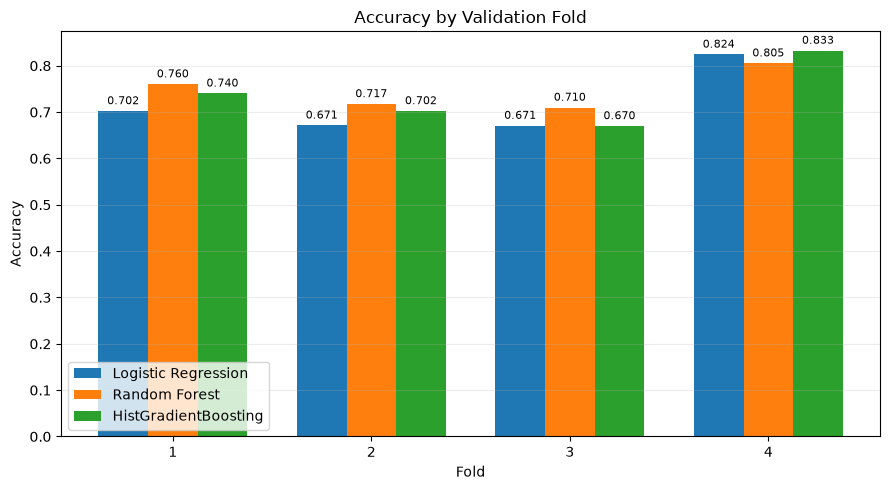

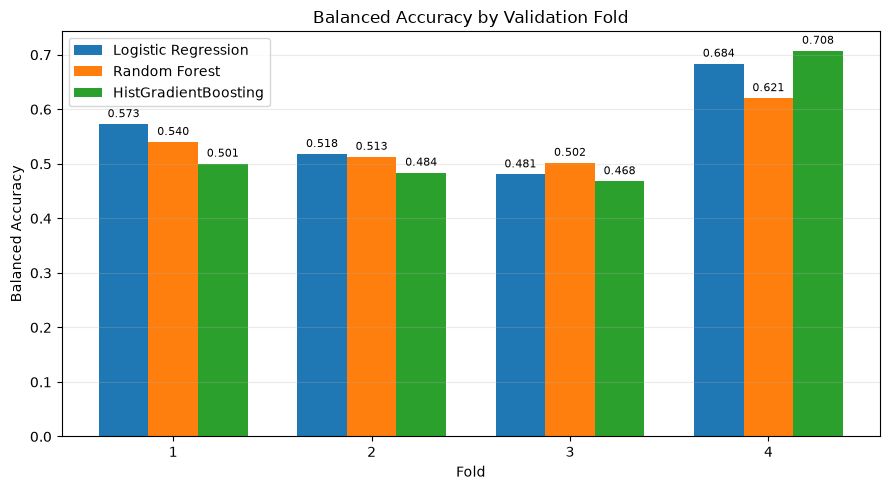

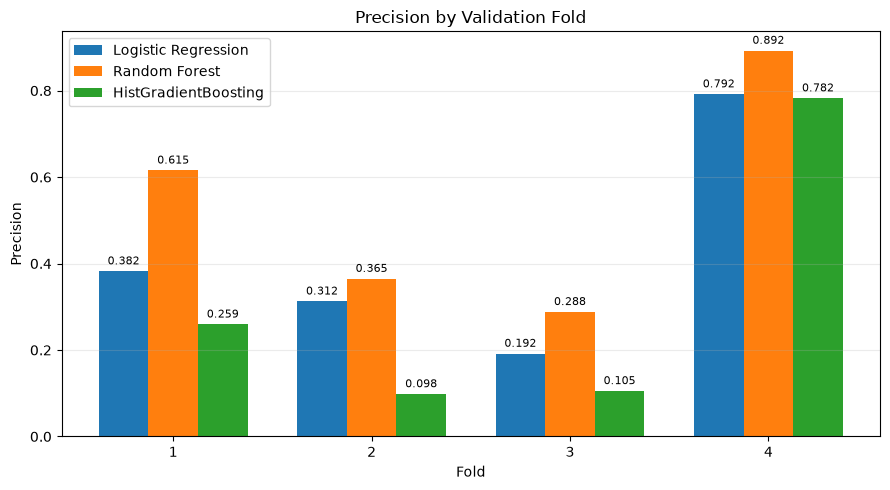

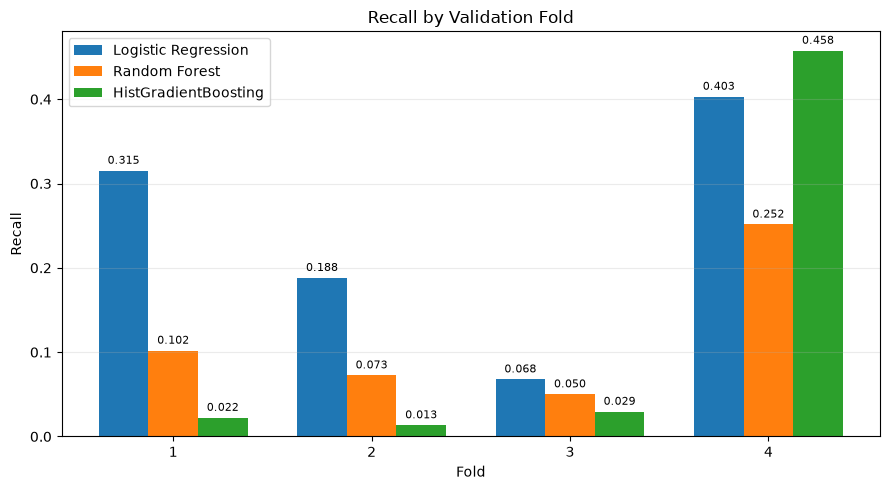

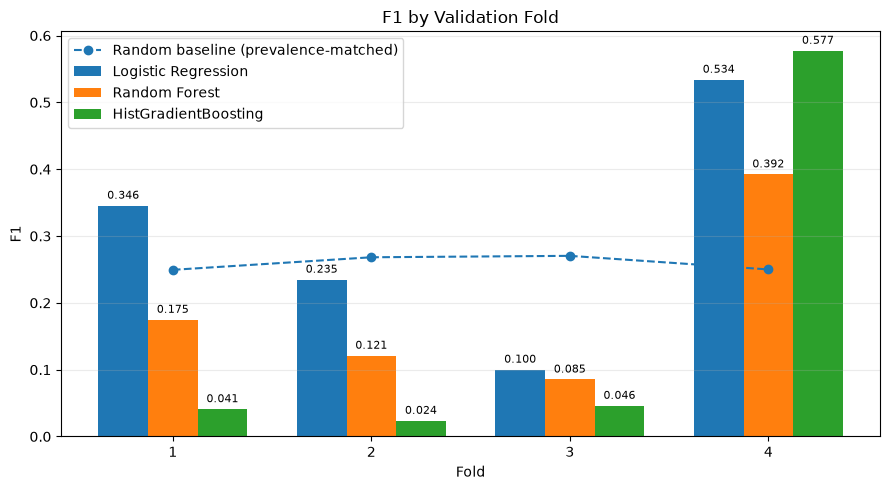

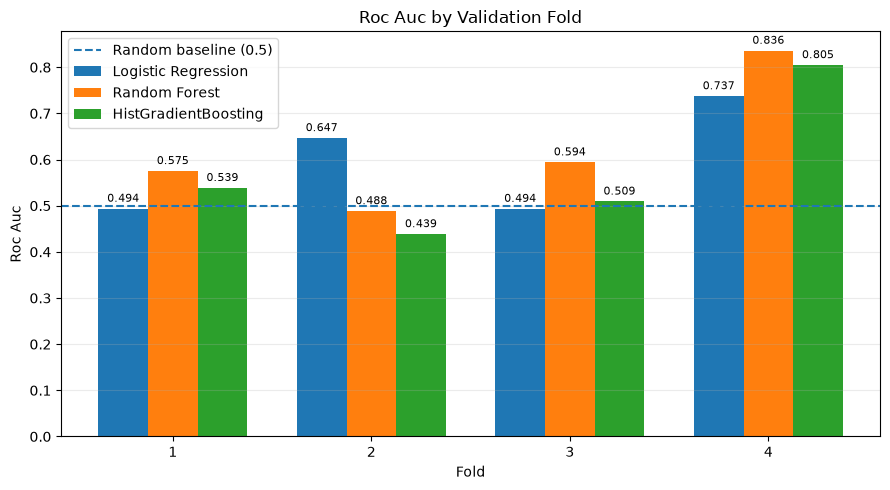

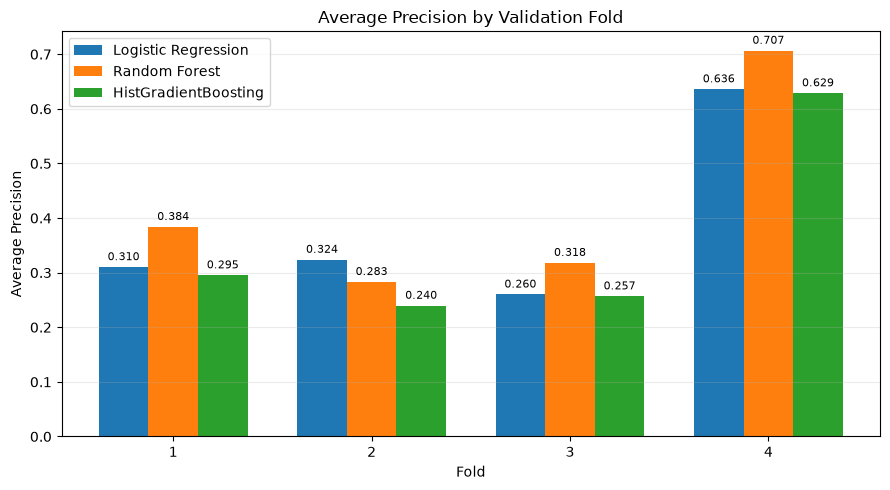

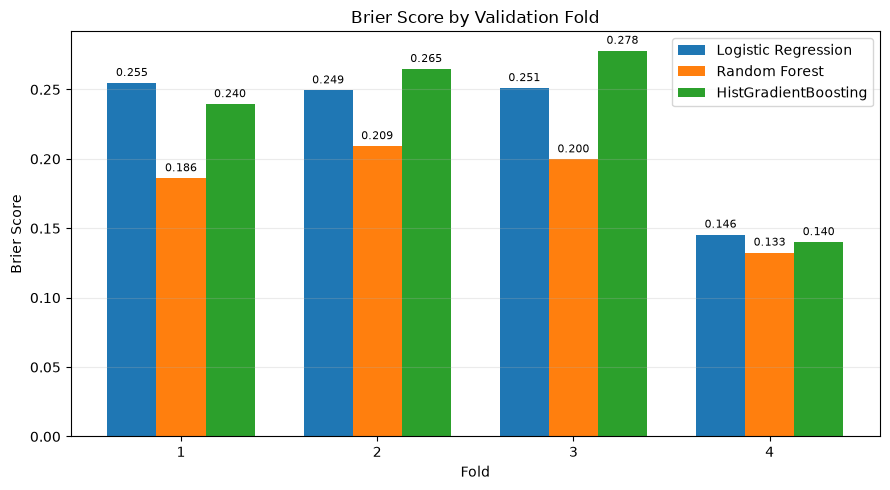

In [71]:
# Extract only the Logistic Regression rows from the original fold results.
logistic_fold_results = (
    fold_results[
        fold_results["model"]
        .eq("logistic_regression")
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)


# Define the metrics to compare across models.
metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision",
    "brier_score",
]


# Store the three fold-level result dataframes.
fold_model_results = {
    "Logistic Regression": logistic_fold_results,
    "Random Forest": rf_fold_results,
    "HistGradientBoosting": hgb_fold_results,
}


# Use the common fold numbers.
folds_plot = (
    logistic_fold_results["fold"]
    .to_numpy()
)

x = np.arange(
    len(folds_plot)
)

bar_width = 0.25


# Create one separate chart for each metric.
for metric in metrics:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    # Plot one bar for each model within every fold.
    for i, (
        model_name,
        result_df,
    ) in enumerate(
        fold_model_results.items()
    ):

        values = (
            result_df[metric]
            .to_numpy()
        )

        positions = (
            x
            + (i - 1) * bar_width
        )

        bars = ax.bar(
            positions,
            values,
            width=bar_width,
            label=model_name,
        )

        # Add metric values above the bars.
        ax.bar_label(
            bars,
            fmt="%.3f",
            padding=3,
            fontsize=8,
        )


    # Add the random-ranking reference for ROC-AUC.
    if metric == "roc_auc":

        ax.axhline(
            y=0.5,
            linestyle="--",
            linewidth=1.5,
            label="Random baseline (0.5)",
        )


    # Add prevalence-matched random F1 reference by fold.
    if metric == "f1":

        random_f1_baseline = (
            logistic_fold_results[
                "validation_positive_rate"
            ]
            .to_numpy()
        )

        ax.plot(
            x,
            random_f1_baseline,
            linestyle="--",
            marker="o",
            linewidth=1.5,
            label=(
                "Random baseline "
                "(prevalence-matched)"
            ),
        )


    # Format the chart.
    ax.set_xlabel(
        "Fold"
    )

    ax.set_ylabel(
        metric.replace(
            "_",
            " ",
        ).title()
    )

    ax.set_title(
        (
            f"{metric.replace('_', ' ').title()} "
            "by Validation Fold"
        )
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        folds_plot
    )

    ax.set_ylim(
        bottom=0
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()

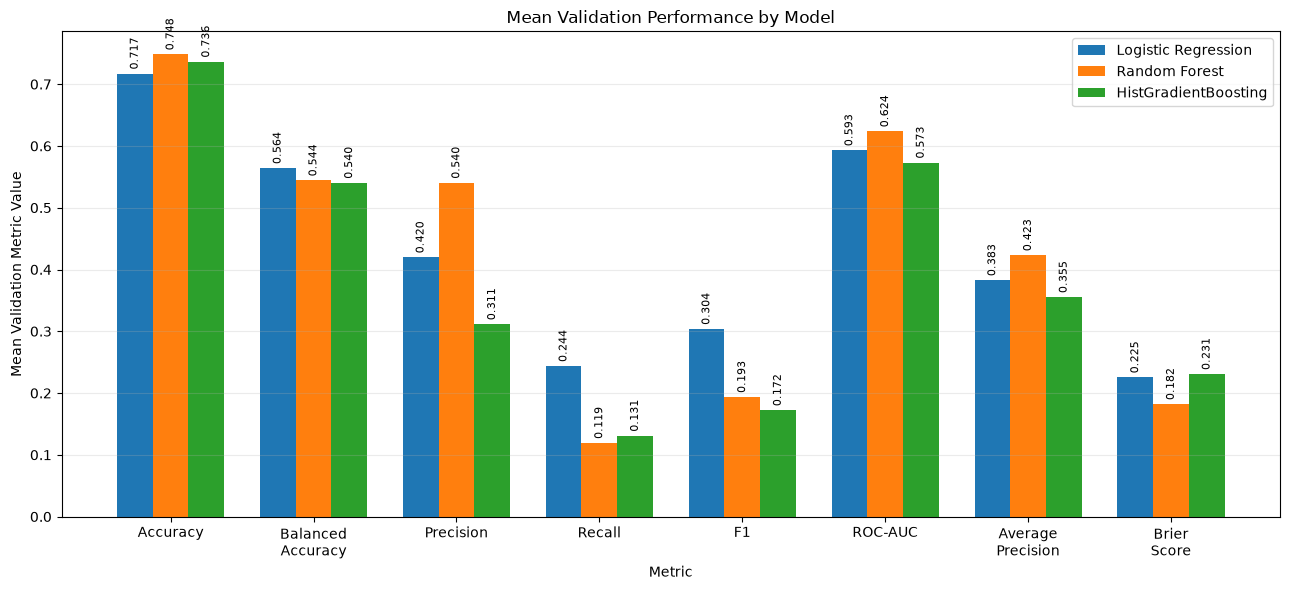

In [72]:
# Extract the mean Logistic Regression metrics from model_summary.
logistic_summary_for_plot = pd.Series(
    {
        metric:
            model_summary.loc[
                "logistic_regression",
                (metric, "mean"),
            ]
        for metric in metric_columns
    }
)


# Convert the RF summary names back to the original metric names.
rf_summary_for_plot = pd.Series(
    {
        "roc_auc":
            rf_summary["mean_roc_auc"],

        "average_precision":
            rf_summary[
                "mean_average_precision"
            ],

        "balanced_accuracy":
            rf_summary[
                "mean_balanced_accuracy"
            ],

        "precision":
            rf_summary["mean_precision"],

        "recall":
            rf_summary["mean_recall"],

        "f1":
            rf_summary["mean_f1"],

        "accuracy":
            rf_summary["mean_accuracy"],

        "brier_score":
            rf_summary[
                "mean_brier_score"
            ],
    }
)


# Convert the HGB summary names back to the original metric names.
hgb_summary_for_plot = pd.Series(
    {
        "roc_auc":
            hgb_summary["mean_roc_auc"],

        "average_precision":
            hgb_summary[
                "mean_average_precision"
            ],

        "balanced_accuracy":
            hgb_summary[
                "mean_balanced_accuracy"
            ],

        "precision":
            hgb_summary["mean_precision"],

        "recall":
            hgb_summary["mean_recall"],

        "f1":
            hgb_summary["mean_f1"],

        "accuracy":
            hgb_summary["mean_accuracy"],

        "brier_score":
            hgb_summary[
                "mean_brier_score"
            ],
    }
)


# Define the order of metrics shown in the chart.
summary_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision",
    "brier_score",
]


# Store the three comparable summary Series.
model_summaries = {
    "Logistic Regression":
        logistic_summary_for_plot,

    "Random Forest":
        rf_summary_for_plot,

    "HistGradientBoosting":
        hgb_summary_for_plot,
}


# Create readable x-axis labels.
summary_labels = [
    "Accuracy",
    "Balanced\nAccuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average\nPrecision",
    "Brier\nScore",
]


x = np.arange(
    len(summary_metrics)
)

bar_width = 0.25


# Create the grouped summary bar chart.
fig, ax = plt.subplots(
    figsize=(13, 6)
)


# Plot the mean metric values for each model.
for i, (
    model_name,
    summary,
) in enumerate(
    model_summaries.items()
):

    values = [
        summary[metric]
        for metric
        in summary_metrics
    ]

    positions = (
        x
        + (i - 1) * bar_width
    )

    bars = ax.bar(
        positions,
        values,
        width=bar_width,
        label=model_name,
    )

    # Add the mean value above each bar.
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
        fontsize=8,
        rotation=90,
    )


# Format the summary chart.
ax.set_xlabel(
    "Metric"
)

ax.set_ylabel(
    "Mean Validation Metric Value"
)

ax.set_title(
    "Mean Validation Performance by Model"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    summary_labels
)

ax.set_ylim(
    bottom=0
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

The untuned HistGradientBoosting baseline did not improve upon Random Forest or Logistic Regression overall. Its mean ROC-AUC was 0.573, below both Random Forest (0.624) and Logistic Regression (0.593), while its ROC-AUC standard deviation of 0.160 was the highest of the three models, indicating greater temporal variability. HGB underperformed Random Forest in every validation fold, with ROC-AUC close to or below random ranking in the first three folds before improving substantially to 0.805 in Fold 4. Threshold-dependent performance showed a similar pattern: mean recall was only 0.131 and mean F1 was 0.172, with extremely low recall and F1 across Folds 1–3 despite much stronger Fold 4 results. Mean precision was also substantially below Random Forest, while the Brier score of 0.231 and Average Precision of 0.355 indicated weaker probability quality and positive-class ranking overall. These results suggest that the baseline HGB specification is strongly regime-dependent and, in its current untuned form, does not provide an advantage over Random Forest.

In [73]:
# Calculate HGB performance separately for each validation quarter.
hgb_quarterly_results = []

for (
    fold_number,
    quarter
), quarter_data in (
    hgb_oof_predictions
    .groupby(
        [
            "fold",
            "period_end_date",
        ]
    )
):

    y_true = quarter_data[
        target_col
    ]

    y_probability = quarter_data[
        "predicted_probability"
    ]

    y_prediction = quarter_data[
        "prediction"
    ]

    hgb_quarterly_results.append(
        {
            "fold": fold_number,
            "period_end_date": quarter,
            "rows": len(
                quarter_data
            ),
            "positive_rate":
                y_true.mean(),

            "accuracy":
                accuracy_score(
                    y_true,
                    y_prediction,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_prediction,
                ),

            "precision":
                precision_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "recall":
                recall_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "f1":
                f1_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "roc_auc":
                roc_auc_score(
                    y_true,
                    y_probability,
                ),

            "average_precision":
                average_precision_score(
                    y_true,
                    y_probability,
                ),

            "brier_score":
                brier_score_loss(
                    y_true,
                    y_probability,
                ),
        }
    )


# Convert the HGB quarterly metrics into a sorted dataframe.
hgb_quarterly_results = (
    pd.DataFrame(
        hgb_quarterly_results
    )
    .sort_values(
        "period_end_date"
    )
    .reset_index(
        drop=True
    )
)

# Display the main HGB ranking, classification, and probability metrics.
hgb_quarterly_results[
    [
        "fold",
        "period_end_date",
        "positive_rate",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier_score",
    ]
]

,fold,period_end_date,positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,2019-06-30,0.240132,0.753289,0.495671,0.000000,0.000000,0.000000,0.482121,0.238079,0.239105
1,1,2019-09-30,0.246711,0.710526,0.471616,0.000000,0.000000,0.000000,0.374527,0.196740,0.276571
2,1,2019-12-31,0.242623,0.763934,0.536475,0.583333,0.094595,0.162791,0.603896,0.404378,0.211884
3,1,2020-03-31,0.265896,0.734104,0.500000,0.000000,0.000000,0.000000,0.652645,0.493237,0.231709
4,2,2020-06-30,0.265896,0.601156,0.409449,0.000000,0.000000,0.000000,0.133302,0.160730,0.339378
5,2,2020-09-30,0.263006,0.745665,0.516484,1.000000,0.032967,0.063830,0.722668,0.631083,0.210156
6,2,2020-12-31,0.265896,0.734104,0.500000,0.000000,0.000000,0.000000,0.168435,0.164427,0.264128
7,2,2021-03-31,0.277937,0.727794,0.510309,1.000000,0.020619,0.040404,0.700499,0.516642,0.245938
8,3,2021-06-30,0.252778,0.736111,0.492565,0.000000,0.000000,0.000000,0.424078,0.228896,0.245326
9,3,2021-09-30,0.330189,0.572327,0.432059,0.057143,0.019048,0.028571,0.462151,0.291339,0.361345


In [74]:
# Summarise HGB performance and temporal variability across all quarters.
hgb_quarterly_summary = pd.Series(
    {
        "mean_roc_auc":
            hgb_quarterly_results[
                "roc_auc"
            ].mean(),

        "std_roc_auc":
            hgb_quarterly_results[
                "roc_auc"
            ].std(),

        "min_roc_auc":
            hgb_quarterly_results[
                "roc_auc"
            ].min(),

        "max_roc_auc":
            hgb_quarterly_results[
                "roc_auc"
            ].max(),

        "mean_average_precision":
            hgb_quarterly_results[
                "average_precision"
            ].mean(),

        "mean_accuracy":
            hgb_quarterly_results[
                "accuracy"
            ].mean(),

        "mean_balanced_accuracy":
            hgb_quarterly_results[
                "balanced_accuracy"
            ].mean(),

        "mean_precision":
            hgb_quarterly_results[
                "precision"
            ].mean(),

        "mean_recall":
            hgb_quarterly_results[
                "recall"
            ].mean(),

        "mean_f1":
            hgb_quarterly_results[
                "f1"
            ].mean(),

        "mean_brier_score":
            hgb_quarterly_results[
                "brier_score"
            ].mean(),
    }
)

hgb_quarterly_summary

mean_roc_auc              0.566571
std_roc_auc               0.221721
min_roc_auc               0.133302
max_roc_auc               0.946979
mean_average_precision    0.408485
mean_accuracy             0.736802
mean_balanced_accuracy    0.541586
mean_precision            0.380033
mean_recall               0.134608
mean_f1                   0.174460
mean_brier_score          0.229909
dtype: float64

In [75]:
# Rank HGB quarters by ROC-AUC to identify weak historical regimes.
hgb_quarterly_results[
    [
        "fold",
        "period_end_date",
        "roc_auc",
        "average_precision",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "brier_score",
    ]
].sort_values(
    "roc_auc"
)

,fold,period_end_date,roc_auc,average_precision,balanced_accuracy,precision,recall,f1,brier_score
4,2,2020-06-30,0.133302,0.160730,0.409449,0.000000,0.000000,0.000000,0.339378
6,2,2020-12-31,0.168435,0.164427,0.500000,0.000000,0.000000,0.000000,0.264128
1,1,2019-09-30,0.374527,0.196740,0.471616,0.000000,0.000000,0.000000,0.276571
8,3,2021-06-30,0.424078,0.228896,0.492565,0.000000,0.000000,0.000000,0.245326
9,3,2021-09-30,0.462151,0.291339,0.432059,0.057143,0.019048,0.028571,0.361345
0,1,2019-06-30,0.482121,0.238079,0.495671,0.000000,0.000000,0.000000,0.239105
10,3,2021-12-31,0.543576,0.262588,0.471831,0.100000,0.028169,0.043956,0.247607
11,3,2022-03-31,0.558965,0.262607,0.473485,0.166667,0.083333,0.111111,0.257002
2,1,2019-12-31,0.603896,0.404378,0.536475,0.583333,0.094595,0.162791,0.211884
3,1,2020-03-31,0.652645,0.493237,0.500000,0.000000,0.000000,0.000000,0.231709


In [76]:
# Compare the actual positive rate with HGB's predicted positive rate.
hgb_quarterly_prediction_rates = (
    hgb_oof_predictions
    .groupby(
        [
            "fold",
            "period_end_date",
        ]
    )
    .agg(
        actual_positive_rate=(
            target_col,
            "mean",
        ),
        predicted_positive_rate=(
            "prediction",
            "mean",
        ),
        mean_predicted_probability=(
            "predicted_probability",
            "mean",
        ),
    )
    .reset_index()
)

hgb_quarterly_prediction_rates

,fold,period_end_date,actual_positive_rate,predicted_positive_rate,mean_predicted_probability
0,1,2019-06-30,0.240132,0.006579,0.028720
1,1,2019-09-30,0.246711,0.042763,0.067797
2,1,2019-12-31,0.242623,0.039344,0.057367
3,1,2020-03-31,0.265896,0.000000,0.041016
4,2,2020-06-30,0.265896,0.132948,0.195236
5,2,2020-09-30,0.263006,0.008671,0.044445
6,2,2020-12-31,0.265896,0.000000,0.017635
7,2,2021-03-31,0.277937,0.005731,0.035629
8,3,2021-06-30,0.252778,0.011111,0.062619
9,3,2021-09-30,0.330189,0.110063,0.167671


In [77]:
# Combine HGB quarterly metrics with positive-rate diagnostics.
hgb_quarterly_diagnostics = (
    hgb_quarterly_results
    .merge(
        hgb_quarterly_prediction_rates,
        on=[
            "fold",
            "period_end_date",
        ],
        how="left",
    )
)

hgb_quarterly_diagnostics[
    [
        "fold",
        "period_end_date",
        "roc_auc",
        "average_precision",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "actual_positive_rate",
        "predicted_positive_rate",
        "mean_predicted_probability",
        "recall",
        "f1",
        "brier_score",
    ]
]

,fold,period_end_date,roc_auc,average_precision,accuracy,balanced_accuracy,precision,actual_positive_rate,predicted_positive_rate,mean_predicted_probability,recall,f1,brier_score
0,1,2019-06-30,0.482121,0.238079,0.753289,0.495671,0.000000,0.240132,0.006579,0.028720,0.000000,0.000000,0.239105
1,1,2019-09-30,0.374527,0.196740,0.710526,0.471616,0.000000,0.246711,0.042763,0.067797,0.000000,0.000000,0.276571
2,1,2019-12-31,0.603896,0.404378,0.763934,0.536475,0.583333,0.242623,0.039344,0.057367,0.094595,0.162791,0.211884
3,1,2020-03-31,0.652645,0.493237,0.734104,0.500000,0.000000,0.265896,0.000000,0.041016,0.000000,0.000000,0.231709
4,2,2020-06-30,0.133302,0.160730,0.601156,0.409449,0.000000,0.265896,0.132948,0.195236,0.000000,0.000000,0.339378
5,2,2020-09-30,0.722668,0.631083,0.745665,0.516484,1.000000,0.263006,0.008671,0.044445,0.032967,0.063830,0.210156
6,2,2020-12-31,0.168435,0.164427,0.734104,0.500000,0.000000,0.265896,0.000000,0.017635,0.000000,0.000000,0.264128
7,2,2021-03-31,0.700499,0.516642,0.727794,0.510309,1.000000,0.277937,0.005731,0.035629,0.020619,0.040404,0.245938
8,3,2021-06-30,0.424078,0.228896,0.736111,0.492565,0.000000,0.252778,0.011111,0.062619,0.000000,0.000000,0.245326
9,3,2021-09-30,0.462151,0.291339,0.572327,0.432059,0.057143,0.330189,0.110063,0.167671,0.019048,0.028571,0.361345


In [78]:
# Define the quarterly metrics to compare across all three models.
quarterly_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision",
    "brier_score",
]


# Prepare Logistic Regression quarterly results.
logistic_quarterly_comparison = (
    quarterly_oof_metrics[
        [
            "period_end_date",
            *quarterly_metrics,
        ]
    ]
    .copy()
)

logistic_quarterly_comparison[
    "model"
] = "Logistic Regression"


# Prepare Random Forest quarterly results.
rf_quarterly_comparison = (
    rf_quarterly_results[
        [
            "period_end_date",
            *quarterly_metrics,
        ]
    ]
    .copy()
)

rf_quarterly_comparison[
    "model"
] = "Random Forest"


# Prepare HistGradientBoosting quarterly results.
hgb_quarterly_comparison = (
    hgb_quarterly_results[
        [
            "period_end_date",
            *quarterly_metrics,
        ]
    ]
    .copy()
)

hgb_quarterly_comparison[
    "model"
] = "HistGradientBoosting"


# Stack all models into one quarter-level comparison dataframe.
quarterly_model_comparison = (
    pd.concat(
        [
            logistic_quarterly_comparison,
            rf_quarterly_comparison,
            hgb_quarterly_comparison,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "period_end_date",
            "model",
        ]
    )
    .reset_index(
        drop=True
    )
)

quarterly_model_comparison

,period_end_date,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model
0,2019-06-30,0.753289,0.495671,0.000000,0.000000,0.000000,0.482121,0.238079,0.239105,HistGradientBoosting
1,2019-06-30,0.723684,0.499615,0.238095,0.068493,0.106383,0.356995,0.195341,0.246989,Logistic Regression
2,2019-06-30,0.746711,0.491342,0.000000,0.000000,0.000000,0.505989,0.229813,0.201827,Random Forest
3,2019-09-30,0.710526,0.471616,0.000000,0.000000,0.000000,0.374527,0.196740,0.276571,HistGradientBoosting
4,2019-09-30,0.687500,0.456332,0.000000,0.000000,0.000000,0.304221,0.176724,0.269620,Logistic Regression
5,2019-09-30,0.713816,0.473799,0.000000,0.000000,0.000000,0.406783,0.209623,0.227555,Random Forest
6,2019-12-31,0.763934,0.536475,0.583333,0.094595,0.162791,0.603896,0.404378,0.211884,HistGradientBoosting
7,2019-12-31,0.760656,0.571048,0.517241,0.202703,0.291262,0.490055,0.347272,0.212187,Logistic Regression
8,2019-12-31,0.783607,0.572423,0.750000,0.162162,0.266667,0.507342,0.399414,0.185122,Random Forest
9,2020-03-31,0.734104,0.500000,0.000000,0.000000,0.000000,0.652645,0.493237,0.231709,HistGradientBoosting


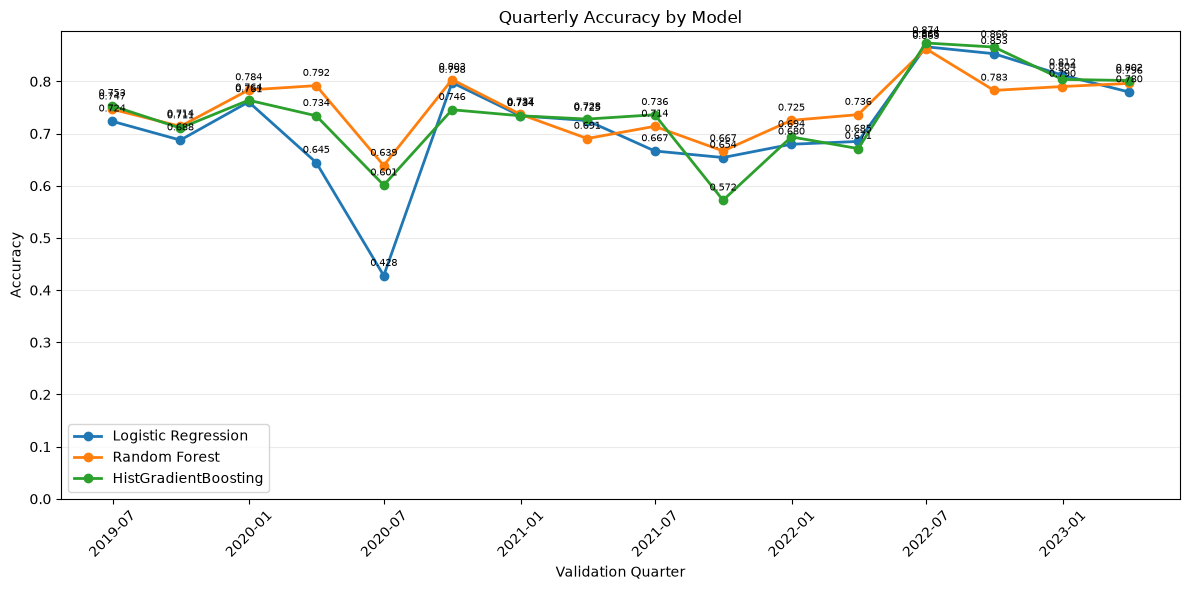

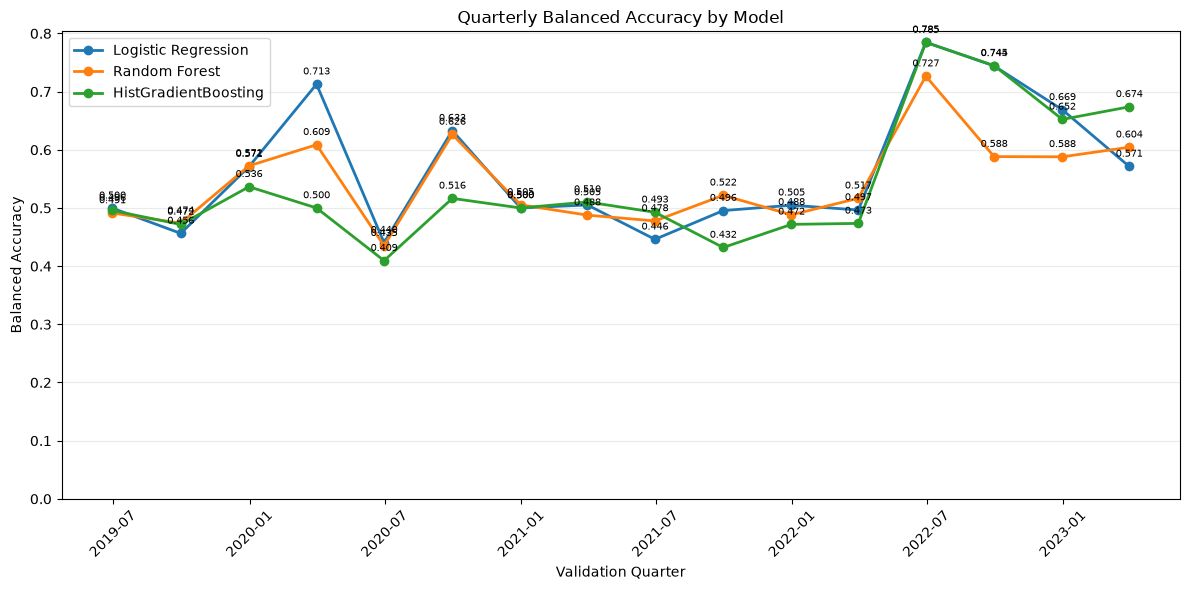

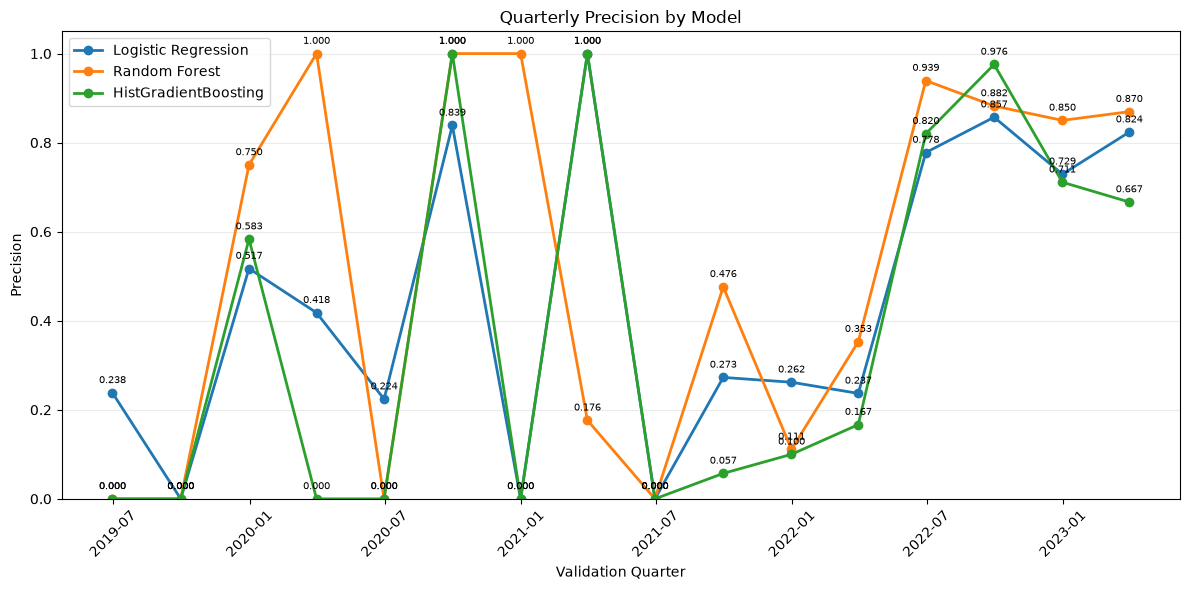

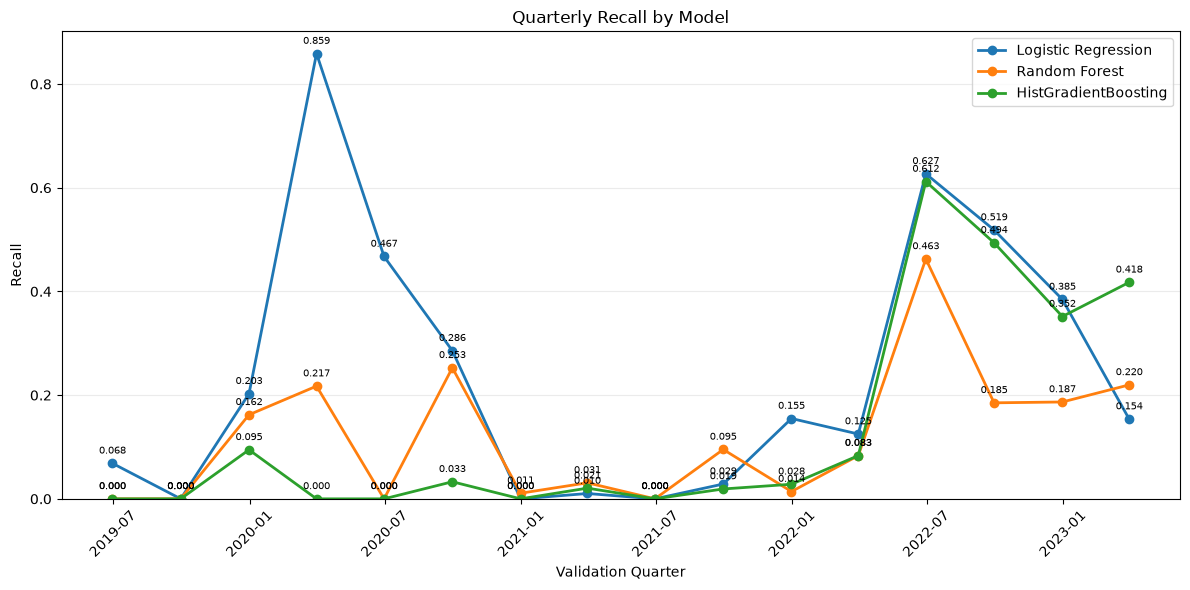

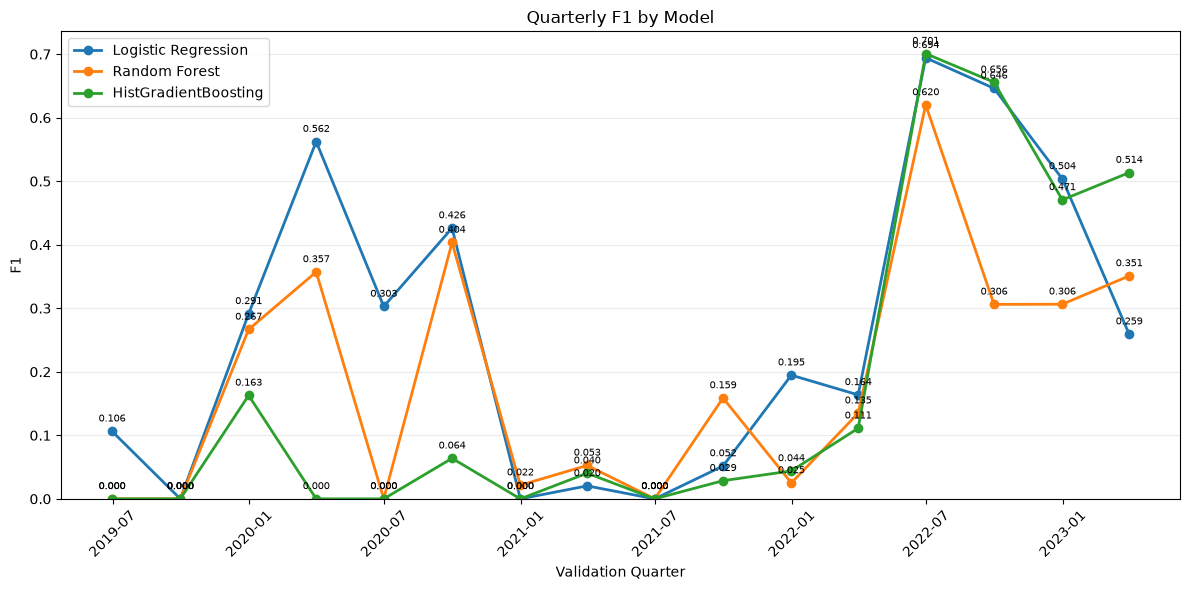

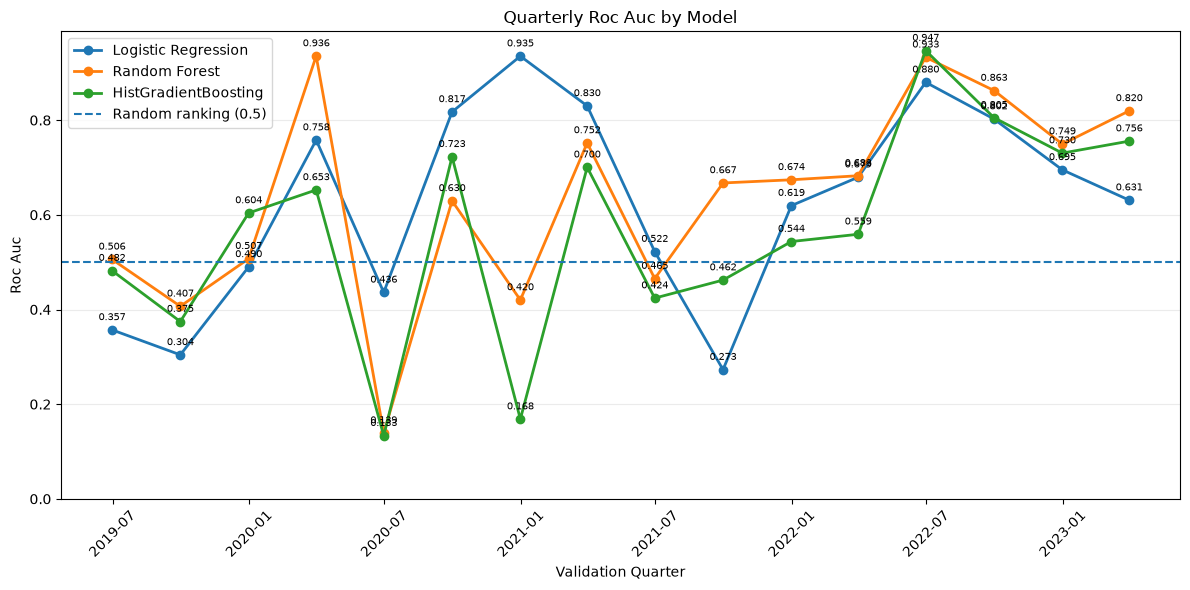

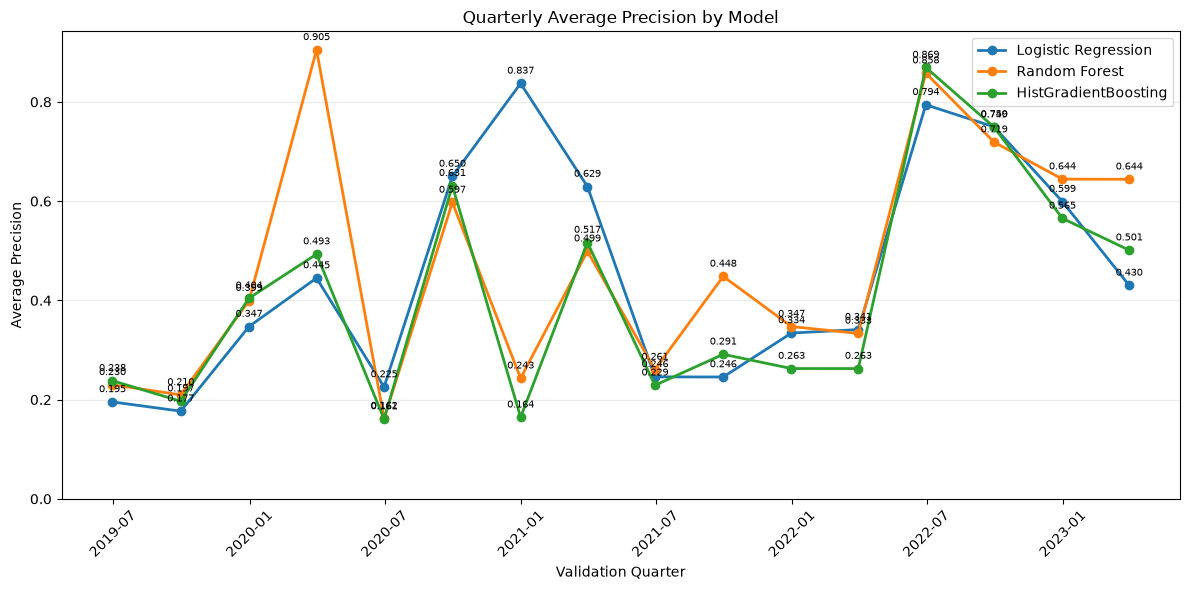

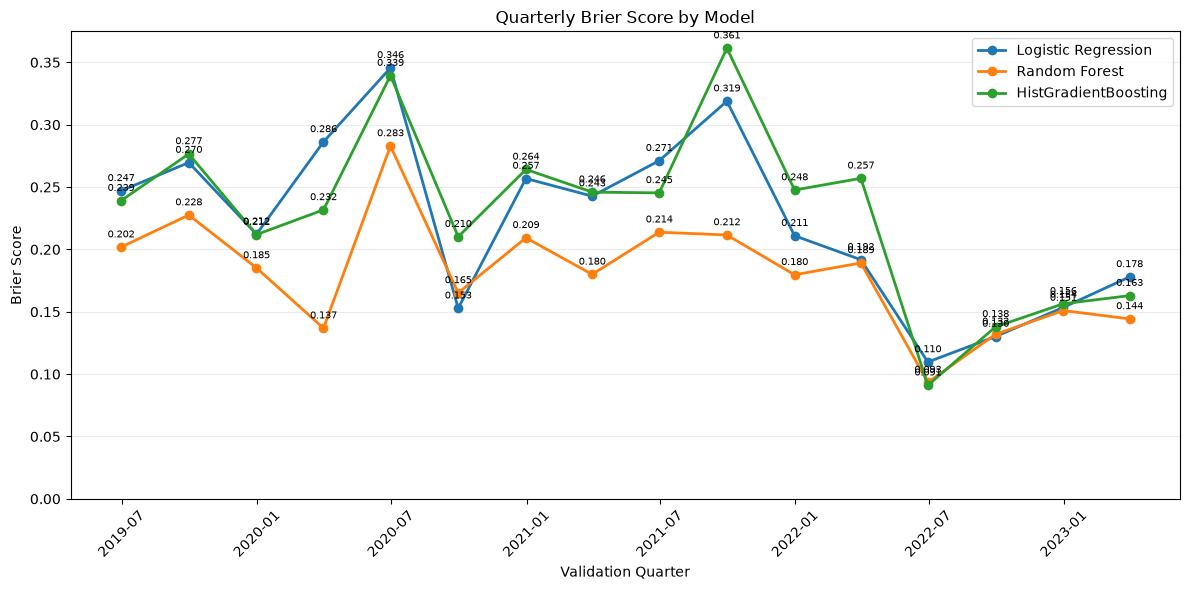

In [79]:
# Define the quarterly metrics to visualise.
metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision",
    "brier_score",
]


# Ensure quarters are ordered chronologically.
quarterly_model_comparison = (
    quarterly_model_comparison
    .sort_values(
        [
            "period_end_date",
            "model",
        ]
    )
    .copy()
)


# Define the model order used in every chart.
model_order = [
    "Logistic Regression",
    "Random Forest",
    "HistGradientBoosting",
]


# Create one separate line chart for each metric.
for metric in metrics:

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    # Plot quarterly performance for each model.
    for model_name in model_order:

        model_data_plot = (
            quarterly_model_comparison[
                quarterly_model_comparison[
                    "model"
                ].eq(model_name)
            ]
            .sort_values(
                "period_end_date"
            )
        )

        ax.plot(
            model_data_plot[
                "period_end_date"
            ],
            model_data_plot[
                metric
            ],
            marker="o",
            linewidth=2,
            label=model_name,
        )

        # Add metric values beside each quarterly point.
        for x, y in zip(
            model_data_plot[
                "period_end_date"
            ],
            model_data_plot[
                metric
            ],
        ):

            ax.annotate(
                f"{y:.3f}",
                (x, y),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                fontsize=7,
            )


    # Add the random-ranking reference line for ROC-AUC.
    if metric == "roc_auc":

        ax.axhline(
            y=0.5,
            linestyle="--",
            linewidth=1.5,
            label="Random ranking (0.5)",
        )


    # Format the chart.
    ax.set_xlabel(
        "Validation Quarter"
    )

    ax.set_ylabel(
        metric.replace(
            "_",
            " ",
        ).title()
    )

    ax.set_title(
        (
            f"Quarterly "
            f"{metric.replace('_', ' ').title()} "
            "by Model"
        )
    )

    ax.set_ylim(
        bottom=0
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.show()

Quarter-level comparison shows that Random Forest provides the strongest overall ranking and probability performance, achieving the highest mean ROC-AUC and Average Precision and the lowest Brier score, while Logistic Regression retains the strongest positive-case detection at the default 0.5 threshold through substantially higher recall, F1, and balanced accuracy. HistGradientBoosting does not improve overall baseline performance and exhibits pronounced temporal regime dependence, performing weakly across many earlier quarters but becoming highly competitive in the 2022–2023 validation period. No model therefore dominates across all evaluation dimensions. Random Forest currently appears strongest for ranking and probability quality, Logistic Regression for detecting actual future underperformers at the baseline threshold, and HGB provides evidence that boosting can perform very strongly in particular recent regimes but lacks temporal robustness.

One particularly interesting result is that the difficult regimes differ by model. Logistic Regression struggles badly around 2019 Q2–Q3 and 2021 Q3. Random Forest improves substantially in 2021 Q3 but collapses in 2020 Q2. HGB also collapses around 2020 Q2 and performs poorly through much of the early history. This suggests that the instability is not simply caused by one universally difficult quarter. Different model families are learning different relationships that break under different market regimes.

For now, continue with Random Forest for limited hyperparameter tuning because it currently provides the strongest overall ranking and probability performance. Retain Logistic Regression as the reference model because its superior recall, F1, and balanced accuracy at the baseline threshold remain relevant to the early-warning objective.

### Hyper parameter tuning

For now, tune 4 parameters:
- max_depth: controls tree complexity.
- min_samples_leaf: regularises small leaves and may improve temporal generalisation.
- max_features: controls how many features each split considers.
- class_weight: worth testing because RF currently has very low recall.

Probability threshold will be tuned later.

In [143]:
from sklearn.model_selection import ParameterGrid


# Define a deliberately small Random Forest hyperparameter grid.
rf_param_grid = {
    "n_estimators": [
        300,
        500,
        800,
    ],

    "max_depth": [
        6,
        8,
        10,
        12,
    ],

    "min_samples_leaf": [
        5,
        10,
        15,
        20,
    ],

    "max_features": [
        "sqrt",
    ],

    "class_weight": [
        "balanced",
    ],
}


# Expand the grid into individual candidate configurations.
rf_param_candidates = list(
    ParameterGrid(
        rf_param_grid
    )
)

len(rf_param_candidates)

48

In [144]:
# Store fold-level results and candidate configurations.
rf_tuning_fold_results = []
rf_candidate_parameters = []


# Evaluate every hyperparameter candidate.
for candidate_id, params in enumerate(
    rf_param_candidates,
    start=1,
):

    rf_candidate_parameters.append(
        {
            "candidate_id":
                candidate_id,
            **params,
        }
    )

    # Evaluate the candidate on the same four temporal folds.
    for fold_info in rf_fold_windows:

        fold_number = fold_info[
            "fold"
        ]

        validation_start = fold_info[
            "validation_start"
        ]

        validation_end = fold_info[
            "validation_end"
        ]


        # Keep only mature training targets available before validation.
        train_mask = (
            model_data[
                "period_end_date"
            ].lt(
                validation_start
            )
            &
            model_data[
                "target_end_date"
            ].lt(
                validation_start
            )
        )


        # Select the current validation block.
        validation_mask = (
            model_data[
                "period_end_date"
            ].between(
                validation_start,
                validation_end,
            )
        )


        train_data = (
            model_data[
                train_mask
            ]
            .copy()
        )

        validation_data = (
            model_data[
                validation_mask
            ]
            .copy()
        )


        # Use the same all_baseline features.
        X_train = train_data[
            baseline_features
        ]

        y_train = train_data[
            target_col
        ]

        X_validation = (
            validation_data[
                baseline_features
            ]
        )

        y_validation = (
            validation_data[
                target_col
            ]
        )


        # Train a fresh Random Forest using this candidate configuration.
        candidate_model = (
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                **params,
            )
        )

        candidate_model.fit(
            X_train,
            y_train,
        )


        # Generate validation probabilities.
        validation_probability = (
            candidate_model
            .predict_proba(
                X_validation
            )[:, 1]
        )


        # Keep the baseline 0.5 threshold during model tuning.
        validation_prediction = (
            validation_probability
            >= BASELINE_THRESHOLD
        ).astype(int)


        # Store all major evaluation metrics for this fold.
        rf_tuning_fold_results.append(
            {
                "candidate_id":
                    candidate_id,

                "fold":
                    fold_number,

                "validation_start":
                    validation_start,

                "validation_end":
                    validation_end,

                "train_rows":
                    len(
                        train_data
                    ),

                "validation_rows":
                    len(
                        validation_data
                    ),

                "accuracy":
                    accuracy_score(
                        y_validation,
                        validation_prediction,
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_validation,
                        validation_prediction,
                    ),

                "precision":
                    precision_score(
                        y_validation,
                        validation_prediction,
                        zero_division=0,
                    ),

                "recall":
                    recall_score(
                        y_validation,
                        validation_prediction,
                        zero_division=0,
                    ),

                "f1":
                    f1_score(
                        y_validation,
                        validation_prediction,
                        zero_division=0,
                    ),

                "roc_auc":
                    roc_auc_score(
                        y_validation,
                        validation_probability,
                    ),

                "average_precision":
                    average_precision_score(
                        y_validation,
                        validation_probability,
                    ),

                "brier_score":
                    brier_score_loss(
                        y_validation,
                        validation_probability,
                    ),
            }
        )

# Convert candidate configurations and fold results into dataframes.
rf_candidate_parameters = (
    pd.DataFrame(
        rf_candidate_parameters
    )
)

rf_tuning_fold_results = (
    pd.DataFrame(
        rf_tuning_fold_results
    )
)

In [145]:
# Check the candidate configurations.
rf_candidate_parameters.head()

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators
0,1,balanced,6,sqrt,5,300
1,2,balanced,6,sqrt,5,500
2,3,balanced,6,sqrt,5,800
3,4,balanced,6,sqrt,10,300
4,5,balanced,6,sqrt,10,500


In [146]:
# Check the fold-level tuning results.
rf_tuning_fold_results.head()

,candidate_id,fold,validation_start,validation_end,train_rows,validation_rows,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,1,2019-06-30,2020-03-31,2722,1259,0.755361,0.573350,0.523810,0.210191,0.300000,0.520480,0.395394,0.194109
1,1,2,2020-06-30,2021-03-31,3783,1387,0.685652,0.509344,0.300000,0.129032,0.180451,0.575981,0.320842,0.205804
2,1,3,2021-06-30,2022-03-31,5042,1254,0.669856,0.474801,0.155963,0.050147,0.075893,0.578869,0.291546,0.215096
3,1,4,2022-06-30,2023-03-31,6429,1320,0.816667,0.726263,0.661765,0.545455,0.598007,0.833454,0.678924,0.142885
4,2,1,2019-06-30,2020-03-31,2722,1259,0.764893,0.577572,0.581818,0.203822,0.301887,0.523715,0.384383,0.194866


In [147]:
rf_tuning_fold_results.shape

(192, 14)

In [148]:
# Summarise ranking, classification, calibration, and stability by candidate.
rf_tuning_summary = (
    rf_tuning_fold_results
    .groupby(
        "candidate_id"
    )
    .agg(
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        std_roc_auc=(
            "roc_auc",
            "std",
        ),
        min_roc_auc=(
            "roc_auc",
            "min",
        ),

        mean_average_precision=(
            "average_precision",
            "mean",
        ),

        mean_accuracy=(
            "accuracy",
            "mean",
        ),
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        mean_precision=(
            "precision",
            "mean",
        ),
        mean_recall=(
            "recall",
            "mean",
        ),
        mean_f1=(
            "f1",
            "mean",
        ),

        mean_brier_score=(
            "brier_score",
            "mean",
        ),
    )
    .reset_index()
)

# Add each candidate's hyperparameters to its performance summary.
rf_tuning_summary = (
    rf_candidate_parameters
    .merge(
        rf_tuning_summary,
        on="candidate_id",
        how="left",
    )
)

In [149]:
# Rank candidates primarily by mean ROC-AUC for initial inspection.
rf_tuning_ranked = (
    rf_tuning_summary
    .sort_values(
        [
            "mean_roc_auc",
            "std_roc_auc",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)

rf_tuning_ranked.head(
    10
)

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_brier_score
0,11,balanced,6,sqrt,20,500,0.632066,0.140808,0.521491,0.423856,0.733703,0.581836,0.434622,0.263627,0.315151,0.189612
1,3,balanced,6,sqrt,5,800,0.630530,0.137755,0.523806,0.417999,0.733807,0.573268,0.423137,0.236877,0.290439,0.189387
2,4,balanced,6,sqrt,10,300,0.630283,0.134893,0.521307,0.416750,0.722263,0.562965,0.399911,0.229692,0.285853,0.190186
3,5,balanced,6,sqrt,10,500,0.629569,0.141590,0.517285,0.417028,0.732724,0.576146,0.421882,0.248025,0.301912,0.189747
4,16,balanced,8,sqrt,10,300,0.629447,0.135406,0.524302,0.424600,0.731947,0.567772,0.416347,0.223969,0.282486,0.186638
5,12,balanced,6,sqrt,20,800,0.629220,0.139596,0.517454,0.418831,0.730192,0.579057,0.429814,0.262407,0.312204,0.190740
6,10,balanced,6,sqrt,20,300,0.628910,0.137097,0.521060,0.417585,0.731269,0.576086,0.422756,0.250892,0.301820,0.190815
7,2,balanced,6,sqrt,5,500,0.628709,0.140523,0.523715,0.418939,0.732851,0.572366,0.420206,0.236138,0.290658,0.189717
8,6,balanced,6,sqrt,10,800,0.628515,0.142756,0.511896,0.416111,0.732959,0.576505,0.425779,0.248697,0.303141,0.190091
9,8,balanced,6,sqrt,15,500,0.628111,0.144956,0.515347,0.422202,0.740344,0.585243,0.449547,0.260134,0.316551,0.190097


In [150]:
# Compare each candidate against the untuned Random Forest baseline.
rf_tuning_ranked[
    "roc_auc_change"
] = (
    rf_tuning_ranked[
        "mean_roc_auc"
    ]
    -
    rf_summary[
        "mean_roc_auc"
    ]
)

rf_tuning_ranked[
    "average_precision_change"
] = (
    rf_tuning_ranked[
        "mean_average_precision"
    ]
    -
    rf_summary[
        "mean_average_precision"
    ]
)

rf_tuning_ranked[
    "recall_change"
] = (
    rf_tuning_ranked[
        "mean_recall"
    ]
    -
    rf_summary[
        "mean_recall"
    ]
)

rf_tuning_ranked[
    "f1_change"
] = (
    rf_tuning_ranked[
        "mean_f1"
    ]
    -
    rf_summary[
        "mean_f1"
    ]
)

rf_tuning_ranked[
    "brier_change"
] = (
    rf_tuning_ranked[
        "mean_brier_score"
    ]
    -
    rf_summary[
        "mean_brier_score"
    ]
)

# Inspect the strongest candidates against the untuned baseline.
rf_tuning_ranked[
    [
        "candidate_id",
        "max_depth",
        "min_samples_leaf",
        "max_features",
        "class_weight",

        "mean_roc_auc",
        "std_roc_auc",
        "min_roc_auc",
        "roc_auc_change",

        "mean_average_precision",
        "average_precision_change",

        "mean_balanced_accuracy",
        "mean_precision",
        "mean_recall",
        "recall_change",
        "mean_f1",
        "f1_change",

        "mean_brier_score",
        "brier_change",
    ]
].head(
    10
)

,candidate_id,max_depth,min_samples_leaf,max_features,class_weight,mean_roc_auc,std_roc_auc,min_roc_auc,roc_auc_change,mean_average_precision,average_precision_change,mean_balanced_accuracy,mean_precision,mean_recall,recall_change,mean_f1,f1_change,mean_brier_score,brier_change
0,11,6,20,sqrt,balanced,0.632066,0.140808,0.521491,0.008538,0.423856,0.000933,0.581836,0.434622,0.263627,0.144588,0.315151,0.121701,0.189612,0.007683
1,3,6,5,sqrt,balanced,0.630530,0.137755,0.523806,0.007002,0.417999,-0.004924,0.573268,0.423137,0.236877,0.117839,0.290439,0.096988,0.189387,0.007458
2,4,6,10,sqrt,balanced,0.630283,0.134893,0.521307,0.006755,0.416750,-0.006173,0.562965,0.399911,0.229692,0.110654,0.285853,0.092403,0.190186,0.008257
3,5,6,10,sqrt,balanced,0.629569,0.141590,0.517285,0.006041,0.417028,-0.005895,0.576146,0.421882,0.248025,0.128986,0.301912,0.108461,0.189747,0.007818
4,16,8,10,sqrt,balanced,0.629447,0.135406,0.524302,0.005920,0.424600,0.001676,0.567772,0.416347,0.223969,0.104930,0.282486,0.089035,0.186638,0.004709
5,12,6,20,sqrt,balanced,0.629220,0.139596,0.517454,0.005692,0.418831,-0.004093,0.579057,0.429814,0.262407,0.143368,0.312204,0.118753,0.190740,0.008811
6,10,6,20,sqrt,balanced,0.628910,0.137097,0.521060,0.005382,0.417585,-0.005339,0.576086,0.422756,0.250892,0.131854,0.301820,0.108369,0.190815,0.008885
7,2,6,5,sqrt,balanced,0.628709,0.140523,0.523715,0.005181,0.418939,-0.003984,0.572366,0.420206,0.236138,0.117100,0.290658,0.097207,0.189717,0.007788
8,6,6,10,sqrt,balanced,0.628515,0.142756,0.511896,0.004987,0.416111,-0.006812,0.576505,0.425779,0.248697,0.129658,0.303141,0.109690,0.190091,0.008161
9,8,6,15,sqrt,balanced,0.628111,0.144956,0.515347,0.004583,0.422202,-0.000721,0.585243,0.449547,0.260134,0.141095,0.316551,0.123101,0.190097,0.008168


In [151]:
# Show candidates with the strongest average ROC-AUC.
rf_tuning_summary.nlargest(
    10,
    "mean_roc_auc",
)

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_brier_score
10,11,balanced,6,sqrt,20,500,0.632066,0.140808,0.521491,0.423856,0.733703,0.581836,0.434622,0.263627,0.315151,0.189612
2,3,balanced,6,sqrt,5,800,0.630530,0.137755,0.523806,0.417999,0.733807,0.573268,0.423137,0.236877,0.290439,0.189387
3,4,balanced,6,sqrt,10,300,0.630283,0.134893,0.521307,0.416750,0.722263,0.562965,0.399911,0.229692,0.285853,0.190186
4,5,balanced,6,sqrt,10,500,0.629569,0.141590,0.517285,0.417028,0.732724,0.576146,0.421882,0.248025,0.301912,0.189747
15,16,balanced,8,sqrt,10,300,0.629447,0.135406,0.524302,0.424600,0.731947,0.567772,0.416347,0.223969,0.282486,0.186638
11,12,balanced,6,sqrt,20,800,0.629220,0.139596,0.517454,0.418831,0.730192,0.579057,0.429814,0.262407,0.312204,0.190740
9,10,balanced,6,sqrt,20,300,0.628910,0.137097,0.521060,0.417585,0.731269,0.576086,0.422756,0.250892,0.301820,0.190815
1,2,balanced,6,sqrt,5,500,0.628709,0.140523,0.523715,0.418939,0.732851,0.572366,0.420206,0.236138,0.290658,0.189717
5,6,balanced,6,sqrt,10,800,0.628515,0.142756,0.511896,0.416111,0.732959,0.576505,0.425779,0.248697,0.303141,0.190091
7,8,balanced,6,sqrt,15,500,0.628111,0.144956,0.515347,0.422202,0.740344,0.585243,0.449547,0.260134,0.316551,0.190097


In [152]:
# Show candidates with the strongest positive-class ranking.
rf_tuning_summary.nlargest(
    10,
    "mean_average_precision",
)

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_brier_score
46,47,balanced,12,sqrt,20,500,0.628021,0.139308,0.519038,0.431225,0.736327,0.574326,0.436550,0.234998,0.293289,0.186061
23,24,balanced,8,sqrt,20,800,0.624890,0.140973,0.517363,0.426800,0.738611,0.581913,0.452616,0.253719,0.312046,0.187444
22,23,balanced,8,sqrt,20,500,0.624682,0.141565,0.519068,0.425573,0.736051,0.579078,0.437483,0.250049,0.303132,0.187427
15,16,balanced,8,sqrt,10,300,0.629447,0.135406,0.524302,0.424600,0.731947,0.567772,0.416347,0.223969,0.282486,0.186638
10,11,balanced,6,sqrt,20,500,0.632066,0.140808,0.521491,0.423856,0.733703,0.581836,0.434622,0.263627,0.315151,0.189612
34,35,balanced,10,sqrt,20,500,0.617070,0.142679,0.518299,0.423480,0.736737,0.578942,0.448573,0.248475,0.306474,0.187699
47,48,balanced,12,sqrt,20,800,0.621217,0.140064,0.517299,0.423030,0.736530,0.577610,0.441678,0.244729,0.301603,0.187216
7,8,balanced,6,sqrt,15,500,0.628111,0.144956,0.515347,0.422202,0.740344,0.585243,0.449547,0.260134,0.316551,0.190097
0,1,balanced,6,sqrt,5,300,0.627196,0.140106,0.520480,0.421676,0.731884,0.570939,0.410384,0.233706,0.288588,0.189473
42,43,balanced,12,sqrt,15,300,0.617844,0.147116,0.524972,0.420730,0.730194,0.564282,0.408669,0.217013,0.277472,0.187180


In [153]:
# Show candidates with the strongest recall at threshold 0.5.
rf_tuning_summary.nlargest(
    10,
    "mean_recall",
)

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_brier_score
10,11,balanced,6,sqrt,20,500,0.632066,0.140808,0.521491,0.423856,0.733703,0.581836,0.434622,0.263627,0.315151,0.189612
11,12,balanced,6,sqrt,20,800,0.629220,0.139596,0.517454,0.418831,0.730192,0.579057,0.429814,0.262407,0.312204,0.190740
7,8,balanced,6,sqrt,15,500,0.628111,0.144956,0.515347,0.422202,0.740344,0.585243,0.449547,0.260134,0.316551,0.190097
6,7,balanced,6,sqrt,15,300,0.624971,0.146042,0.510902,0.416947,0.731857,0.578382,0.417837,0.256775,0.309942,0.191393
8,9,balanced,6,sqrt,15,800,0.624608,0.143827,0.512051,0.418607,0.736939,0.580881,0.444843,0.253996,0.310346,0.191083
23,24,balanced,8,sqrt,20,800,0.624890,0.140973,0.517363,0.426800,0.738611,0.581913,0.452616,0.253719,0.312046,0.187444
9,10,balanced,6,sqrt,20,300,0.628910,0.137097,0.521060,0.417585,0.731269,0.576086,0.422756,0.250892,0.301820,0.190815
22,23,balanced,8,sqrt,20,500,0.624682,0.141565,0.519068,0.425573,0.736051,0.579078,0.437483,0.250049,0.303132,0.187427
35,36,balanced,10,sqrt,20,800,0.613220,0.142379,0.520011,0.417643,0.736508,0.579259,0.449545,0.249970,0.308237,0.188660
20,21,balanced,8,sqrt,15,800,0.616716,0.146952,0.513359,0.415251,0.733526,0.577186,0.430072,0.249643,0.302514,0.188699


In [154]:
# Show candidates with the strongest F1 at threshold 0.5.
rf_tuning_summary.nlargest(
    10,
    "mean_f1",
)

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_brier_score
7,8,balanced,6,sqrt,15,500,0.628111,0.144956,0.515347,0.422202,0.740344,0.585243,0.449547,0.260134,0.316551,0.190097
10,11,balanced,6,sqrt,20,500,0.632066,0.140808,0.521491,0.423856,0.733703,0.581836,0.434622,0.263627,0.315151,0.189612
11,12,balanced,6,sqrt,20,800,0.629220,0.139596,0.517454,0.418831,0.730192,0.579057,0.429814,0.262407,0.312204,0.190740
23,24,balanced,8,sqrt,20,800,0.624890,0.140973,0.517363,0.426800,0.738611,0.581913,0.452616,0.253719,0.312046,0.187444
8,9,balanced,6,sqrt,15,800,0.624608,0.143827,0.512051,0.418607,0.736939,0.580881,0.444843,0.253996,0.310346,0.191083
6,7,balanced,6,sqrt,15,300,0.624971,0.146042,0.510902,0.416947,0.731857,0.578382,0.417837,0.256775,0.309942,0.191393
35,36,balanced,10,sqrt,20,800,0.613220,0.142379,0.520011,0.417643,0.736508,0.579259,0.449545,0.249970,0.308237,0.188660
34,35,balanced,10,sqrt,20,500,0.617070,0.142679,0.518299,0.423480,0.736737,0.578942,0.448573,0.248475,0.306474,0.187699
33,34,balanced,10,sqrt,20,300,0.615508,0.137332,0.526222,0.414647,0.733936,0.577083,0.434808,0.248514,0.304040,0.188872
5,6,balanced,6,sqrt,10,800,0.628515,0.142756,0.511896,0.416111,0.732959,0.576505,0.425779,0.248697,0.303141,0.190091


In [155]:
# Show candidates with the best probability quality.
rf_tuning_summary.nsmallest(
    10,
    "mean_brier_score",
)

,candidate_id,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_roc_auc,std_roc_auc,min_roc_auc,mean_average_precision,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_brier_score
37,38,balanced,12,sqrt,5,500,0.614424,0.151982,0.514969,0.419157,0.738430,0.561741,0.445890,0.192395,0.261212,0.185270
38,39,balanced,12,sqrt,5,800,0.612746,0.148486,0.514725,0.415166,0.736932,0.557649,0.440274,0.183013,0.253203,0.185645
46,47,balanced,12,sqrt,20,500,0.628021,0.139308,0.519038,0.431225,0.736327,0.574326,0.436550,0.234998,0.293289,0.186061
36,37,balanced,12,sqrt,5,300,0.611490,0.149600,0.516495,0.412972,0.736508,0.558930,0.437721,0.187838,0.256411,0.186321
15,16,balanced,8,sqrt,10,300,0.629447,0.135406,0.524302,0.424600,0.731947,0.567772,0.416347,0.223969,0.282486,0.186638
26,27,balanced,10,sqrt,5,800,0.614045,0.144045,0.515568,0.408582,0.735322,0.561834,0.436178,0.199106,0.265486,0.186876
45,46,balanced,12,sqrt,20,300,0.626972,0.135270,0.525120,0.420581,0.736664,0.576743,0.438702,0.241796,0.300766,0.187013
42,43,balanced,12,sqrt,15,300,0.617844,0.147116,0.524972,0.420730,0.730194,0.564282,0.408669,0.217013,0.277472,0.187180
47,48,balanced,12,sqrt,20,800,0.621217,0.140064,0.517299,0.423030,0.736530,0.577610,0.441678,0.244729,0.301603,0.187216
29,30,balanced,10,sqrt,10,800,0.614936,0.146567,0.522394,0.417301,0.735959,0.567642,0.436056,0.215486,0.280222,0.187236


Changing Random Forest tree complexity provides little improvement in discrimination. The most material change comes from class balancing, which improves positive-case detection substantially but does not improve ranking and slightly worsens probability quality.

The refined search indicates that shallower and more strongly regularised trees generalise better across the purged temporal folds. The strongest overall configuration uses a maximum depth of 6 and a minimum leaf size of 20, improving discrimination, positive-class detection, balanced accuracy, and F1 relative to the previously selected Random Forest, with only a small deterioration in Brier score.

It nearly doubles recall and materially improves F1 and balanced accuracy. But that comes mainly from class_weight="balanced". rather than a major improvement in the model's underlying ranking ability. ROC-AUC and Average Precision are essentially unchanged. That distinction matters because class_weight="balanced" changes how strongly the model penalises mistakes on the minority class. In effect, it makes RF more willing to predict the positive class.

So for now, retain untuned model as the primary baseline model, but use Candidate 11 as the "challenger" since it has much better recall and F1.

Need to check threshold using OOF probabilities next.

In [157]:
# Define Candidate 11 from the RF hyperparameter search.
rf_balanced_params = {
    "n_estimators" : 500,
    "max_depth": 6,
    "min_samples_leaf": 20,
    "max_features": "sqrt",
    "class_weight": "balanced",
}


# Store Candidate 11 out-of-fold predictions.
rf_balanced_oof_predictions = []


# Refit Candidate 11 separately within each purged temporal fold.
for fold_info in rf_fold_windows:

    fold_number = fold_info["fold"]
    validation_start = fold_info["validation_start"]
    validation_end = fold_info["validation_end"]


    # Keep only mature training labels available before validation.
    train_mask = (
        model_data["period_end_date"].lt(
            validation_start
        )
        &
        model_data["target_end_date"].lt(
            validation_start
        )
    )


    # Select observations in the current validation block.
    validation_mask = (
        model_data["period_end_date"]
        .between(
            validation_start,
            validation_end,
        )
    )


    train_data = (
        model_data[
            train_mask
        ]
        .copy()
    )

    validation_data = (
        model_data[
            validation_mask
        ]
        .copy()
    )


    # Use the same baseline feature set.
    X_train = train_data[
        baseline_features
    ]

    y_train = train_data[
        target_col
    ]

    X_validation = validation_data[
        baseline_features
    ]


    # Train Candidate 11 from scratch for this fold.
    model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **rf_balanced_params,
    )

    model.fit(
        X_train,
        y_train,
    )


    # Generate probabilities without applying a threshold yet.
    validation_probability = (
        model.predict_proba(
            X_validation
        )[:, 1]
    )


    # Preserve OOF probabilities for threshold analysis.
    fold_oof = validation_data[
        [
            "period_end_date",
            target_col,
        ]
    ].copy()

    fold_oof[
        "fold"
    ] = fold_number

    fold_oof[
        "predicted_probability"
    ] = validation_probability

    rf_balanced_oof_predictions.append(
        fold_oof
    )


# Combine all four validation folds.
rf_balanced_oof_predictions = (
    pd.concat(
        rf_balanced_oof_predictions,
        ignore_index=True,
    )
)

In [159]:
# Inspect Candidate 11's OOF probability distribution.
rf_balanced_oof_predictions[
    "predicted_probability"
].describe(
    percentiles=[
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
    ]
)

count    5220.000000
mean        0.333170
std         0.152859
min         0.030050
5%          0.114898
10%         0.153142
25%         0.225552
50%         0.314007
75%         0.419856
90%         0.545391
95%         0.608010
max         0.925944
Name: predicted_probability, dtype: float64

In [158]:
# Use a coarse grid first to avoid overfitting threshold selection.
threshold_grid = np.arange(
    0.10,
    0.71,
    0.05,
)

threshold_grid

array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
       0.65, 0.7 ])

In [160]:
# Store the two RF specifications for direct threshold comparison.
rf_threshold_models = {
    "Untuned Random Forest":
        rf_oof_predictions,

    "Balanced Random Forest":
        rf_balanced_oof_predictions,
}


# Store threshold-dependent metrics for every model and fold.
rf_threshold_fold_results = []


# Evaluate each threshold separately within every validation fold.
for model_name, oof_data in (
    rf_threshold_models.items()
):

    for threshold in threshold_grid:

        for fold_number, fold_data in (
            oof_data.groupby("fold")
        ):

            y_true = fold_data[
                target_col
            ]

            y_probability = fold_data[
                "predicted_probability"
            ]

            y_prediction = (
                y_probability
                >= threshold
            ).astype(int)


            # Calculate classification performance at this threshold.
            rf_threshold_fold_results.append(
                {
                    "model":
                        model_name,

                    "threshold":
                        threshold,

                    "fold":
                        fold_number,

                    "accuracy":
                        accuracy_score(
                            y_true,
                            y_prediction,
                        ),

                    "balanced_accuracy":
                        balanced_accuracy_score(
                            y_true,
                            y_prediction,
                        ),

                    "precision":
                        precision_score(
                            y_true,
                            y_prediction,
                            zero_division=0,
                        ),

                    "recall":
                        recall_score(
                            y_true,
                            y_prediction,
                            zero_division=0,
                        ),

                    "f1":
                        f1_score(
                            y_true,
                            y_prediction,
                            zero_division=0,
                        ),

                    "predicted_positive_rate":
                        y_prediction.mean(),
                }
            )


# Convert results into a dataframe.
rf_threshold_fold_results = (
    pd.DataFrame(
        rf_threshold_fold_results
    )
)

In [161]:
# Summarise threshold performance equally across the four validation folds.
rf_threshold_summary = (
    rf_threshold_fold_results
    .groupby(
        [
            "model",
            "threshold",
        ]
    )
    .agg(
        mean_accuracy=(
            "accuracy",
            "mean",
        ),

        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),

        std_balanced_accuracy=(
            "balanced_accuracy",
            "std",
        ),

        mean_precision=(
            "precision",
            "mean",
        ),

        mean_recall=(
            "recall",
            "mean",
        ),

        std_recall=(
            "recall",
            "std",
        ),

        mean_f1=(
            "f1",
            "mean",
        ),

        std_f1=(
            "f1",
            "std",
        ),

        mean_predicted_positive_rate=(
            "predicted_positive_rate",
            "mean",
        ),
    )
    .reset_index()
)

rf_threshold_summary

,model,threshold,mean_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_precision,mean_recall,std_recall,mean_f1,std_f1,mean_predicted_positive_rate
0,Balanced Random Forest,0.10,0.273783,0.496233,0.007534,0.257852,0.960191,0.079618,0.406363,0.022777,0.965846
1,Balanced Random Forest,0.15,0.301995,0.490861,0.023446,0.253553,0.887777,0.222429,0.392451,0.050833,0.901512
2,Balanced Random Forest,0.20,0.368371,0.522567,0.038741,0.269390,0.849618,0.251068,0.404464,0.053112,0.815885
3,Balanced Random Forest,0.25,0.480000,0.583858,0.087877,0.308417,0.807018,0.265345,0.439975,0.090854,0.682357
4,Balanced Random Forest,0.30,0.562619,0.607649,0.094537,0.336926,0.705650,0.212618,0.451397,0.100858,0.545641
5,Balanced Random Forest,0.35,0.642472,0.616128,0.106901,0.372406,0.561893,0.193372,0.444948,0.118754,0.388780
6,Balanced Random Forest,0.40,0.689537,0.607915,0.129249,0.389163,0.435484,0.265066,0.402737,0.177879,0.273923
7,Balanced Random Forest,0.45,0.712271,0.592009,0.137774,0.404306,0.339029,0.276030,0.354955,0.219231,0.200800
8,Balanced Random Forest,0.50,0.733703,0.581836,0.124075,0.434622,0.263627,0.240735,0.315151,0.232950,0.140756
9,Balanced Random Forest,0.55,0.737469,0.559918,0.087372,0.434700,0.188758,0.164289,0.257565,0.198225,0.098729


In [162]:
# Compare thresholds according to mean F1 and its temporal variability.
rf_threshold_summary[
    [
        "model",
        "threshold",
        "mean_precision",
        "mean_recall",
        "mean_f1",
        "std_f1",
        "mean_balanced_accuracy",
        "mean_predicted_positive_rate",
    ]
].sort_values(
    [
        "mean_f1",
        "std_f1",
    ],
    ascending=[
        False,
        True,
    ],
)

,model,threshold,mean_precision,mean_recall,mean_f1,std_f1,mean_balanced_accuracy,mean_predicted_positive_rate
4,Balanced Random Forest,0.30,0.336926,0.705650,0.451397,0.100858,0.607649,0.545641
5,Balanced Random Forest,0.35,0.372406,0.561893,0.444948,0.118754,0.616128,0.388780
16,Untuned Random Forest,0.25,0.376964,0.561002,0.444173,0.136663,0.612210,0.393320
3,Balanced Random Forest,0.25,0.308417,0.807018,0.439975,0.090854,0.583858,0.682357
15,Untuned Random Forest,0.20,0.332122,0.665528,0.438987,0.087817,0.592349,0.527563
14,Untuned Random Forest,0.15,0.292616,0.814975,0.427931,0.052644,0.558249,0.728095
17,Untuned Random Forest,0.30,0.405104,0.452384,0.422781,0.160743,0.611648,0.285406
13,Untuned Random Forest,0.10,0.267667,0.918764,0.414282,0.036392,0.519182,0.890209
0,Balanced Random Forest,0.10,0.257852,0.960191,0.406363,0.022777,0.496233,0.965846
2,Balanced Random Forest,0.20,0.269390,0.849618,0.404464,0.053112,0.522567,0.815885


In [163]:
# Compare thresholds according to balanced classification performance.
rf_threshold_summary[
    [
        "model",
        "threshold",
        "mean_precision",
        "mean_recall",
        "mean_f1",
        "mean_balanced_accuracy",
        "std_balanced_accuracy",
        "mean_predicted_positive_rate",
    ]
].sort_values(
    [
        "mean_balanced_accuracy",
        "std_balanced_accuracy",
    ],
    ascending=[
        False,
        True,
    ],
)

,model,threshold,mean_precision,mean_recall,mean_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_predicted_positive_rate
5,Balanced Random Forest,0.35,0.372406,0.561893,0.444948,0.616128,0.106901,0.388780
16,Untuned Random Forest,0.25,0.376964,0.561002,0.444173,0.612210,0.122574,0.393320
17,Untuned Random Forest,0.30,0.405104,0.452384,0.422781,0.611648,0.123493,0.285406
6,Balanced Random Forest,0.40,0.389163,0.435484,0.402737,0.607915,0.129249,0.273923
4,Balanced Random Forest,0.30,0.336926,0.705650,0.451397,0.607649,0.094537,0.545641
18,Untuned Random Forest,0.35,0.424335,0.344246,0.370941,0.595255,0.115061,0.201773
15,Untuned Random Forest,0.20,0.332122,0.665528,0.438987,0.592349,0.100104,0.527563
7,Balanced Random Forest,0.45,0.404306,0.339029,0.354955,0.592009,0.137774,0.200800
19,Untuned Random Forest,0.40,0.452699,0.268948,0.328771,0.585699,0.111879,0.140744
3,Balanced Random Forest,0.25,0.308417,0.807018,0.439975,0.583858,0.087877,0.682357


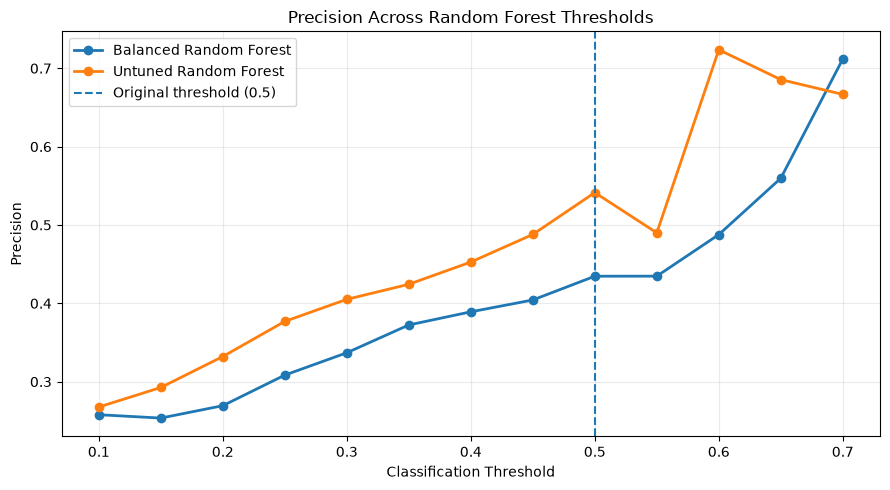

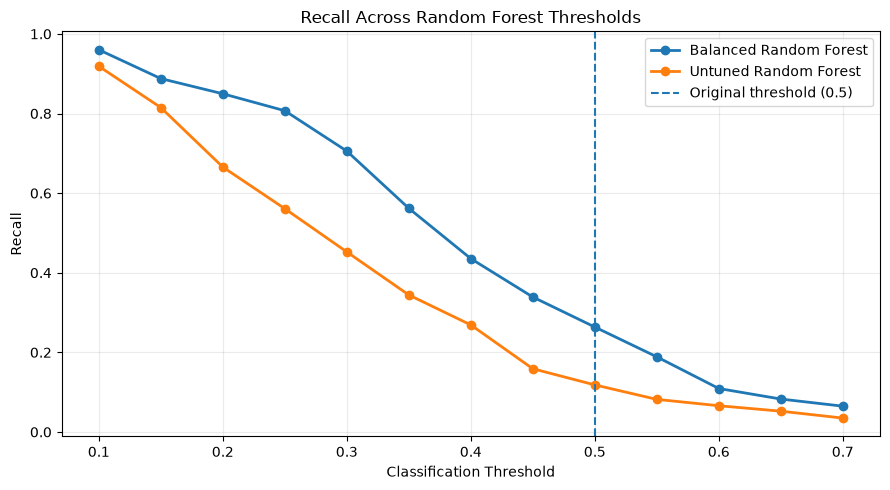

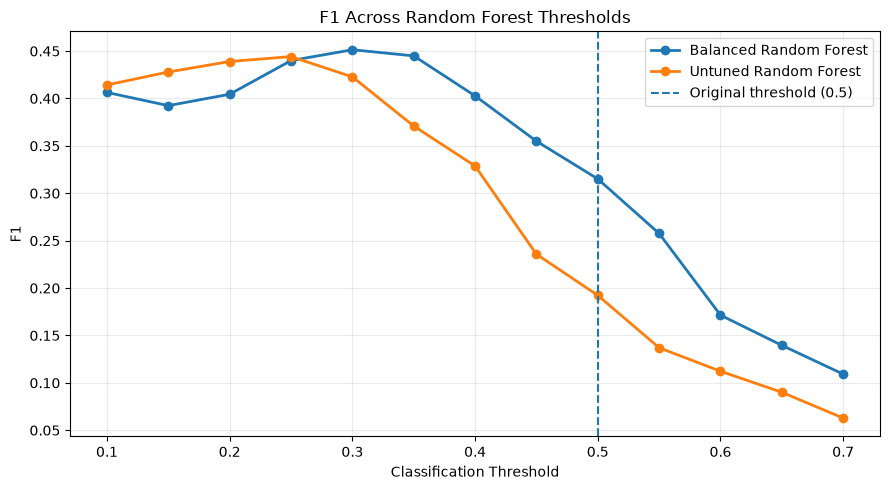

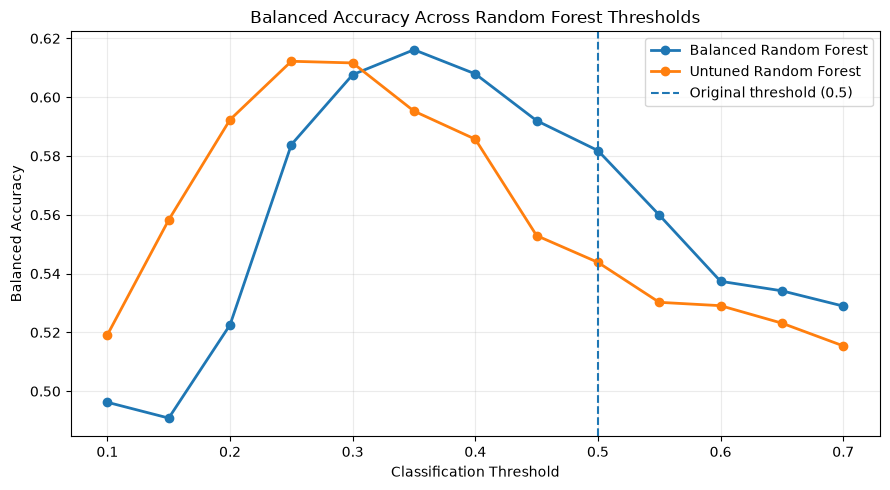

In [164]:
# Plot the main threshold-dependent metrics separately.
threshold_metrics = [
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "mean_balanced_accuracy",
]


for metric in threshold_metrics:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    # Plot one line for each Random Forest specification.
    for model_name in (
        rf_threshold_summary[
            "model"
        ].unique()
    ):

        plot_data = (
            rf_threshold_summary[
                rf_threshold_summary[
                    "model"
                ].eq(model_name)
            ]
            .sort_values(
                "threshold"
            )
        )

        ax.plot(
            plot_data[
                "threshold"
            ],
            plot_data[
                metric
            ],
            marker="o",
            linewidth=2,
            label=model_name,
        )


    # Mark the original classification threshold.
    ax.axvline(
        x=0.5,
        linestyle="--",
        linewidth=1.5,
        label="Original threshold (0.5)",
    )


    ax.set_xlabel(
        "Classification Threshold"
    )

    ax.set_ylabel(
        metric.replace(
            "mean_",
            "",
        )
        .replace(
            "_",
            " ",
        )
        .title()
    )

    ax.set_title(
        (
            f"{metric.replace('mean_', '').replace('_', ' ').title()} "
            "Across Random Forest Thresholds"
        )
    )

    ax.legend()

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

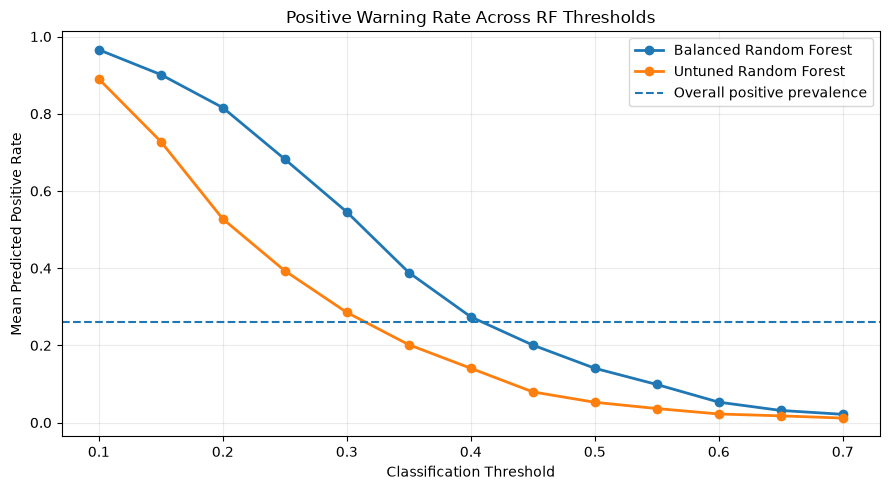

In [165]:
# Calculate prevalence only from observations used in OOF validation.
oof_positive_rate = (
    rf_oof_predictions[
        target_col
    ].mean()
)


# Compare how frequently each threshold issues positive warnings.
fig, ax = plt.subplots(
    figsize=(9, 5)
)


for model_name in (
    rf_threshold_summary[
        "model"
    ].unique()
):

    plot_data = (
        rf_threshold_summary[
            rf_threshold_summary[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "threshold"
        )
    )

    ax.plot(
        plot_data[
            "threshold"
        ],
        plot_data[
            "mean_predicted_positive_rate"
        ],
        marker="o",
        linewidth=2,
        label=model_name,
    )


# Add the approximate observed positive prevalence.
ax.axhline(
    y=oof_positive_rate,
    linestyle="--",
    linewidth=1.5,
    label="Overall positive prevalence",
)


ax.set_xlabel(
    "Classification Threshold"
)

ax.set_ylabel(
    "Mean Predicted Positive Rate"
)

ax.set_title(
    "Positive Warning Rate Across RF Thresholds"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

So 0.30 is clearly the high-sensitivity operating point. It catches about 71% of actual future bottom-quartile cases and has the highest F1, while also showing relatively low fold-to-fold variability. Its downside is substantial: it flags about 54.6% of observations, which is more than twice the actual positive prevalence. For an early-warning system that strongly prioritises avoiding missed cases, this may be defensible, but it produces many false alarms.

The 0.35 threshold is arguably the stronger primary operating point. It achieves the highest mean balanced accuracy (0.616), retains recall of 0.562, improves precision to 0.372, and reduces the warning rate sharply from 54.6% to 38.9%. Importantly, its F1 (0.445) is only about 0.006 below the maximum at threshold 0.30. In other words, moving from 0.30 → 0.35 sacrifices roughly 14 percentage points of recall, but removes about 16 percentage points of warnings while barely changing F1.

Thresholds 0.50–0.70 confirm why extending the grid was worthwhile, but they are not appropriate for the main early-warning specification.

In [166]:
# Define the three RF model-threshold combinations to compare.
rf_operating_points = {
    "Balanced RF @ 0.30": {
        "oof": rf_balanced_oof_predictions,
        "threshold": 0.30,
    },

    "Balanced RF @ 0.35": {
        "oof": rf_balanced_oof_predictions,
        "threshold": 0.35,
    },
}

In [167]:
# Calculate performance separately for each operating point and fold.
rf_selected_fold_results = []

for model_name, config in (
    rf_operating_points.items()
):

    oof_data = config["oof"]
    threshold = config["threshold"]

    for fold_number, fold_data in (
        oof_data.groupby("fold")
    ):

        y_true = fold_data[
            target_col
        ]

        y_probability = fold_data[
            "predicted_probability"
        ]

        y_prediction = (
            y_probability
            >= threshold
        ).astype(int)

        rf_selected_fold_results.append(
            {
                "model":
                    model_name,

                "fold":
                    fold_number,

                "threshold":
                    threshold,

                "rows":
                    len(fold_data),

                "actual_positive_rate":
                    y_true.mean(),

                "predicted_positive_rate":
                    y_prediction.mean(),

                "accuracy":
                    accuracy_score(
                        y_true,
                        y_prediction,
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_true,
                        y_prediction,
                    ),

                "precision":
                    precision_score(
                        y_true,
                        y_prediction,
                        zero_division=0,
                    ),

                "recall":
                    recall_score(
                        y_true,
                        y_prediction,
                        zero_division=0,
                    ),

                "f1":
                    f1_score(
                        y_true,
                        y_prediction,
                        zero_division=0,
                    ),

                "roc_auc":
                    roc_auc_score(
                        y_true,
                        y_probability,
                    ),

                "average_precision":
                    average_precision_score(
                        y_true,
                        y_probability,
                    ),

                "brier_score":
                    brier_score_loss(
                        y_true,
                        y_probability,
                    ),
            }
        )


# Convert the fold results into a dataframe.
rf_selected_fold_results = (
    pd.DataFrame(
        rf_selected_fold_results
    )
    .sort_values(
        [
            "fold",
            "model",
        ]
    )
    .reset_index(
        drop=True
    )
)

rf_selected_fold_results

,model,fold,threshold,rows,actual_positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,Balanced RF @ 0.30,1,0.30,1259,0.249404,0.347101,0.600477,0.531844,0.283753,0.394904,0.330226,0.521491,0.388901,0.195568
1,Balanced RF @ 0.35,1,0.35,1259,0.249404,0.272438,0.670373,0.575215,0.352770,0.385350,0.368341,0.521491,0.388901,0.195568
2,Balanced RF @ 0.30,2,0.30,1387,0.268205,0.609229,0.526316,0.598019,0.331361,0.752688,0.460148,0.600641,0.333185,0.204054
3,Balanced RF @ 0.35,2,0.35,1387,0.268205,0.418169,0.577505,0.550401,0.315517,0.491935,0.384454,0.600641,0.333185,0.204054
4,Balanced RF @ 0.30,3,0.30,1254,0.270335,0.721691,0.443381,0.557300,0.301657,0.805310,0.438907,0.568559,0.288307,0.215585
5,Balanced RF @ 0.35,3,0.35,1254,0.270335,0.441786,0.576555,0.563137,0.326715,0.533923,0.405375,0.568559,0.288307,0.215585
6,Balanced RF @ 0.30,4,0.30,1320,0.250000,0.504545,0.680303,0.743434,0.430931,0.869697,0.576305,0.837573,0.685032,0.143242
7,Balanced RF @ 0.35,4,0.35,1320,0.250000,0.422727,0.745455,0.775758,0.494624,0.836364,0.621622,0.837573,0.685032,0.143242


In [168]:
# Summarise average performance and variability across folds.
rf_selected_fold_summary = (
    rf_selected_fold_results
    .groupby(
        "model"
    )
    .agg(
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        std_balanced_accuracy=(
            "balanced_accuracy",
            "std",
        ),
        min_balanced_accuracy=(
            "balanced_accuracy",
            "min",
        ),

        mean_precision=(
            "precision",
            "mean",
        ),

        mean_recall=(
            "recall",
            "mean",
        ),
        std_recall=(
            "recall",
            "std",
        ),
        min_recall=(
            "recall",
            "min",
        ),

        mean_f1=(
            "f1",
            "mean",
        ),
        std_f1=(
            "f1",
            "std",
        ),
        min_f1=(
            "f1",
            "min",
        ),

        mean_predicted_positive_rate=(
            "predicted_positive_rate",
            "mean",
        ),
    )
    .reset_index()
)

rf_selected_fold_summary

,model,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,mean_precision,mean_recall,std_recall,min_recall,mean_f1,std_f1,min_f1,mean_predicted_positive_rate
0,Balanced RF @ 0.30,0.607649,0.094537,0.531844,0.336926,0.705650,0.212618,0.394904,0.451397,0.100858,0.330226,0.545641
1,Balanced RF @ 0.35,0.616128,0.106901,0.550401,0.372406,0.561893,0.193372,0.385350,0.444948,0.118754,0.368341,0.388780


So based on the fold summary alone:

Balanced RF @ 0.30
→ high-sensitivity option
→ mean recall = 0.706
→ mean F1 = 0.451
→ warning rate = 54.6%

Balanced RF @ 0.35
→ primary candidate
→ mean balanced accuracy = 0.616
→ precision = 0.372
→ mean F1 = 0.445
→ warning rate = 38.9%
→ stronger worst-fold F1 and balanced accuracy

In [189]:
from sklearn.metrics import confusion_matrix


# Store overall confusion-matrix results for each operating point.
rf_confusion_results = []


for model_name, config in rf_operating_points.items():

    oof_data = config["oof"]
    threshold = config["threshold"]

    y_true = oof_data[
        target_col
    ]

    y_probability = oof_data[
        "predicted_probability"
    ]

    y_prediction = (
        y_probability
        >= threshold
    ).astype(int)


    # Extract TN, FP, FN, and TP.
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_prediction,
        labels=[0, 1],
    ).ravel()


    total_rows = len(
        y_true
    )

    actual_positives = (
        tp + fn
    )

    predicted_positives = (
        tp + fp
    )


    rf_confusion_results.append(
        {
            "model":
                model_name,

            "threshold":
                threshold,

            "rows":
                total_rows,

            "true_positive":
                tp,

            "false_positive":
                fp,

            "false_negative":
                fn,

            "true_negative":
                tn,

            "actual_positive":
                actual_positives,

            "warnings":
                predicted_positives,

            "warning_rate":
                predicted_positives
                / total_rows,

            "precision":
                tp
                / predicted_positives
                if predicted_positives > 0
                else 0,

            "recall":
                tp
                / actual_positives
                if actual_positives > 0
                else 0,

            "false_warning_share":
                fp
                / predicted_positives
                if predicted_positives > 0
                else 0,

            "missed_positive_share":
                fn
                / actual_positives
                if actual_positives > 0
                else 0,
        }
    )


rf_confusion_results = (
    pd.DataFrame(
        rf_confusion_results
    )
)

rf_confusion_results

,model,threshold,rows,true_positive,false_positive,false_negative,true_negative,actual_positive,warnings,warning_rate,precision,recall,false_warning_share,missed_positive_share
0,Balanced RF @ 0.30,0.30,5220,964,1889,391,1976,1355,2853,0.546552,0.337890,0.711439,0.662110,0.288561
1,Balanced RF @ 0.35,0.35,5220,761,1274,594,2591,1355,2035,0.389847,0.373956,0.561624,0.626044,0.438376


So 0.35 does improve warning quality, but only moderately. It definitely does not mean that reducing the warning rate to 38.9% suddenly makes those warnings closely match the 26% true-positive population.

The more revealing comparison is what happens when we move from 0.30 → 0.35. The model removes 818 warnings.

For an early-warning system, there is a legitimate argument that false negatives are more costly than false positives: a false warning can trigger further investigation, whereas a missed positive means an emerging underperformer receives no warning at all.

Threshold 0.35 is the more selective operating point, while threshold 0.30 is the more sensitive early-warning operating point.

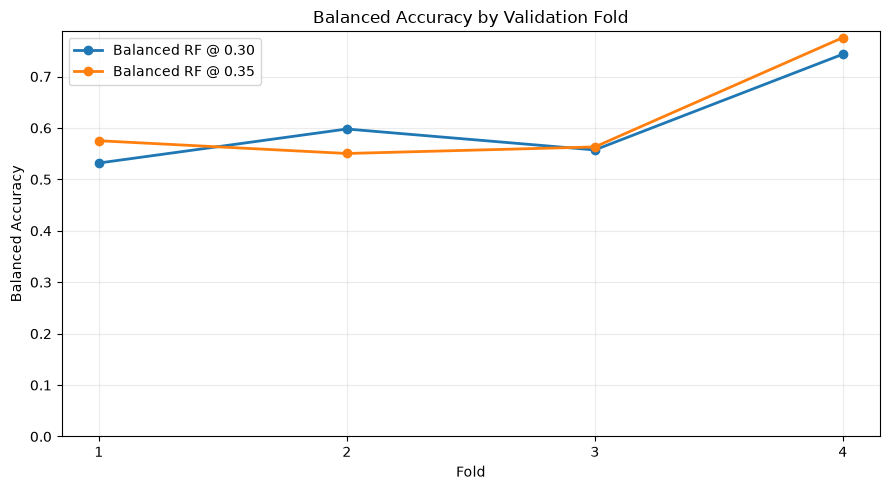

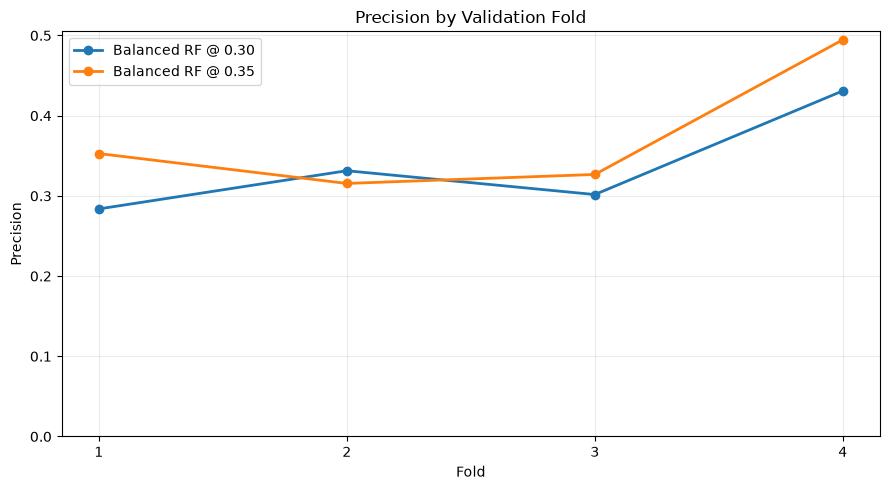

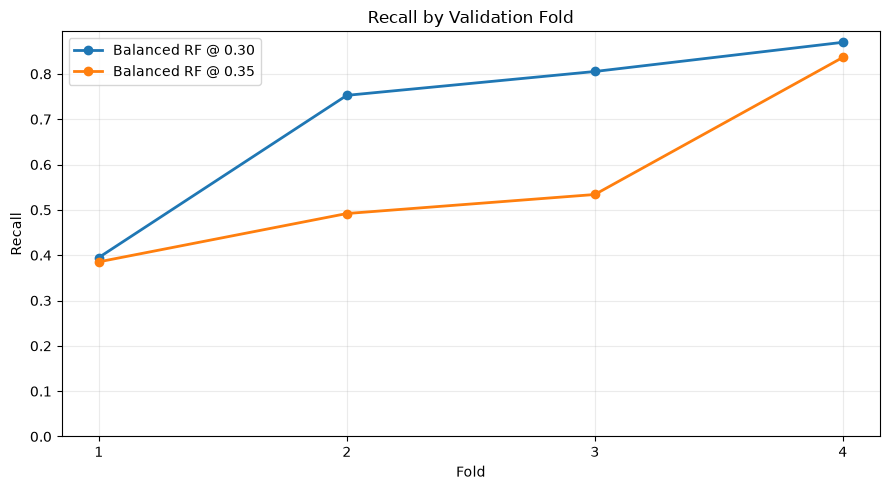

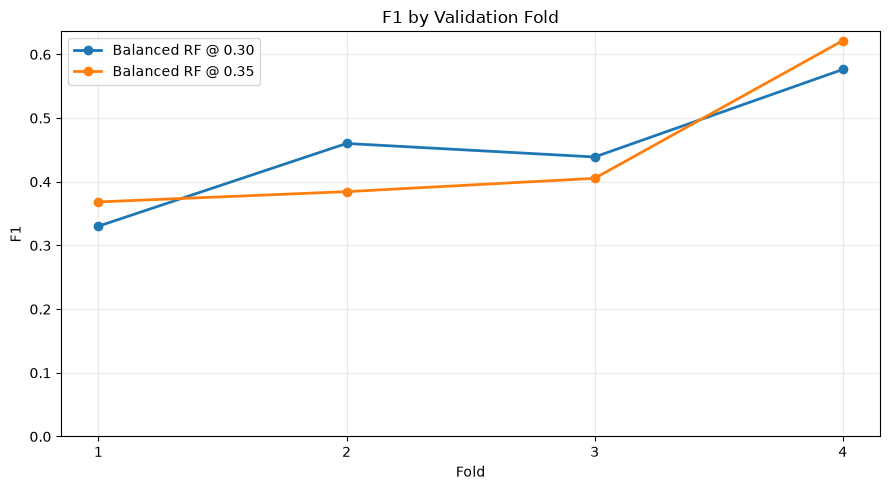

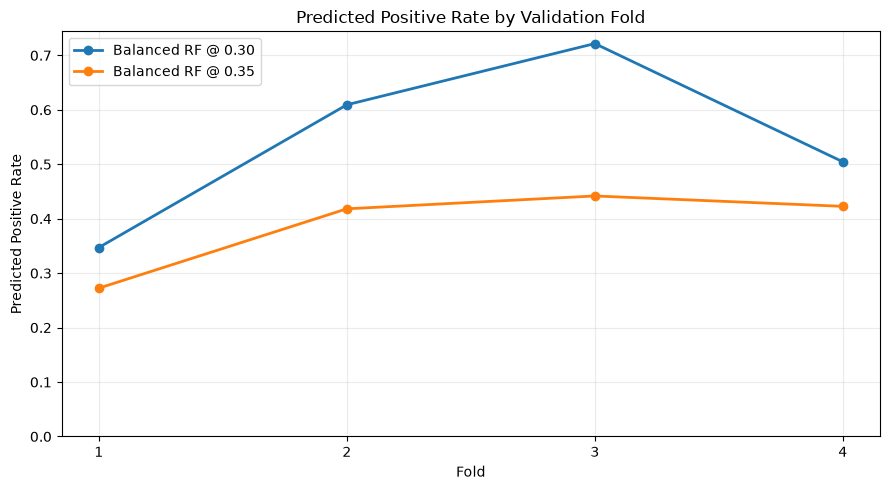

In [169]:
import matplotlib.pyplot as plt


# Plot the main threshold-dependent metrics across folds.
fold_plot_metrics = [
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "predicted_positive_rate",
]


for metric in fold_plot_metrics:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    for model_name in (
        rf_operating_points.keys()
    ):

        plot_data = (
            rf_selected_fold_results[
                rf_selected_fold_results[
                    "model"
                ].eq(model_name)
            ]
            .sort_values("fold")
        )

        ax.plot(
            plot_data["fold"],
            plot_data[metric],
            marker="o",
            linewidth=2,
            label=model_name,
        )

    ax.set_xlabel(
        "Fold"
    )

    ax.set_ylabel(
        metric.replace(
            "_",
            " ",
        ).title()
    )

    ax.set_title(
        (
            f"{metric.replace('_', ' ').title()} "
            "by Validation Fold"
        )
    )

    ax.set_xticks(
        [1, 2, 3, 4]
    )

    ax.set_ylim(
        bottom=0
    )

    ax.legend()

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

In [175]:
# Calculate performance separately for every validation quarter.
rf_selected_quarter_results = []

for model_name, config in (
    rf_operating_points.items()
):

    oof_data = config["oof"]
    threshold = config["threshold"]

    for (
        fold_number,
        quarter,
    ), quarter_data in (
        oof_data.groupby(
            [
                "fold",
                "period_end_date",
            ]
        )
    ):

        y_true = quarter_data[
            target_col
        ]

        y_probability = quarter_data[
            "predicted_probability"
        ]

        y_prediction = (
            y_probability
            >= threshold
        ).astype(int)

        rf_selected_quarter_results.append(
            {
                "model":
                    model_name,

                "fold":
                    fold_number,

                "period_end_date":
                    quarter,

                "threshold":
                    threshold,

                "rows":
                    len(quarter_data),

                "actual_positive_rate":
                    y_true.mean(),

                "predicted_positive_rate":
                    y_prediction.mean(),

                "accuracy":
                    accuracy_score(
                        y_true,
                        y_prediction,
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_true,
                        y_prediction,
                    ),

                "precision":
                    precision_score(
                        y_true,
                        y_prediction,
                        zero_division=0,
                    ),

                "recall":
                    recall_score(
                        y_true,
                        y_prediction,
                        zero_division=0,
                    ),

                "f1":
                    f1_score(
                        y_true,
                        y_prediction,
                        zero_division=0,
                    ),

                "roc_auc":
                    roc_auc_score(
                        y_true,
                        y_probability,
                    ),

                "average_precision":
                    average_precision_score(
                        y_true,
                        y_probability,
                    ),

                "brier_score":
                    brier_score_loss(
                        y_true,
                        y_probability,
                    ),
            }
        )


# Convert quarterly results into a chronological dataframe.
rf_selected_quarter_results = (
    pd.DataFrame(
        rf_selected_quarter_results
    )
    .sort_values(
        [
            "period_end_date",
            "model",
        ]
    )
    .reset_index(
        drop=True
    )
)

In [176]:
# Display the most relevant quarter-level operating metrics.
rf_selected_quarter_results[
    [
        "fold",
        "period_end_date",
        "model",
        "actual_positive_rate",
        "predicted_positive_rate",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier_score",
    ]
]

,fold,period_end_date,model,actual_positive_rate,predicted_positive_rate,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score
0,1,2019-06-30,Balanced RF @ 0.30,0.240132,0.371711,0.390619,0.132743,0.205479,0.161290,0.374251,0.229869,0.225317
1,1,2019-06-30,Balanced RF @ 0.35,0.240132,0.220395,0.481172,0.208955,0.191781,0.200000,0.374251,0.229869,0.225317
2,1,2019-09-30,Balanced RF @ 0.30,0.246711,0.319079,0.403261,0.134021,0.173333,0.151163,0.327977,0.194533,0.244179
3,1,2019-09-30,Balanced RF @ 0.35,0.246711,0.236842,0.448996,0.166667,0.160000,0.163265,0.327977,0.194533,0.244179
4,1,2019-12-31,Balanced RF @ 0.30,0.242623,0.190164,0.552884,0.344828,0.270270,0.303030,0.486486,0.370964,0.190441
5,1,2019-12-31,Balanced RF @ 0.35,0.242623,0.163934,0.561279,0.380000,0.256757,0.306452,0.486486,0.370964,0.190441
6,1,2020-03-31,Balanced RF @ 0.30,0.265896,0.488439,0.729973,0.449704,0.826087,0.582375,0.903971,0.864733,0.131241
7,1,2020-03-31,Balanced RF @ 0.35,0.265896,0.445087,0.759500,0.493506,0.826087,0.617886,0.903971,0.864733,0.131241
8,2,2020-06-30,Balanced RF @ 0.30,0.265896,0.881503,0.425240,0.232787,0.771739,0.357683,0.219189,0.183551,0.276352
9,2,2020-06-30,Balanced RF @ 0.35,0.265896,0.745665,0.362290,0.193798,0.543478,0.285714,0.219189,0.183551,0.276352


In [177]:
# Summarise mean, variability, and worst-quarter performance.
rf_selected_quarter_summary = (
    rf_selected_quarter_results
    .groupby(
        "model"
    )
    .agg(
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        std_balanced_accuracy=(
            "balanced_accuracy",
            "std",
        ),
        min_balanced_accuracy=(
            "balanced_accuracy",
            "min",
        ),

        mean_precision=(
            "precision",
            "mean",
        ),

        mean_recall=(
            "recall",
            "mean",
        ),
        std_recall=(
            "recall",
            "std",
        ),
        min_recall=(
            "recall",
            "min",
        ),

        mean_f1=(
            "f1",
            "mean",
        ),
        std_f1=(
            "f1",
            "std",
        ),
        min_f1=(
            "f1",
            "min",
        ),

        mean_predicted_positive_rate=(
            "predicted_positive_rate",
            "mean",
        ),
    )
    .reset_index()
)

rf_selected_quarter_summary

,model,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,mean_precision,mean_recall,std_recall,min_recall,mean_f1,std_f1,min_f1,mean_predicted_positive_rate
0,Balanced RF @ 0.30,0.606688,0.134101,0.390619,0.344479,0.699720,0.260403,0.173333,0.450379,0.151251,0.151163,0.541721
1,Balanced RF @ 0.35,0.617397,0.141242,0.362290,0.384145,0.560657,0.257258,0.160000,0.441158,0.169109,0.163265,0.385552


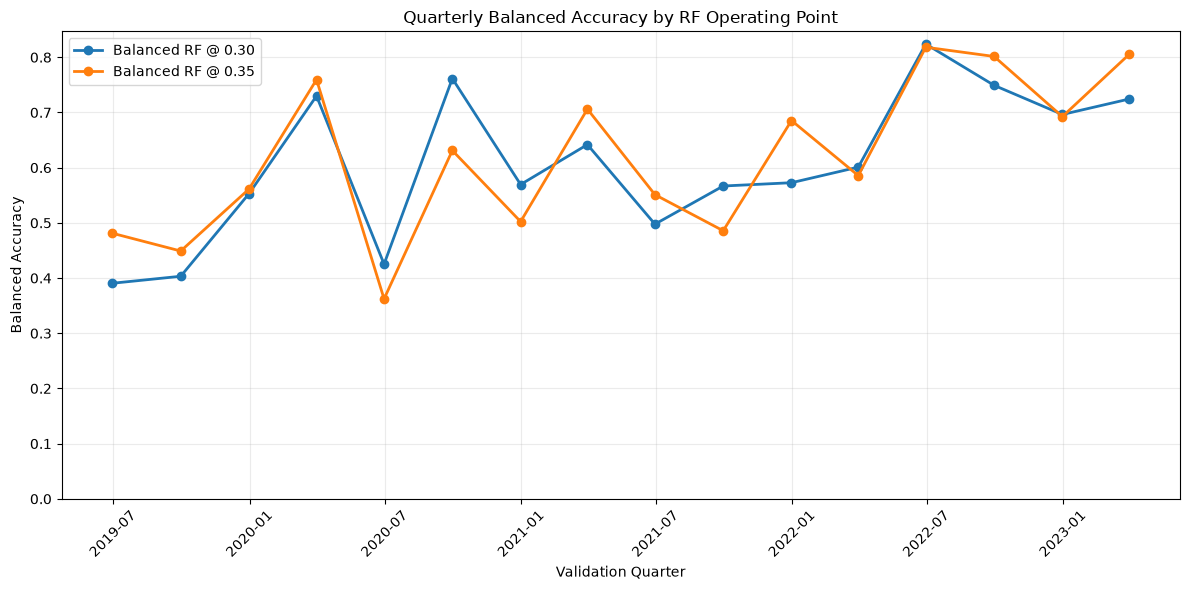

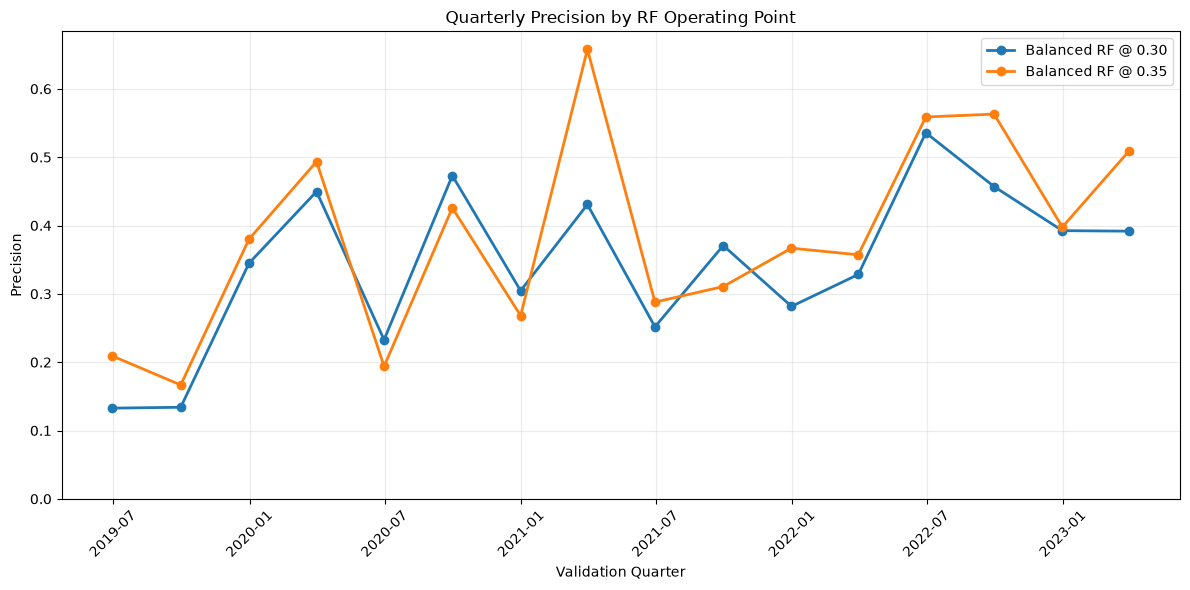

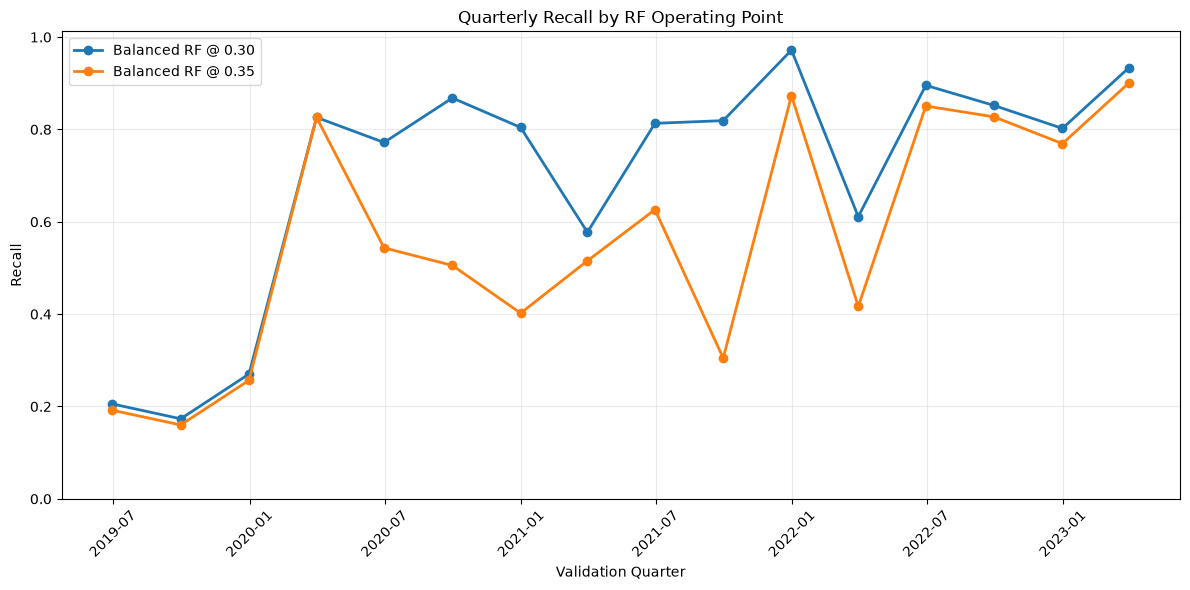

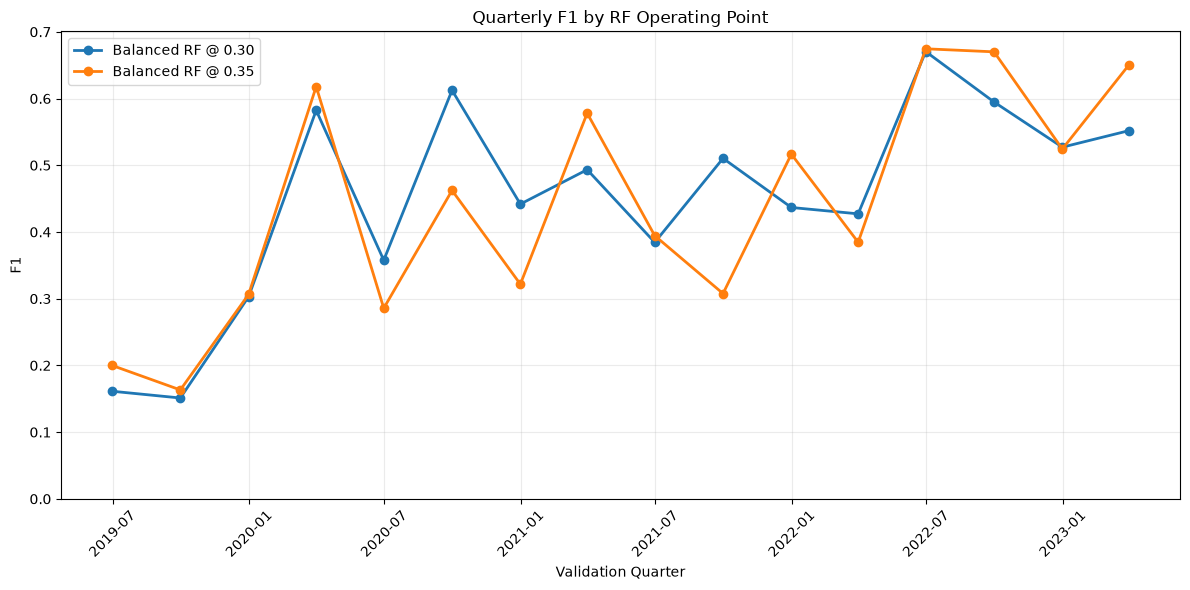

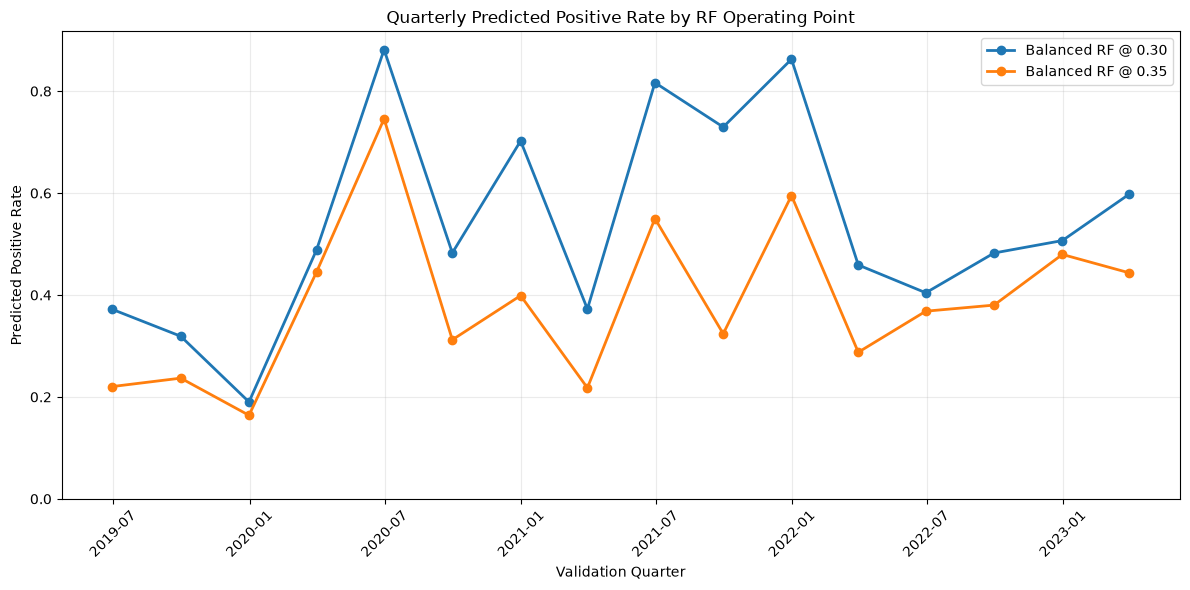

In [173]:
# Plot quarterly threshold-dependent performance over time.
quarter_plot_metrics = [
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "predicted_positive_rate",
]


for metric in quarter_plot_metrics:

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    for model_name in (
        rf_operating_points.keys()
    ):

        plot_data = (
            rf_selected_quarter_results[
                rf_selected_quarter_results[
                    "model"
                ].eq(model_name)
            ]
            .sort_values(
                "period_end_date"
            )
        )

        ax.plot(
            plot_data[
                "period_end_date"
            ],
            plot_data[
                metric
            ],
            marker="o",
            linewidth=2,
            label=model_name,
        )

    ax.set_xlabel(
        "Validation Quarter"
    )

    ax.set_ylabel(
        metric.replace(
            "_",
            " ",
        ).title()
    )

    ax.set_title(
        (
            f"Quarterly "
            f"{metric.replace('_', ' ').title()} "
            "by RF Operating Point"
        )
    )

    ax.set_ylim(
        bottom=0
    )

    ax.legend()

    ax.grid(
        alpha=0.25
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()
    plt.show()

In [174]:
# Show the weakest quarters according to F1.
rf_selected_quarter_results[
    [
        "period_end_date",
        "model",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
        "predicted_positive_rate",
    ]
].sort_values(
    [
        "model",
        "f1",
    ]
).groupby(
    "model"
).head(
    5
)

,period_end_date,model,precision,recall,f1,balanced_accuracy,predicted_positive_rate
2,2019-09-30,Balanced RF @ 0.30,0.134021,0.173333,0.151163,0.403261,0.319079
0,2019-06-30,Balanced RF @ 0.30,0.132743,0.205479,0.161290,0.390619,0.371711
4,2019-12-31,Balanced RF @ 0.30,0.344828,0.270270,0.303030,0.552884,0.190164
8,2020-06-30,Balanced RF @ 0.30,0.232787,0.771739,0.357683,0.425240,0.881503
16,2021-06-30,Balanced RF @ 0.30,0.251701,0.813187,0.384416,0.497671,0.816667
3,2019-09-30,Balanced RF @ 0.35,0.166667,0.160000,0.163265,0.448996,0.236842
1,2019-06-30,Balanced RF @ 0.35,0.208955,0.191781,0.200000,0.481172,0.220395
9,2020-06-30,Balanced RF @ 0.35,0.193798,0.543478,0.285714,0.362290,0.745665
5,2019-12-31,Balanced RF @ 0.35,0.380000,0.256757,0.306452,0.561279,0.163934
19,2021-09-30,Balanced RF @ 0.35,0.310680,0.304762,0.307692,0.485714,0.323899


The fold-level results show that Balanced RF @ 0.35 should be the primary operating specification, with 0.30 retained as a high-sensitivity alternative.

At the quarterly level, 0.35 improves the mean balanced accuracy from 0.607 to 0.617 and precision from 0.344 to 0.384, while reducing the positive-warning rate substantially from 54.2% to 38.6%. The cost is recall: it falls from 0.700 at threshold 0.30 to 0.561 at 0.35. Interestingly, F1 changes only moderately, from 0.450 to 0.441. This means that the considerable reduction in warning volume is achieved without a similarly large deterioration in the overall precision-recall balance.

Temporal robustness is more nuanced. Threshold 0.30 has slightly lower quarterly variability in balanced accuracy (0.134 vs 0.141) and F1 (0.151 vs 0.169), and its worst-quarter balanced accuracy is better (0.391 vs 0.362). Conversely, 0.35 has a slightly higher worst-quarter F1 (0.163 vs 0.151) and slightly lower recall variability (0.257 vs 0.260). Therefore, neither threshold universally dominates in temporal stability. This is consistent with the fold results, where 0.35 produced a higher mean and minimum balanced accuracy and a higher minimum F1, while 0.30 retained substantially greater recall.

The reason is not that 0.35 has the highest value on every metric. It does not. Rather, moving from 0.30 to 0.35 reduces alerts by roughly 15–16 percentage points, improves precision and balanced accuracy, and sacrifices only about 0.006–0.009 F1. That is a substantial operational efficiency gain. Threshold 0.30 should still be documented as the high-sensitivity scenario if the cost of missing future underperformers is considered more important than false warnings.

### Boruta Feature Selection -- Random Forest Model

In [116]:
# Install BorutaPy if it is not already installed.
# %pip install Boruta

   ---------------------------------------- 0.0/57.9 kB ? eta -:--:--
   ----------------------------------- ---- 51.2/57.9 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 57.9/57.9 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
from boruta import BorutaPy

In [178]:
# Keep the previously selected Random Forest configuration fixed.
boruta_rf_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "min_samples_leaf": 20,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

BORUTA_RF_THRESHOLD = 0.35

# Store feature-selection, fold-performance, and OOF outputs.
boruta_feature_results = []
boruta_rf_fold_results = []
boruta_rf_oof_predictions = []


for fold_info in rf_fold_windows:

    fold_number = fold_info["fold"]
    validation_start = fold_info["validation_start"]
    validation_end = fold_info["validation_end"]


    # Build the same purged temporal training population.
    train_mask = (
        model_data["period_end_date"].lt(validation_start)
        &
        model_data["target_end_date"].lt(validation_start)
    )


    # Select the current validation block.
    validation_mask = (
        model_data["period_end_date"]
        .between(
            validation_start,
            validation_end,
        )
    )


    train_data = (model_data[train_mask].copy())
    validation_data = (model_data[validation_mask].copy())

    X_train = train_data[baseline_features].copy()
    y_train = train_data[target_col].copy()

    X_validation = validation_data[baseline_features].copy()
    y_validation = validation_data[target_col].copy()

    # BorutaPy itself does not accept NaNs.
    # Impute using training-fold medians only for feature selection.
    train_medians = (X_train.median())

    X_train_boruta = (
        X_train
        .fillna(train_medians)
        .fillna(0.0)
    )


    # Use the selected RF structure inside Boruta.
    boruta_estimator = (RandomForestClassifier(**boruta_rf_params))

    # Run Boruta on training data only.
    boruta_selector = BorutaPy(
        estimator=boruta_estimator,
        n_estimators=1000,
        perc=100,
        alpha=0.05,
        two_step=True,
        max_iter=100,
        random_state=42,
        verbose=2,
    )

    boruta_selector.fit(
        X_train_boruta.to_numpy(),
        y_train.to_numpy(),
    )


    # Extract confirmed and tentative features.
    confirmed_features = (
        np.array(baseline_features)[boruta_selector.support_].tolist()
    )

    tentative_features = (
        np.array(baseline_features)[boruta_selector.support_weak_].tolist()
    )

    # Record Boruta's decision for every feature.
    for (
        feature,
        confirmed,
        tentative,
        ranking,
    ) in zip(
        baseline_features,
        boruta_selector.support_,
        boruta_selector.support_weak_,
        boruta_selector.ranking_,
    ):

        if confirmed:
            status = "confirmed"

        elif tentative:
            status = "tentative"

        else:
            status = "rejected"

        boruta_feature_results.append(
            {
                "fold":
                    fold_number,

                "feature":
                    feature,

                "status":
                    status,

                "ranking":
                    ranking,
            }
        )


    print(
        f"Fold {fold_number}: "
        f"{len(confirmed_features)} confirmed, "
        f"{len(tentative_features)} tentative"
    )


    # Require at least one confirmed feature.
    if len(confirmed_features) == 0:
        raise ValueError(
            f"Boruta selected no confirmed "
            f"features in Fold {fold_number}."
        )


    # Train the selected RF on the ORIGINAL data.
    # This preserves the RF's native NaN handling.
    boruta_rf_model = (RandomForestClassifier(**boruta_rf_params))

    boruta_rf_model.fit(
        X_train[confirmed_features],
        y_train,
    )

    validation_probability = (
        boruta_rf_model
        .predict_proba(X_validation[confirmed_features])[:, 1]
    )

    validation_prediction = (validation_probability >= BORUTA_RF_THRESHOLD).astype(int)

    # Store fold-level performance.
    boruta_rf_fold_results.append(
        {
            "fold": fold_number,
            "validation_start": validation_start,
            "validation_end": validation_end,

            "selected_feature_count":
                len(confirmed_features),

            "accuracy":
                accuracy_score(
                    y_validation,
                    validation_prediction,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_validation,
                    validation_prediction,
                ),

            "precision":
                precision_score(
                    y_validation,
                    validation_prediction,
                    zero_division=0,
                ),

            "recall":
                recall_score(
                    y_validation,
                    validation_prediction,
                    zero_division=0,
                ),

            "f1":
                f1_score(
                    y_validation,
                    validation_prediction,
                    zero_division=0,
                ),

            "roc_auc":
                roc_auc_score(
                    y_validation,
                    validation_probability,
                ),

            "average_precision":
                average_precision_score(
                    y_validation,
                    validation_probability,
                ),

            "brier_score":
                brier_score_loss(
                    y_validation,
                    validation_probability,
                ),

            "predicted_positive_rate":
                validation_prediction.mean(),
        }
    )


    # Preserve observations for quarterly analysis.
    fold_oof = validation_data[
        [
            "period_end_date",
            target_col,
        ]
    ].copy()

    fold_oof["fold"] = (
        fold_number
    )

    fold_oof["predicted_probability"] = validation_probability

    fold_oof["prediction"] = validation_prediction

    boruta_rf_oof_predictions.append(fold_oof)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	33
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	9 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	10 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	11 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	12 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	13 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	14 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	15 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
Iteration: 	16 / 100
Confirmed: 	29
Tentative: 	1
Rejected: 	3
I

In [179]:
# Convert Boruta feature decisions into a dataframe.
boruta_feature_results = (pd.DataFrame(boruta_feature_results))

# Convert fold performance into a dataframe.
boruta_rf_fold_results = (pd.DataFrame(boruta_rf_fold_results))


# Combine all OOF predictions.
boruta_rf_oof_predictions = (
    pd.concat(
        boruta_rf_oof_predictions,
        ignore_index=True,
    )
)

boruta_rf_fold_results

,fold,validation_start,validation_end,selected_feature_count,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,predicted_positive_rate
0,1,2019-06-30,2020-03-31,29,0.676728,0.579448,0.361194,0.385350,0.372881,0.510420,0.379160,0.198463,0.266084
1,2,2020-06-30,2021-03-31,31,0.565970,0.524638,0.292419,0.435484,0.349892,0.554192,0.301989,0.209222,0.399423
2,3,2021-06-30,2022-03-31,33,0.576555,0.563137,0.326715,0.533923,0.405375,0.568559,0.288307,0.215585,0.441786
3,4,2022-06-30,2023-03-31,33,0.745455,0.775758,0.494624,0.836364,0.621622,0.837573,0.685032,0.143242,0.422727


In [180]:
# Create selection indicators for each feature and fold.
boruta_feature_stability = (
    boruta_feature_results
    .assign(
        confirmed=lambda x:
            x["status"].eq(
                "confirmed"
            ).astype(int),

        tentative=lambda x:
            x["status"].eq(
                "tentative"
            ).astype(int),

        rejected=lambda x:
            x["status"].eq(
                "rejected"
            ).astype(int),
    )
    .groupby(
        "feature"
    )
    .agg(
        confirmed_folds=(
            "confirmed",
            "sum",
        ),

        tentative_folds=(
            "tentative",
            "sum",
        ),

        rejected_folds=(
            "rejected",
            "sum",
        ),

        mean_rank=(
            "ranking",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "confirmed_folds",
            "tentative_folds",
            "mean_rank",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
)

boruta_feature_stability

,feature,confirmed_folds,tentative_folds,rejected_folds,mean_rank
0,allocation_alternatives,4,0,0,1.00
1,allocation_cash,4,0,0,1.00
2,allocation_credit,4,0,0,1.00
3,allocation_equity,4,0,0,1.00
4,allocation_fixed_income_excluding_credit,4,0,0,1.00
5,allocation_infrastructure,4,0,0,1.00
6,allocation_property,4,0,0,1.00
8,currency_hedging_applicable_allocation,4,0,0,1.00
9,currency_hedging_distinct_ratios,4,0,0,1.00
10,current_return_minus_peer_median,4,0,0,1.00


In [181]:
# Show each feature's Boruta status across folds.
boruta_selection_matrix = (
    boruta_feature_results
    .pivot(
        index="feature",
        columns="fold",
        values="status",
    )
)

boruta_selection_matrix

fold,1,2,3,4
feature,,,,
allocation_alternatives,confirmed,confirmed,confirmed,confirmed
allocation_cash,confirmed,confirmed,confirmed,confirmed
allocation_credit,confirmed,confirmed,confirmed,confirmed
allocation_equity,confirmed,confirmed,confirmed,confirmed
allocation_fixed_income_excluding_credit,confirmed,confirmed,confirmed,confirmed
allocation_infrastructure,confirmed,confirmed,confirmed,confirmed
allocation_property,confirmed,confirmed,confirmed,confirmed
cash_allocation_change_1q,rejected,rejected,confirmed,confirmed
currency_hedging_applicable_allocation,confirmed,confirmed,confirmed,confirmed


In [182]:
# Summarise Boruta-selected RF performance across the four folds.
boruta_rf_summary = pd.Series(
    {
        "mean_selected_features":
            boruta_rf_fold_results[
                "selected_feature_count"
            ].mean(),

        "mean_roc_auc":
            boruta_rf_fold_results[
                "roc_auc"
            ].mean(),

        "std_roc_auc":
            boruta_rf_fold_results[
                "roc_auc"
            ].std(),

        "mean_average_precision":
            boruta_rf_fold_results[
                "average_precision"
            ].mean(),

        "mean_accuracy":
            boruta_rf_fold_results[
                "accuracy"
            ].mean(),

        "mean_balanced_accuracy":
            boruta_rf_fold_results[
                "balanced_accuracy"
            ].mean(),

        "mean_precision":
            boruta_rf_fold_results[
                "precision"
            ].mean(),

        "mean_recall":
            boruta_rf_fold_results[
                "recall"
            ].mean(),

        "mean_f1":
            boruta_rf_fold_results[
                "f1"
            ].mean(),

        "mean_brier_score":
            boruta_rf_fold_results[
                "brier_score"
            ].mean(),

        "mean_predicted_positive_rate":
            boruta_rf_fold_results[
                "predicted_positive_rate"
            ].mean(),
    }
)

boruta_rf_summary

mean_selected_features          31.500000
mean_roc_auc                     0.617686
std_roc_auc                      0.148662
mean_average_precision           0.413622
mean_accuracy                    0.641177
mean_balanced_accuracy           0.610745
mean_precision                   0.368738
mean_recall                      0.547780
mean_f1                          0.437443
mean_brier_score                 0.191628
mean_predicted_positive_rate     0.382505
dtype: float64

In [186]:
# Extract the existing full-feature Balanced RF @ 0.30 results.
full_rf_035 = (
    rf_selected_fold_results[
        rf_selected_fold_results[
            "model"
        ].eq(
            "Balanced RF @ 0.35"
        )
    ]
    .copy()
)

In [187]:
# Compare full-feature and Boruta-selected RF performance by fold.
boruta_vs_full_fold = (
    full_rf_035[
        [
            "fold",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision",
            "brier_score",
            "predicted_positive_rate",
        ]
    ]
    .merge(
        boruta_rf_fold_results[
            [
                "fold",
                "selected_feature_count",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "average_precision",
                "brier_score",
                "predicted_positive_rate",
            ]
        ],

        on="fold",

        suffixes=(
            "_full",
            "_boruta",
        ),
    )
)

boruta_vs_full_fold

,fold,balanced_accuracy_full,precision_full,recall_full,f1_full,roc_auc_full,average_precision_full,brier_score_full,predicted_positive_rate_full,selected_feature_count,balanced_accuracy_boruta,precision_boruta,recall_boruta,f1_boruta,roc_auc_boruta,average_precision_boruta,brier_score_boruta,predicted_positive_rate_boruta
0,1,0.575215,0.352770,0.385350,0.368341,0.521491,0.388901,0.195568,0.272438,29,0.579448,0.361194,0.385350,0.372881,0.510420,0.379160,0.198463,0.266084
1,2,0.550401,0.315517,0.491935,0.384454,0.600641,0.333185,0.204054,0.418169,31,0.524638,0.292419,0.435484,0.349892,0.554192,0.301989,0.209222,0.399423
2,3,0.563137,0.326715,0.533923,0.405375,0.568559,0.288307,0.215585,0.441786,33,0.563137,0.326715,0.533923,0.405375,0.568559,0.288307,0.215585,0.441786
3,4,0.775758,0.494624,0.836364,0.621622,0.837573,0.685032,0.143242,0.422727,33,0.775758,0.494624,0.836364,0.621622,0.837573,0.685032,0.143242,0.422727


In [188]:
# Evaluate the Boruta-selected RF separately for each validation quarter.
boruta_rf_quarter_results = []

for (
    fold_number,
    quarter,
), quarter_data in (
    boruta_rf_oof_predictions
    .groupby(
        [
            "fold",
            "period_end_date",
        ]
    )
):

    y_true = quarter_data[
        target_col
    ]

    y_probability = quarter_data[
        "predicted_probability"
    ]

    y_prediction = quarter_data[
        "prediction"
    ]


    boruta_rf_quarter_results.append(
        {
            "fold":
                fold_number,

            "period_end_date":
                quarter,

            "rows":
                len(
                    quarter_data
                ),

            "accuracy":
                accuracy_score(
                    y_true,
                    y_prediction,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_prediction,
                ),

            "precision":
                precision_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "recall":
                recall_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "f1":
                f1_score(
                    y_true,
                    y_prediction,
                    zero_division=0,
                ),

            "roc_auc":
                roc_auc_score(
                    y_true,
                    y_probability,
                ),

            "average_precision":
                average_precision_score(
                    y_true,
                    y_probability,
                ),

            "brier_score":
                brier_score_loss(
                    y_true,
                    y_probability,
                ),

            "predicted_positive_rate":
                y_prediction.mean(),
        }
    )


boruta_rf_quarter_results = (
    pd.DataFrame(
        boruta_rf_quarter_results
    )
    .sort_values(
        "period_end_date"
    )
    .reset_index(
        drop=True
    )
)

# Summarise temporal performance of the Boruta-selected RF.
boruta_rf_quarter_summary = (
    boruta_rf_quarter_results
    .agg(
        {
            "balanced_accuracy": [
                "mean",
                "std",
                "min",
            ],

            "precision": [
                "mean",
                "std",
                "min",
            ],

            "recall": [
                "mean",
                "std",
                "min",
            ],

            "f1": [
                "mean",
                "std",
                "min",
            ],

            "roc_auc": [
                "mean",
                "std",
                "min",
            ],

            "average_precision": [
                "mean",
                "std",
            ],

            "brier_score": [
                "mean",
                "std",
            ],

            "predicted_positive_rate": [
                "mean",
                "std",
            ],
        }
    )
)

boruta_rf_quarter_summary

,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,predicted_positive_rate
mean,0.612005,0.377505,0.546453,0.432668,0.626139,0.454504,0.191477,0.379208
std,0.146261,0.141022,0.263493,0.172272,0.224291,0.227490,0.044835,0.149317
min,0.314319,0.161826,0.160000,0.173913,0.179861,NaN,NaN,NaN


Boruta feature selection was evaluated within each purged temporal training fold using the final tuned Balanced Random Forest. The method retained an average of 31.5 of 33 baseline features and did not improve validation performance. The full-feature model achieved slightly higher ROC-AUC, Average Precision, balanced accuracy, precision, recall, and F1, together with a lower Brier score. Boruta produced minor improvements in Fold 1 but degraded performance in Fold 2, while Folds 3 and 4 were identical because all features were retained. Therefore, the full 33-feature Random Forest was retained for the final model.